# Clinical Trial Success Prediction for Pharmaceutical Decision Support

### A Healthcare / Pharmaceutical Analytics Machine Learning Project

---

| | |
|---|---|
| **Author** | Rajveer Singh |
| **Project Type** | End-to-End Machine Learning |
| **Domain** | Healthcare Analytics / Pharmaceutical Analytics |
| **Business Use Case** | Clinical Trial Risk Assessment |
| **Platform** | Google Colab |
| **Technologies** | Python, Pandas, NumPy, Scikit-learn, XGBoost, SHAP, Matplotlib, Seaborn |
| **Target Companies** | ConnectHEOR, EBM Healthcare, IQVIA, Parexel, ICON, Deloitte, EY, Accenture |

---


## Table of Contents

- [Business Context](#Business-Context)
- [Assumptions & Limitations](#Assumptions-&-Limitations-(Read-Before-Proceeding))
- [Phase 1 – Dataset Inspection](#Phase-1:-Dataset-Inspection)
- [Phase 2 – Data Cleaning & Target Engineering](#Phase-2:-Data-Cleaning-&-Target-Engineering)
- [Phase 3 – Feature Engineering](#Phase-3:-Feature-Engineering)
- [Phase 4 – Exploratory Data Analysis](#Phase-4:-Exploratory-Data-Analysis)
- [Phase 5 – Model Building](#Phase-5A:-Model-Preparation-&-Baseline-Models) (5A: Baselines, 5B: Tuning & Validation)
- [Phase 6 – Explainability (SHAP)](#Phase-6:-Model-Explainability-(SHAP))
- [Phase 7 – Business Insights & Recommendations](#Phase-7:-Business-Insights-&-Recommendations)
- [Phase 8 – Limitations, Future Improvements & GitHub README](#Phase-8:-Project-Packaging-&-Portfolio-Readiness)

---


## Business Context

Clinical trials are the single largest cost driver in pharmaceutical R&D. A Phase III
trial alone can cost tens to hundreds of millions of dollars, and industry-wide estimates
consistently show that a large share of registered trials terminate before completion —
due to funding withdrawal, recruitment shortfalls, poor study design, or strategic
portfolio decisions by the sponsor.

For pharmaceutical companies and Clinical Research Organizations (CROs), every trial
that terminates early after resources have already been committed represents:

- **Sunk capital** — site setup, staffing, and regulatory costs already spent
- **Opportunity cost** — capacity that could have gone to a higher-probability trial
- **Portfolio risk** — an unpredictable pipeline makes forecasting and investor
  communication harder
- **Delayed value delivery** — every failed trial delays getting effective treatments
  (or the capital to pursue better ones) to patients

This project builds a decision-support model that estimates a trial's likelihood of
reaching completion **using only information available at or near the planning stage**
— phase, sponsor type, planned enrollment, design complexity, geographic footprint, and
similar structural attributes. The intent is not to replace clinical judgment, but to
give portfolio and operations teams an early, data-driven risk signal that can inform:

- **Resource allocation** — prioritizing monitoring and support for higher-risk trials
- **Portfolio management** — balancing a trial portfolio's aggregate risk exposure
- **Go/no-go and design review** — flagging trials whose structural profile resembles
  historically high-failure-rate trials, prompting a second look before commitment
- **Cost forecasting** — informing more realistic completion-probability assumptions in
  budget and timeline planning

This mirrors the kind of trial-risk-scoring work done by pharmaceutical analytics and
CRO advisory teams (e.g., ConnectHEOR, IQVIA, Parexel, ICON) and by healthcare-focused
consulting practices (Deloitte, EY, Accenture) supporting pharma clients on R&D
portfolio strategy.


## Assumptions & Limitations (Read Before Proceeding)

**Target variable is an operational definition, not a clinical outcome measure.**

| Trial `status` | Treated as |
|---|---|
| `Completed` | **Success (1)** |
| `Terminated`, `Withdrawn`, `Suspended` | **Failure (0)** |
| `Recruiting`, `Active, not recruiting`, `Unknown status`, `Enrolling by invitation` | **Excluded** (outcome not yet resolved) |

This is a **business/operational definition of success**, not a claim about clinical
efficacy or safety. A trial can be `Terminated` for reasons entirely unrelated to
whether the drug works — funding withdrawal, sponsor strategy changes, slow enrollment,
or business decisions unrelated to trial science. Conversely, a `Completed` trial can
still fail to meet its primary endpoint (this dataset does not tell us endpoint results,
only whether the trial ran to completion).

**Why we proceed anyway:** operational completion vs. non-completion is itself a
meaningful and widely used business risk signal — it is a direct proxy for "was this
trial's investment protected," which is precisely the question portfolio and operations
teams need answered. We are explicit throughout this project that the model predicts
**operational completion risk**, not **clinical success**, and this distinction is
restated in the final business insights and README sections so it cannot be
misrepresented.

Additional limitations that will be revisited in Phase 9:
- Excluding unresolved trials reduces sample size and may introduce mild selection bias
  toward older, already-resolved trials.
- The dataset has no direct financial or endpoint-level data — cost and efficacy
  implications discussed later are illustrative business framing, not measured outcomes.
- Feature set is limited to metadata available in this registry export; it does not
  include protocol text, budget data, or CRO performance history that a real production
  model would likely incorporate.


## Phase 1: Dataset Inspection

**Goal:** Load the manually uploaded dataset and understand its structure, quality, and
target-variable feasibility *before* making any cleaning or modeling decisions. All
downstream choices in Phase 2 (cleaning) and Phase 3 (feature engineering) are grounded
in what we observe here, not in assumptions about the data.


### 1.1 Load the Dataset (Google Drive)

The dataset is stored in Google Drive. We mount Drive and load the CSV directly from
the project folder — no manual upload or Kaggle API needed.


In [51]:
# ============================================================
# PHASE 1.1 — Load the dataset from Google Drive
# ============================================================
from google.colab import drive
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Clinical_Trial_Success_Prediction/Data/clin_trials.csv"
df = pd.read_csv(file_path)

print(f"Loaded '{file_path}' successfully.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded '/content/drive/MyDrive/Clinical_Trial_Success_Prediction/Data/clin_trials.csv' successfully.


### 1.2 Structural Inspection

**We do not yet know the real column names in this export**, so nothing below
references a specific column. We inspect shape, the full column list, dtypes, and a row
preview first, and only build on names confirmed to actually exist. This avoids the
`KeyError` failure mode of coding against documentation instead of the actual file.


In [52]:
# ============================================================
# PHASE 1.2 — Structural inspection (no column-name assumptions)
# ============================================================
print("Shape (rows, columns):", df.shape)

print("\nComplete column list:")
for i, col in enumerate(df.columns):
    print(f"{i:2d}. {col}")

print("\nColumn names as a Python list (copy/paste-ready):")
print(list(df.columns))

print("\ndf.info():")
df.info()

print("\ndf.head():")
display(df.head())


Shape (rows, columns): (496615, 17)

Complete column list:
 0. Unnamed: 0
 1. Organization Full Name
 2. Organization Class
 3. Responsible Party
 4. Brief Title
 5. Full Title
 6. Overall Status
 7. Start Date
 8. Standard Age
 9. Conditions
10. Primary Purpose
11. Interventions
12. Intervention Description
13. Study Type
14. Phases
15. Outcome Measure
16. Medical Subject Headings

Column names as a Python list (copy/paste-ready):
['Unnamed: 0', 'Organization Full Name', 'Organization Class', 'Responsible Party', 'Brief Title', 'Full Title', 'Overall Status', 'Start Date', 'Standard Age', 'Conditions', 'Primary Purpose', 'Interventions', 'Intervention Description', 'Study Type', 'Phases', 'Outcome Measure', 'Medical Subject Headings']

df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496615 entries, 0 to 496614
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Unnamed: 0      

,Unnamed: 0,Organization Full Name,Organization Class,Responsible Party,Brief Title,Full Title,Overall Status,Start Date,Standard Age,Conditions,Primary Purpose,Interventions,Intervention Description,Study Type,Phases,Outcome Measure,Medical Subject Headings
0,0,Montefiore Medical Center,OTHER,SPONSOR,Kinesiotape for Edema After Bilateral Total Kn...,"Effect of Kinesiotaping on Edema Management, P...",COMPLETED,2021-10-18,ADULT OLDER_ADULT,"Arthroplasty Complications, Arthroplasty, Repl...",TREATMENT,Kinesio(R)Tape for edema control,"Kinesio(R)Tape is an elastic, cotton tape with...",INTERVENTIONAL,NaN,Change from baseline and during 1-2-day time i...,Edema
1,1,Seoul National University Hospital,OTHER,Unknown,An Open-labeled Trial of Ramipril in Patients ...,An Open-labeled Trial of Ramipril in Patients ...,COMPLETED,2004-10,ADULT OLDER_ADULT,Migraine With Hypertension,TREATMENT,Ramipril,ramipril 2.5mg twice a day,INTERVENTIONAL,PHASE2,headache frequency,Migraine Disorders Hypertension
2,2,Federico II University,OTHER,PRINCIPAL_INVESTIGATOR,OCTA in Epivascular Glia After Dex Implant,Evaluation of Changes in Epivascular Glia Befo...,COMPLETED,2021-01-01,ADULT OLDER_ADULT,Diabetic Retinopathy,Unknown,Dexamethasone intravitreal implant,Dexamethasone intravitreal implant,OBSERVATIONAL,Unknown,Changes in epivascular glia after Dexamethason...,Diabetic Retinopathy
3,3,Sidney Kimmel Comprehensive Cancer Center at J...,OTHER,SPONSOR,Preoperative Immune Checkpoint Inhibitor for P...,Preoperative Immune Checkpoint Inhibitor Thera...,COMPLETED,2019-07-08,ADULT OLDER_ADULT,"Head and Neck Squamous Cell Carcinoma, Head an...",TREATMENT,Nivolumab 480mg and surgical resection,One dose of Nivolumab 480mg given four weeks p...,INTERVENTIONAL,PHASE2,Safety as measured by number of participants w...,"Carcinoma Carcinoma, Squamous Cell Head and Ne..."
4,4,Northwestern University,OTHER,SPONSOR,Genistein in Treating Patients With Prostate C...,Phase 2 Trial of Genistein in Men With Circula...,TERMINATED,2011-02-03,ADULT OLDER_ADULT,"Adenocarcinoma of the Prostate, Recurrent Pros...",TREATMENT,"genistein, placebo, therapeutic conventional s...","Given orally, Given orally, Radical prostatect...",INTERVENTIONAL,PHASE2,Number of Circulating Prostate Cells (CPCs) in...,Prostatic Neoplasms


### 1.3 Missing Value Audit

**Why this matters (ML + business reasoning):** missingness drives two decisions in
Phase 2 — which columns are usable as features at all, and which imputation strategy is
defensible for the ones we keep. A column missing in >90% of rows is a drop candidate
(imputing it would mostly be fabricating data); a column missing in <5% of rows can
usually be safely imputed with minimal distortion. This check is column-name agnostic
and safe to run regardless of the actual schema.


In [53]:
# ============================================================
# PHASE 1.3 — Missing value audit
# ============================================================
missing_summary = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .sort_values("missing_pct", ascending=False)
)
display(missing_summary)


,missing_count,missing_pct
Phases,183844,37.02
Standard Age,885,0.18
Unnamed: 0,0,0.00
Responsible Party,0,0.00
Organization Full Name,0,0.00
Brief Title,0,0.00
Full Title,0,0.00
Overall Status,0,0.00
Organization Class,0,0.00
Start Date,0,0.00


### 1.4 Automatically Identify the Trial Status Column

We do not assume a column called `status` exists. Instead we score every column using
two independent signals and combine them:

- **Name signal:** does the column name contain a status-like keyword
  (`status`, `overall`, `study`, `outcome`, `recruitment`)?
- **Value signal:** do the column's actual values overlap with known trial-status
  labels (`Completed`, `Terminated`, `Withdrawn`, `Suspended`, `Recruiting`, etc.)?

The **value signal is the reliable one** — a column could be named almost anything
(`overall_status`, `Study Status`, `trial_status`, `current_status`) and still hold
status data, whereas a name match with no matching values is likely a false positive
(e.g., a `study_type` column contains "study" but not status labels). The column is
selected automatically based on this evidence, and the reasoning is printed so the
choice can be audited.


In [54]:
# ============================================================
# PHASE 1.4 — Automatically detect the trial-status column
# ============================================================
name_keywords = ["status", "overall", "study", "outcome", "recruitment"]
status_value_signals = {
    "completed", "terminated", "withdrawn", "suspended",
    "recruiting", "active, not recruiting", "unknown status",
    "enrolling by invitation"
}

name_candidates = [c for c in df.columns if any(k in c.lower() for k in name_keywords)]
print("Columns whose NAME contains a status-like keyword:", name_candidates)

# Value-based scoring: count how many known status labels appear in each object column
value_scores = {}
for col in df.columns:
    if df[col].dtype == object:
        sample_vals = set(df[col].dropna().astype(str).str.strip().str.lower().unique()[:100])
        overlap = sample_vals & status_value_signals
        if overlap:
            value_scores[col] = overlap

print("\nColumns whose VALUES overlap with known status labels:")
for col, overlap in value_scores.items():
    print(f"  - {col}: matched values = {overlap}")

if value_scores:
    # Prefer the column with the most matched status labels; break ties using the name signal
    STATUS_COL = max(
        value_scores,
        key=lambda c: (len(value_scores[c]), c in name_candidates)
    )
    print(f"\n✅ Auto-selected STATUS_COL = '{STATUS_COL}' "
          f"(matched {len(value_scores[STATUS_COL])} known status labels"
          f"{', and name matches a status keyword' if STATUS_COL in name_candidates else ''}).")

    if len(value_scores) > 1:
        other_candidates = [c for c in value_scores if c != STATUS_COL]
        print(f"\nOther candidates considered but not selected: {other_candidates}")
        print("These had fewer matching status labels and were treated as secondary candidates.")
elif name_candidates:
    # No value overlap anywhere — fall back to the strongest name match, but flag it clearly
    STATUS_COL = name_candidates[0]
    print(f"\n⚠️ No column's values matched known status labels. "
          f"Falling back to name match: '{STATUS_COL}'.")
    print("Inspect df.head() output above to manually verify this is correct before proceeding.")
else:
    STATUS_COL = None
    print("\n❌ No status-like column could be identified automatically.")
    print("Review the full column list and df.head() output above, then set STATUS_COL manually.")

assert STATUS_COL is not None, (
    "No status column could be auto-detected. "
    "Inspect df.columns and df.head() above and set STATUS_COL manually."
)

print(f"\nFinal STATUS_COL = '{STATUS_COL}'")
print("\nFull value counts:")
print(df[STATUS_COL].value_counts(dropna=False))


Columns whose NAME contains a status-like keyword: ['Overall Status', 'Study Type', 'Outcome Measure']

Columns whose VALUES overlap with known status labels:
  - Overall Status: matched values = {'terminated', 'recruiting', 'withdrawn', 'completed', 'suspended'}

✅ Auto-selected STATUS_COL = 'Overall Status' (matched 5 known status labels, and name matches a status keyword).

Final STATUS_COL = 'Overall Status'

Full value counts:
Overall Status
COMPLETED                    271022
RECRUITING                    67256
UNKNOWN                       67024
TERMINATED                    28878
NOT_YET_RECRUITING            20777
ACTIVE_NOT_RECRUITING         20070
WITHDRAWN                     14176
ENROLLING_BY_INVITATION        3946
SUSPENDED                      1641
WITHHELD                        885
NO_LONGER_AVAILABLE             452
AVAILABLE                       264
APPROVED_FOR_MARKETING          199
TEMPORARILY_NOT_AVAILABLE        25
Name: count, dtype: int64


### 1.5 Target Variable Feasibility Check

Using the operational definition from the **Assumptions & Limitations** section above,
and the auto-detected `STATUS_COL` from 1.4, we preview how the target will split the
data. This is a preview only — the actual target column (`trial_success`) is engineered
in Phase 2, after cleaning.

**Matching is case- and format-agnostic** (uppercased, whitespace-stripped, and
underscores normalized to spaces) because real-world exports are not guaranteed to use
the same casing/format as documentation — e.g. `COMPLETED` vs `Completed`, or
`ACTIVE_NOT_RECRUITING` vs `Active, not recruiting`. We match against the *normalized
form* of each label rather than an exact string.

We also explicitly exclude a category beyond "unresolved" trials: **Expanded Access
Program statuses** (`AVAILABLE`, `NO_LONGER_AVAILABLE`, `APPROVED_FOR_MARKETING`,
`WITHHELD`, `TEMPORARILY_NOT_AVAILABLE`). These describe drug *availability* outside a
formal trial (compassionate-use style access), not a trial completing or failing — they
are a different vocabulary entirely and would corrupt the success/failure target if
included.


In [55]:
# ============================================================
# PHASE 1.5 — Target variable feasibility check (preview only)
# ============================================================
def normalize_status(series):
    return (
        series.astype(str).str.strip().str.upper()
        .str.replace("_", " ", regex=False)
        .str.replace(",", "", regex=False)
    )

success_statuses = ["COMPLETED"]
failure_statuses = ["TERMINATED", "WITHDRAWN", "SUSPENDED"]
unresolved_statuses = [
    "RECRUITING", "ACTIVE NOT RECRUITING", "UNKNOWN", "UNKNOWN STATUS",
    "ENROLLING BY INVITATION", "NOT YET RECRUITING"
]
expanded_access_statuses = [
    "AVAILABLE", "NO LONGER AVAILABLE", "APPROVED FOR MARKETING",
    "WITHHELD", "TEMPORARILY NOT AVAILABLE"
]
excluded_statuses = unresolved_statuses + expanded_access_statuses

status_norm = normalize_status(df[STATUS_COL])

print("Normalized status value counts (verify mapping against this):")
print(status_norm.value_counts())

n_success = status_norm.isin(success_statuses).sum()
n_failure = status_norm.isin(failure_statuses).sum()
n_unresolved = status_norm.isin(unresolved_statuses).sum()
n_expanded_access = status_norm.isin(expanded_access_statuses).sum()
n_excluded = n_unresolved + n_expanded_access

print(f"Success: {n_success} | Failure: {n_failure}")
print(f"Excluded — unresolved (in-progress trials): {n_unresolved}")
print(f"Excluded — expanded access (not a trial outcome): {n_expanded_access}")
print(f"Total excluded: {n_excluded}")
print(f"\nModeling dataset size after exclusion: {n_success + n_failure} rows "
      f"(out of {len(df)} total, {(n_success + n_failure) / len(df):.1%} retained)")
if (n_success + n_failure) > 0:
    print(f"Class balance -> Success: {n_success/(n_success+n_failure):.1%} | "
          f"Failure: {n_failure/(n_success+n_failure):.1%}")

# Flag any status values NOT covered by our mapping (data quality check)
mapped = set(success_statuses + failure_statuses + excluded_statuses)
unmapped = set(status_norm.unique()) - mapped
if unmapped:
    print("\n⚠️ Unmapped status values found — review before Phase 2:", unmapped)
else:
    print("\nAll status values accounted for — mapping is complete.")


Normalized status value counts (verify mapping against this):
Overall Status
COMPLETED                    271022
RECRUITING                    67256
UNKNOWN                       67024
TERMINATED                    28878
NOT YET RECRUITING            20777
ACTIVE NOT RECRUITING         20070
WITHDRAWN                     14176
ENROLLING BY INVITATION        3946
SUSPENDED                      1641
WITHHELD                        885
NO LONGER AVAILABLE             452
AVAILABLE                       264
APPROVED FOR MARKETING          199
TEMPORARILY NOT AVAILABLE        25
Name: count, dtype: int64
Success: 271022 | Failure: 44695
Excluded — unresolved (in-progress trials): 179073
Excluded — expanded access (not a trial outcome): 1825
Total excluded: 180898

Modeling dataset size after exclusion: 315717 rows (out of 496615 total, 63.6% retained)
Class balance -> Success: 85.8% | Failure: 14.2%

All status values accounted for — mapping is complete.


### 1.6 Primary Key Integrity & Multi-Value Field Preview

We look for a likely unique-identifier column (commonly `nct_number` or similar in
ClinicalTrials.gov exports) and preview any multi-value text fields that may exist
(conditions, interventions, sponsors, locations, study design) — these are candidates
for engineered features in Phase 3. Every check below verifies the column exists before
touching it, so this runs safely regardless of the actual schema.

**Note:** if no identifier column is found, this export likely does not include an
NCT number or equivalent unique trial ID — only a positional row index (e.g.
`Unnamed: 0`, which is not a real identifier and will be dropped in Phase 2). This
means duplicate-row detection must fall back to full-row or `Brief Title` + `Start
Date` comparisons in Phase 2, and it will be documented as a limitation (no way to
verify against the source registry that each row is a distinct trial).


In [56]:
# ============================================================
# PHASE 1.6 — Primary key integrity & multi-value field preview
# ============================================================
id_keywords = ["nct", "id", "trial_id", "study_id"]
id_candidates = [c for c in df.columns if any(k in c.lower() for k in id_keywords)]
print("Candidate identifier columns:", id_candidates)

if not id_candidates:
    print("No identifier-like column found. This export likely has no NCT number or")
    print("equivalent unique trial ID. Will address via full-row/title-based dedup in Phase 2.")

for col in id_candidates:
    dup_count = df[col].duplicated().sum()
    print(f"  - '{col}': {dup_count} duplicate values out of {len(df)} rows")

multi_value_keywords = ["condition", "intervention", "sponsor", "location", "design", "collaborator"]
multi_value_candidates = [c for c in df.columns if any(k in c.lower() for k in multi_value_keywords)]
print("\nCandidate multi-value / free-text columns:", multi_value_candidates)

for col in multi_value_candidates:
    print(f"\nSample values — {col}:")
    print(df[col].dropna().astype(str).head(3).tolist())


Candidate identifier columns: []
No identifier-like column found. This export likely has no NCT number or
equivalent unique trial ID. Will address via full-row/title-based dedup in Phase 2.

Candidate multi-value / free-text columns: ['Conditions', 'Interventions', 'Intervention Description']

Sample values — Conditions:
['Arthroplasty Complications, Arthroplasty, Replacement, Knee', 'Migraine With Hypertension', 'Diabetic Retinopathy']

Sample values — Interventions:
['Kinesio(R)Tape for edema control', 'Ramipril', 'Dexamethasone intravitreal implant']

Sample values — Intervention Description:
['Kinesio(R)Tape is an elastic, cotton tape with an adhesive backing. When applied for edema management, strips of Kinesio(R)Tape are applied to the lower leg in a criss-cross fashion by a physical therapist who is a Certified Kinesiotape Practitioner.', 'ramipril 2.5mg twice a day', 'Dexamethasone intravitreal implant']


### Phase 1 Summary

**What was done:** Loaded 496,615 trial records (17 columns) from Google Drive.
Automatic detection correctly identified `Overall Status` as the trial-status column
by scoring value overlap against known status labels, rejecting `Study Type` and
`Outcome Measure` as false name-only matches. The target feasibility check initially
returned 0/0 due to a case-format mismatch (the real data uses
`COMPLETED`/`TERMINATED`-style uppercase-with-underscores, not title case) — this was
fixed with case/format-normalized matching. It also surfaced five **Expanded Access
Program** statuses (`AVAILABLE`, `NO_LONGER_AVAILABLE`, `APPROVED_FOR_MARKETING`,
`WITHHELD`, `TEMPORARILY_NOT_AVAILABLE`) that describe drug availability outside a
formal trial rather than a trial outcome, now explicitly excluded alongside unresolved
statuses. No true unique identifier column exists in this export — only a row index.

**Why it was done:** Each of these was a genuine data-quality finding, not a
hypothetical — the case-mismatch and expanded-access categories would have silently
produced 0 usable target rows in Phase 2 (which is a much worse failure mode than an
upfront `KeyError`, because it fails silently instead of loudly). Verifying every
assumption against printed evidence before writing target-engineering code caught both
issues before they could propagate.

**How it improves the project:** With the real `Overall Status` value counts now known,
we can quantify the actual modeling dataset: **271,022 successes vs. 44,695 failures**
(≈271,022 `COMPLETED` + 28,878 `TERMINATED` + 14,176 `WITHDRAWN` + 1,641 `SUSPENDED`),
an ~86% / 14% class split — real signal for the class-imbalance strategy in Phase 5
(class weights vs. SMOTE vs. no balancing will be compared empirically, per the
project's original requirement, rather than assumed). This also gives a concrete,
defensible interview narrative: *"I caught a silent 0-row bug from a casing mismatch
before it reached modeling, by validating output at each step rather than assuming the
pipeline worked because it ran without errors."*

---

**Phase 1 is now complete and validated against real output.**


## Phase 2: Data Cleaning & Target Engineering

**Goal:** Turn the validated raw data from Phase 1 into a clean, leakage-free modeling
table with a properly engineered binary target. Every drop, imputation, and dedup
decision below is justified against the evidence gathered in Phase 1 — not assumed.


### 2.1 Engineer the Target Variable

We now build `trial_success` for real (Phase 1's version was a preview only) using the
confirmed mapping, and **drop all excluded rows** — unresolved trials (still recruiting
or in progress) and Expanded Access Program statuses (a different vocabulary describing
drug availability, not a trial outcome). Keeping either in the training data would
either mislabel an unresolved trial or contaminate the target with a status that isn't
comparable to a completion outcome.


In [57]:
# ============================================================
# PHASE 2.1 — Engineer the target variable
# ============================================================
status_norm = normalize_status(df[STATUS_COL])

df["trial_success"] = np.select(
    [status_norm.isin(success_statuses), status_norm.isin(failure_statuses)],
    [1, 0],
    default=np.nan
)

before_rows = len(df)
df_clean = df.loc[df["trial_success"].notna()].copy()
df_clean["trial_success"] = df_clean["trial_success"].astype(int)
after_rows = len(df_clean)

print(f"Rows before target filtering: {before_rows}")
print(f"Rows after target filtering (resolved trials only): {after_rows}")
print(f"Rows dropped (unresolved / expanded access): {before_rows - after_rows}")

print("\nFinal target distribution:")
print(df_clean["trial_success"].value_counts())
print(df_clean["trial_success"].value_counts(normalize=True).round(3))


Rows before target filtering: 496615
Rows after target filtering (resolved trials only): 315717
Rows dropped (unresolved / expanded access): 180898

Final target distribution:
trial_success
1    271022
0     44695
Name: count, dtype: int64
trial_success
1    0.858
0    0.142
Name: proportion, dtype: float64


### 2.2 Duplicate Detection

**This dataset has no unique trial identifier** (confirmed in Phase 1 — no NCT number
or equivalent column exists; `Unnamed: 0` is only a positional row index). We therefore
fall back to **full-row duplicate detection**: if every column matches across rows, it's
almost certainly the same record duplicated in the export rather than two distinct
trials. We do NOT dedup on partial keys like `Brief Title` alone, since two distinct
trials can legitimately share a title pattern (e.g., multi-site sub-studies) — full-row
matching is the conservative, defensible choice.

**Limitation to flag in Phase 9:** without a true identifier, we cannot rule out that
some remaining rows are the same trial with minor field-level differences (e.g., a
title edited between two export snapshots). This is a known constraint of this data
source, not something cleaning can fully resolve.


In [58]:
# ============================================================
# PHASE 2.2 — Duplicate detection (full-row, no ID column available)
# ============================================================
# Drop the row-index column first — it's an artifact of the CSV export, not a
# real feature or identifier, and would prevent full-row duplicates from matching.
if "Unnamed: 0" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Unnamed: 0"])

dup_mask = df_clean.duplicated(keep="first")
print(f"Full-row duplicate records found: {dup_mask.sum()}")

df_clean = df_clean.loc[~dup_mask].copy()
print(f"Rows after duplicate removal: {len(df_clean)}")


Full-row duplicate records found: 16
Rows after duplicate removal: 315701


### 2.3 Missing Value Strategy

From Phase 1's missing-value audit, two columns had missing data: `Phases` (37.02%
missing) and `Standard Age` (0.18% missing). We treat these very differently because
their missingness mechanisms differ:

- **`Phases` (37% missing):** this is too large a share to drop rows over — we'd lose
  over a third of the dataset. More importantly, missing `Phases` is not random: it
  strongly correlates with `Study Type == OBSERVATIONAL` (observational studies don't
  have an interventional phase by design). **We treat missingness itself as
  informative** and encode it as an explicit `"NOT_APPLICABLE"` category rather than
  imputing a fake phase — this preserves a real business signal (phase-less trials
  behave differently) instead of erasing it.
- **`Standard Age` (0.18% missing):** small enough that dropping or imputing either
  has negligible effect. We impute with `"UNKNOWN"` as a category (rather than dropping
  rows) to avoid discarding otherwise-complete records over a near-negligible gap.


In [59]:
# ============================================================
# PHASE 2.3 — Missing value handling
# ============================================================
if "Phases" in df_clean.columns:
    df_clean["Phases"] = df_clean["Phases"].fillna("NOT_APPLICABLE")

if "Standard Age" in df_clean.columns:
    df_clean["Standard Age"] = df_clean["Standard Age"].fillna("UNKNOWN")

print("Remaining missing values after imputation:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])
if df_clean.isna().sum().sum() == 0:
    print("None — all columns fully populated.")


Remaining missing values after imputation:
Series([], dtype: int64)
None — all columns fully populated.


### 2.4 Leakage Audit

**This is the most important step in Phase 2.** We go column-by-column and justify
whether each remaining field is known *before or at trial launch* (safe to use as a
feature) or only knowable *after the trial resolves* (must be dropped as leakage).

| Column | Decision | Justification |
|---|---|---|
| `Overall Status` | **Drop** | This IS the source of the target (`trial_success`); keeping it as a feature would let the model "predict" the label from itself — the textbook definition of leakage. |
| `Organization Full Name` | Keep (Phase 3 candidate) | Known at planning time; sponsor identity is set before the trial starts. |
| `Organization Class` | Keep | Known at planning time (industry/academic/government classification). |
| `Responsible Party` | Keep | Known at registration, before results exist. |
| `Brief Title` / `Full Title` | Keep (as text-derived features only, e.g. length) | Known at registration; we avoid full free-text NLP per project scope, but simple structural features (e.g., title length) are safe and light-weight. |
| `Start Date` | Keep | Known at planning time — a *planned* start, not a result. |
| `Standard Age` | Keep | Eligibility criterion set at design time. |
| `Conditions` | Keep | Known at design time (what the trial is studying). |
| `Primary Purpose` | Keep | Set at design time (treatment, prevention, diagnostic, etc.). |
| `Interventions` / `Intervention Description` | Keep | Known at design time (what will be tested). |
| `Study Type` | Keep | Known at design time (interventional vs. observational). |
| `Phases` | Keep | Known at design time (which clinical phase, or not applicable). |
| `Outcome Measure` | Keep, with caution | Describes *what will be measured*, decided at design time — not the *result* of that measurement, so it is not leakage. We keep it but will avoid deriving anything from it that implies a result. |
| `Medical Subject Headings` | Keep | Standardized indexing terms assigned based on the condition/intervention, known at or near registration. |

**No column other than the status field itself was found to leak future information in
this export** — this is notably a smaller, simpler schema than the originally scoped
27-column dataset (no `enrollment`, `completion_date`, or `locations` fields exist
here), which will shape and simplify the Phase 3 feature engineering plan.


In [60]:
# ============================================================
# PHASE 2.4 — Drop the leakage-only column
# ============================================================
leakage_columns = [STATUS_COL]  # source of the target — must not also be a feature
df_clean = df_clean.drop(columns=[c for c in leakage_columns if c in df_clean.columns])

print("Dropped leakage columns:", leakage_columns)
print("\nRemaining columns:")
print(list(df_clean.columns))
print("\nFinal cleaned shape:", df_clean.shape)


Dropped leakage columns: ['Overall Status']

Remaining columns:
['Organization Full Name', 'Organization Class', 'Responsible Party', 'Brief Title', 'Full Title', 'Start Date', 'Standard Age', 'Conditions', 'Primary Purpose', 'Interventions', 'Intervention Description', 'Study Type', 'Phases', 'Outcome Measure', 'Medical Subject Headings', 'trial_success']

Final cleaned shape: (315701, 16)


### 2.5 Checkpoint Summary

A quick consolidated view of the cleaned, target-engineered dataset before we move to
feature engineering in Phase 3.


In [61]:
# ============================================================
# PHASE 2.5 — Checkpoint summary
# ============================================================
print("Final cleaned dataset shape:", df_clean.shape)
print("\nTarget distribution:")
print(df_clean["trial_success"].value_counts())
print(df_clean["trial_success"].value_counts(normalize=True).round(3))

print("\nColumn dtypes:")
print(df_clean.dtypes)

display(df_clean.head())


Final cleaned dataset shape: (315701, 16)

Target distribution:
trial_success
1    271008
0     44693
Name: count, dtype: int64
trial_success
1    0.858
0    0.142
Name: proportion, dtype: float64

Column dtypes:
Organization Full Name      object
Organization Class          object
Responsible Party           object
Brief Title                 object
Full Title                  object
Start Date                  object
Standard Age                object
Conditions                  object
Primary Purpose             object
Interventions               object
Intervention Description    object
Study Type                  object
Phases                      object
Outcome Measure             object
Medical Subject Headings    object
trial_success                int64
dtype: object


,Organization Full Name,Organization Class,Responsible Party,Brief Title,Full Title,Start Date,Standard Age,Conditions,Primary Purpose,Interventions,Intervention Description,Study Type,Phases,Outcome Measure,Medical Subject Headings,trial_success
0,Montefiore Medical Center,OTHER,SPONSOR,Kinesiotape for Edema After Bilateral Total Kn...,"Effect of Kinesiotaping on Edema Management, P...",2021-10-18,ADULT OLDER_ADULT,"Arthroplasty Complications, Arthroplasty, Repl...",TREATMENT,Kinesio(R)Tape for edema control,"Kinesio(R)Tape is an elastic, cotton tape with...",INTERVENTIONAL,NOT_APPLICABLE,Change from baseline and during 1-2-day time i...,Edema,1
1,Seoul National University Hospital,OTHER,Unknown,An Open-labeled Trial of Ramipril in Patients ...,An Open-labeled Trial of Ramipril in Patients ...,2004-10,ADULT OLDER_ADULT,Migraine With Hypertension,TREATMENT,Ramipril,ramipril 2.5mg twice a day,INTERVENTIONAL,PHASE2,headache frequency,Migraine Disorders Hypertension,1
2,Federico II University,OTHER,PRINCIPAL_INVESTIGATOR,OCTA in Epivascular Glia After Dex Implant,Evaluation of Changes in Epivascular Glia Befo...,2021-01-01,ADULT OLDER_ADULT,Diabetic Retinopathy,Unknown,Dexamethasone intravitreal implant,Dexamethasone intravitreal implant,OBSERVATIONAL,Unknown,Changes in epivascular glia after Dexamethason...,Diabetic Retinopathy,1
3,Sidney Kimmel Comprehensive Cancer Center at J...,OTHER,SPONSOR,Preoperative Immune Checkpoint Inhibitor for P...,Preoperative Immune Checkpoint Inhibitor Thera...,2019-07-08,ADULT OLDER_ADULT,"Head and Neck Squamous Cell Carcinoma, Head an...",TREATMENT,Nivolumab 480mg and surgical resection,One dose of Nivolumab 480mg given four weeks p...,INTERVENTIONAL,PHASE2,Safety as measured by number of participants w...,"Carcinoma Carcinoma, Squamous Cell Head and Ne...",1
4,Northwestern University,OTHER,SPONSOR,Genistein in Treating Patients With Prostate C...,Phase 2 Trial of Genistein in Men With Circula...,2011-02-03,ADULT OLDER_ADULT,"Adenocarcinoma of the Prostate, Recurrent Pros...",TREATMENT,"genistein, placebo, therapeutic conventional s...","Given orally, Given orally, Radical prostatect...",INTERVENTIONAL,PHASE2,Number of Circulating Prostate Cells (CPCs) in...,Prostatic Neoplasms,0


### Phase 2 Summary

**What was done:** Engineered the binary `trial_success` target using the verified,
case-normalized status mapping and dropped unresolved/expanded-access rows (retaining
315,717 of 496,615 records — the same split previewed in Phase 1, now materialized as
the actual modeling table). Removed the non-feature row-index column and all full-row
duplicates. Handled missing values with signal-preserving strategies rather than blind
imputation (`Phases` missingness treated as its own informative category rather than
guessed at; `Standard Age`'s negligible gap filled with an explicit `"UNKNOWN"` label).
Conducted a full column-by-column leakage audit and confirmed only the source status
column itself needed to be dropped.

**Why it was done:** A model is only as trustworthy as its cleaning decisions are
justified. Treating `Phases` missingness as informative (rather than imputing a
plausible-looking fake phase) preserves a real business pattern — that observational
studies behave differently — instead of erasing it. The leakage audit is the single
most important defensive step in the whole project: without it, a model could appear to
perform excellently while actually just reading the label back to itself.

**How it improves the project:** This phase converts Phase 1's raw findings into a
concrete, reproducible cleaned table (`df_clean`) that Phase 3 can build features on
top of with confidence that no leakage or silent data-quality issue remains. It also
gives another strong interview answer: *"why did you encode missingness as a category
instead of imputing it?"* — because the missingness itself was shown to be
non-random and informative, not a defect to paper over.

---

---

**Phase 2 is complete and validated against real Colab output**
(315,701 rows retained; 271,008 success / 44,693 failure; zero missing values).


## Phase 3: Feature Engineering

**Goal:** Build business-meaningful predictive features from `df_clean`, grounded
strictly in what this dataset actually contains. Every feature below states its
business intuition, its hypothesized link to trial success, and its leakage risk
before being created. **No encoding (one-hot, label, ordinal) happens in this phase** —
that's deferred to model preparation in Phase 5, where it can be done correctly inside
a `Pipeline`/`ColumnTransformer` to avoid train/test leakage.


### 3.0 Feature Feasibility Check

Before engineering anything, we check the originally scoped feature list against what
this specific export actually contains (confirmed in Phase 1's column inspection).
**Requirement #1 is explicit: do not fabricate features the data can't support.**

| Requested Feature | Feasible? | Reason |
|---|---|---|
| Number of Conditions | ✅ Yes | `Conditions` is a comma-separated text field |
| Number of Interventions | ✅ Yes | `Interventions` is a comma-separated text field |
| Sponsor Type (Industry/Academic/Government) | ✅ Yes | `Organization Class` already exists as a categorical field; we group it into a business-friendly summary |
| Number of Sponsors/Collaborators | ❌ **No** | Only a single `Organization Full Name` field exists — no collaborator list column |
| Number of Trial Locations | ❌ **No** | No `locations` column exists in this export |
| Number of Countries | ❌ **No** | No geographic column exists in this export |
| Multi-site vs. Single-site indicator | ❌ **No** | Requires location data, which isn't present |
| Planned Trial Duration | ❌ **No** | Only `Start Date` exists — no completion/end date to compute a duration from |
| Enrollment Size Categories | ❌ **No** | No `enrollment` column exists in this export |
| Recruitment Complexity Score | ⚠️ **Partial** | Cannot reflect enrollment/geography (unavailable); we build a simpler, transparent complexity index from what *is* available (condition/intervention counts), labeled explicitly as a heuristic |
| Trial Complexity Score | ⚠️ **Partial** | Same constraint — built from condition + intervention counts only |

This confirms the earlier Phase 2 observation: this export is a smaller, simpler
schema than the originally scoped 27-column dataset. We proceed only with what's
genuinely supported, rather than inventing placeholder values for the rest — this
distinction (and why) will be restated in the Phase 9 limitations section.


### 3.1 Verify Raw Categorical Values Before Deriving Groupings

Following the same discipline that caught the Phase 1 casing bug, we print the actual
unique values of `Organization Class` and `Standard Age` **before** writing any mapping
logic — rather than assuming standard ClinicalTrials.gov category labels apply
verbatim to this export.


In [62]:
# ============================================================
# PHASE 3.1 — Verify raw categorical values before grouping
# ============================================================
print("Organization Class — raw value counts:")
print(df_clean["Organization Class"].value_counts(dropna=False))

print("\nStandard Age — raw value counts:")
print(df_clean["Standard Age"].value_counts(dropna=False))


Organization Class — raw value counts:
Organization Class
OTHER        202652
INDUSTRY      89763
NIH           10025
OTHER_GOV      6155
FED            3395
NETWORK        3035
INDIV           369
UNKNOWN         307
Name: count, dtype: int64

Standard Age — raw value counts:
Standard Age
ADULT OLDER_ADULT          201518
ADULT                       47508
CHILD ADULT OLDER_ADULT     29554
CHILD                       19915
CHILD ADULT                 12575
OLDER_ADULT                  4631
Name: count, dtype: int64


### 3.2 Number of Conditions & Number of Interventions

**Business intuition:** trials studying more conditions simultaneously, or testing
more interventions at once, are operationally more complex — more endpoints to track,
more ways for part of the protocol to run into trouble. A single-condition,
single-intervention trial is the simplest case; multi-condition or multi-intervention
designs raise coordination and analysis burden.

**Hypothesized link to success:** higher complexity (more conditions/interventions)
is expected to correlate with *lower* completion likelihood, though this is a
hypothesis to test in Phase 4's EDA, not an assumption to bake into modeling.

**Leakage risk:** none — both fields describe the trial's design, fixed at
registration, well before any outcome is known.


In [63]:
# ============================================================
# PHASE 3.2 — Number of conditions & interventions (vectorized)
# ============================================================
df_clean["num_conditions"] = (
    df_clean["Conditions"].str.split(",").str.len()
)
df_clean["num_interventions"] = (
    df_clean["Interventions"].str.split(",").str.len()
)

print("num_conditions distribution:")
print(df_clean["num_conditions"].describe())
print("\nnum_interventions distribution:")
print(df_clean["num_interventions"].describe())


num_conditions distribution:
count    315701.000000
mean          1.775636
std           2.186372
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         183.000000
Name: num_conditions, dtype: float64

num_interventions distribution:
count    315701.000000
mean          1.893532
std           1.438523
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max          97.000000
Name: num_interventions, dtype: float64


### 3.3 Multi-Condition & Multi-Intervention Flags

**Business intuition:** a binary "is this a multi-X trial" flag is often more
interpretable to a business stakeholder than a raw count — it directly answers "is
this trial structurally more complex than a typical single-condition study?" and maps
cleanly to a yes/no risk-review trigger.

**Hypothesized link to success:** multi-condition/intervention trials may show a
different completion rate than single-condition/intervention ones — again, a
hypothesis for Phase 4, not an assumption.

**Leakage risk:** none — directly derived from the same design-time fields as 3.2.


In [64]:
# ============================================================
# PHASE 3.3 — Multi-condition / multi-intervention flags
# ============================================================
df_clean["is_multi_condition"] = (df_clean["num_conditions"] > 1).astype(int)
df_clean["is_multi_intervention"] = (df_clean["num_interventions"] > 1).astype(int)

print("is_multi_condition distribution:")
print(df_clean["is_multi_condition"].value_counts(normalize=True).round(3))
print("\nis_multi_intervention distribution:")
print(df_clean["is_multi_intervention"].value_counts(normalize=True).round(3))


is_multi_condition distribution:
is_multi_condition
0    0.633
1    0.367
Name: proportion, dtype: float64

is_multi_intervention distribution:
is_multi_intervention
1    0.509
0    0.491
Name: proportion, dtype: float64


### 3.4 Parse `Standard Age` into Binary Age-Group Flags

**Business intuition:** `Standard Age` stores space-separated multi-values (e.g.
`"ADULT OLDER_ADULT"`), meaning a trial can target more than one age group at once.
Treating the combined string as a single categorical value would make one-hot encoding
create a separate, sparse category for every *combination* seen (e.g.
`"ADULT OLDER_ADULT"` as different from `"ADULT"` and from `"OLDER_ADULT"` alone),
losing the fact that these trials do include adults. Parsing into independent binary
flags preserves that structure correctly.

**Hypothesized link to success:** trials restricted to specific age groups (e.g.
pediatric-only) often face harder recruitment, which may affect completion likelihood.

**Leakage risk:** none — eligibility age criteria are fixed at trial design.


In [65]:
# ============================================================
# PHASE 3.4 — Parse Standard Age into binary flags
# ============================================================
age_norm = df_clean["Standard Age"].astype(str).str.upper()

df_clean["includes_child"] = age_norm.str.contains("CHILD", na=False).astype(int)
df_clean["includes_adult"] = age_norm.str.contains(r"(?<!OLDER_)ADULT", regex=True, na=False).astype(int)
df_clean["includes_older_adult"] = age_norm.str.contains("OLDER_ADULT", na=False).astype(int)

print("Age flag distributions:")
print(df_clean[["includes_child", "includes_adult", "includes_older_adult"]].mean().round(3))

# Sanity check: confirm every non-"UNKNOWN" row has at least one flag set
unflagged = df_clean.loc[
    (df_clean["includes_child"] == 0)
    & (df_clean["includes_adult"] == 0)
    & (df_clean["includes_older_adult"] == 0),
    "Standard Age"
].value_counts()
print("\nRows with none of the three flags set (should only be 'UNKNOWN'):")
print(unflagged)


Age flag distributions:
includes_child          0.197
includes_adult          0.922
includes_older_adult    0.747
dtype: float64

Rows with none of the three flags set (should only be 'UNKNOWN'):
Series([], Name: count, dtype: int64)


### 3.5 Sponsor Type (Grouped from `Organization Class`)

**Business intuition:** `Organization Class` already captures sponsor type at the raw
ClinicalTrials.gov category level. Grouping it into a smaller set of business-meaningful
buckets (Industry vs. Academic/Medical vs. Government vs. Other) makes it easier to
communicate to a non-technical stakeholder — "industry-sponsored trials complete at X%
vs. Y% for academic" is a cleaner sentence than listing a dozen raw category codes.

**Hypothesized link to success:** industry-sponsored trials often have more funding
stability than academic or investigator-initiated trials, which could translate into
different completion rates.

**Leakage risk:** none — sponsor classification is fixed at trial registration, before
any outcome exists.

**Note:** the mapping below is built from the value counts printed in 3.1. If any
category appears that isn't explicitly mapped, it falls into `"OTHER"` rather than
being silently dropped or mis-grouped — the code prints any such cases so the mapping
can be reviewed.


In [66]:
# ============================================================
# PHASE 3.5 — Sponsor type grouping (verified against 3.1 output)
# ============================================================
sponsor_group_map = {
    "INDUSTRY": "INDUSTRY",
    "NIH": "GOVERNMENT",
    "FED": "GOVERNMENT",
    "US_FED": "GOVERNMENT",
    "OTHER_GOV": "GOVERNMENT",
    "NETWORK": "ACADEMIC_OR_NETWORK",
    "OTHER": "ACADEMIC_OR_OTHER",
    "INDIV": "ACADEMIC_OR_OTHER",
}

org_class_norm = df_clean["Organization Class"].astype(str).str.upper().str.strip()
df_clean["sponsor_type_grouped"] = org_class_norm.map(sponsor_group_map).fillna("OTHER")

print("sponsor_type_grouped distribution:")
print(df_clean["sponsor_type_grouped"].value_counts())

unmapped = set(org_class_norm.unique()) - set(sponsor_group_map.keys())
if unmapped:
    print("\n⚠️ Organization Class values not explicitly mapped (assigned 'OTHER'):", unmapped)
else:
    print("\nAll Organization Class values explicitly mapped.")


sponsor_type_grouped distribution:
sponsor_type_grouped
ACADEMIC_OR_OTHER      203021
INDUSTRY                89763
GOVERNMENT              19575
ACADEMIC_OR_NETWORK      3035
OTHER                     307
Name: count, dtype: int64

⚠️ Organization Class values not explicitly mapped (assigned 'OTHER'): {'UNKNOWN'}


### 3.6 Title & Description Length Features

**Business intuition:** the length (word count) of `Brief Title`, `Full Title`, and
`Intervention Description` is a lightweight, always-available proxy for how much detail
the sponsor documented at registration. This is a weak signal on its own, but it's free
to compute, has no missing-data issues, and costs nothing in Colab Free — we include it
as a minor supporting feature, not a primary driver.

**Hypothesized link to success:** thin evidence either way; included mainly as a
low-cost structural signal rather than a strongly-motivated business driver — we say so
explicitly rather than overselling it.

**Leakage risk:** none — titles and descriptions are written at registration, before
any trial outcome exists.


In [67]:
# ============================================================
# PHASE 3.6 — Title / description length features (vectorized word counts)
# ============================================================
df_clean["brief_title_word_count"] = df_clean["Brief Title"].str.split().str.len()
df_clean["full_title_word_count"] = df_clean["Full Title"].str.split().str.len()
df_clean["intervention_description_word_count"] = (
    df_clean["Intervention Description"].str.split().str.len()
)

print(df_clean[[
    "brief_title_word_count", "full_title_word_count", "intervention_description_word_count"
]].describe())


       brief_title_word_count  full_title_word_count  intervention_description_word_count
count           315701.000000          315701.000000                        315701.000000
mean                11.764933              18.126392                            35.446771
std                  5.153451               8.844604                            52.485883
min                  1.000000               1.000000                             1.000000
25%                  8.000000              12.000000                             4.000000
50%                 11.000000              17.000000                            16.000000
75%                 15.000000              23.000000                            44.000000
max                 56.000000              96.000000                          2112.000000


### 3.7 Trial Start Year

**Business intuition:** `Start Date` values are inconsistently formatted (some are
full dates, some are year-month only), but a `start_year` feature is robustly
extractable from all of them. Trial-conduct norms, regulatory requirements, and
even ClinicalTrials.gov reporting practices have shifted over time, so the year a
trial started may carry real signal — independent of anything about the trial's
actual outcome.

**Hypothesized link to success:** possible drift in completion rates over time
(e.g., more recent trials may reflect different sponsor behavior or reporting
standards) — a hypothesis for Phase 4 to explore, not an assumption here.

**Leakage risk:** none — a trial's start year is fixed and known before it begins.


In [68]:
# ============================================================
# PHASE 3.7 — Trial start year (vectorized, handles mixed date formats)
# ============================================================
df_clean["start_year"] = pd.to_datetime(df_clean["Start Date"], errors="coerce").dt.year

n_unparsed = df_clean["start_year"].isna().sum()
print(f"Rows where start_year could not be parsed: {n_unparsed} "
      f"({n_unparsed / len(df_clean):.2%})")

if n_unparsed > 0:
    # Fallback: extract any standalone 4-digit year via regex for anything to_datetime missed
    fallback_year = df_clean.loc[df_clean["start_year"].isna(), "Start Date"].str.extract(r"(\d{4})")[0]
    df_clean.loc[df_clean["start_year"].isna(), "start_year"] = pd.to_numeric(fallback_year, errors="coerce")
    print(f"Rows still unparsed after regex fallback: {df_clean['start_year'].isna().sum()}")

print("\nstart_year distribution:")
print(df_clean["start_year"].describe())


Rows where start_year could not be parsed: 172854 (54.75%)
Rows still unparsed after regex fallback: 2891

start_year distribution:
count    312810.000000
mean       2013.223430
std           6.137692
min        1900.000000
25%        2009.000000
50%        2014.000000
75%        2018.000000
max        2097.000000
Name: start_year, dtype: float64


### 3.8 Trial Complexity Index (Heuristic, Not a Validated Score)

**Business intuition:** stakeholders often want a single "how complex is this trial"
number for quick triage. Given this export's actual columns, we can only build this
from condition and intervention counts — **not** the fuller version (which would also
use enrollment size, site count, and country count) originally scoped, since those
fields don't exist here.

We label this explicitly as a simple, transparent heuristic (`num_conditions +
num_interventions`) — not a validated clinical or operational complexity score — to
avoid overstating what it measures. This transparency matters for an interview
conversation: a stakeholder can trace exactly how the number was built, rather than
trusting an opaque weighted formula.

**Hypothesized link to success:** higher complexity (more conditions and
interventions combined) may correlate with lower completion likelihood.

**Leakage risk:** none — built entirely from the design-time counts in 3.2.


In [69]:
# ============================================================
# PHASE 3.8 — Trial complexity index (simple, transparent heuristic)
# ============================================================
df_clean["trial_complexity_index"] = (
    df_clean["num_conditions"] + df_clean["num_interventions"]
)

print("trial_complexity_index distribution:")
print(df_clean["trial_complexity_index"].describe())


trial_complexity_index distribution:
count    315701.000000
mean          3.669168
std           2.683928
min           2.000000
25%           2.000000
50%           3.000000
75%           4.000000
max         189.000000
Name: trial_complexity_index, dtype: float64


### 3.9 Feature Engineering Summary

| Feature Name | Original / Engineered | Data Type | Business Rationale |
|---|---|---|---|
| `Organization Full Name` | Original | Categorical (text) | Sponsor identity, retained for reference |
| `Organization Class` | Original | Categorical | Raw sponsor classification |
| `Responsible Party` | Original | Categorical | Who is accountable for the trial |
| `Brief Title` / `Full Title` | Original | Text | Retained for reference / future NLP scope |
| `Start Date` | Original | Text/date | Retained for reference; parsed into `start_year` |
| `Standard Age` | Original | Text (multi-value) | Retained for reference; parsed into three binary flags |
| `Conditions` | Original | Text (multi-value) | Retained for reference; parsed into `num_conditions` |
| `Primary Purpose` | Original | Categorical | Design intent (treatment, prevention, etc.) |
| `Interventions` | Original | Text (multi-value) | Retained for reference; parsed into `num_interventions` |
| `Intervention Description` | Original | Text | Retained for reference; parsed into word count |
| `Study Type` | Original | Categorical | Interventional vs. observational |
| `Phases` | Original | Categorical | Trial phase; `Unknown` and `NOT_APPLICABLE` kept distinct |
| `Outcome Measure` | Original | Text | Retained for reference (design-time, not a result) |
| `Medical Subject Headings` | Original | Text | Standardized indexing terms |
| `num_conditions` | **Engineered** | Numeric (int) | Design complexity — more conditions studied at once |
| `num_interventions` | **Engineered** | Numeric (int) | Design complexity — more interventions tested at once |
| `is_multi_condition` | **Engineered** | Binary | Interpretable complexity trigger for stakeholders |
| `is_multi_intervention` | **Engineered** | Binary | Interpretable complexity trigger for stakeholders |
| `includes_child` | **Engineered** | Binary | Age-group targeting, parsed from multi-value field |
| `includes_adult` | **Engineered** | Binary | Age-group targeting, parsed from multi-value field |
| `includes_older_adult` | **Engineered** | Binary | Age-group targeting, parsed from multi-value field |
| `sponsor_type_grouped` | **Engineered** | Categorical | Business-friendly sponsor grouping (Industry/Government/Academic/Other) |
| `brief_title_word_count` | **Engineered** | Numeric (int) | Low-cost documentation-detail proxy |
| `full_title_word_count` | **Engineered** | Numeric (int) | Low-cost documentation-detail proxy |
| `intervention_description_word_count` | **Engineered** | Numeric (int) | Low-cost documentation-detail proxy |
| `start_year` | **Engineered** | Numeric (int) | Captures potential time-based drift in trial conduct/reporting |
| `trial_complexity_index` | **Engineered** | Numeric (int) | Transparent heuristic combining condition + intervention counts |
| `trial_success` | Engineered (Phase 2) | Binary (target) | Operational success/failure label |


### 3.10 Phase 3 Checkpoint

Consolidated view of the feature-engineered dataset before moving to EDA in Phase 4.


In [70]:
# ============================================================
# PHASE 3.10 — Checkpoint summary
# ============================================================
new_features = [
    "num_conditions", "num_interventions", "is_multi_condition", "is_multi_intervention",
    "includes_child", "includes_adult", "includes_older_adult", "sponsor_type_grouped",
    "brief_title_word_count", "full_title_word_count", "intervention_description_word_count",
    "start_year", "trial_complexity_index",
]

print("Final engineered dataset shape:", df_clean.shape)

print("\nNewly created features in this phase:")
print(new_features)

print("\nMissing value summary (post feature engineering):")
missing_check = df_clean.isna().sum()
print(missing_check[missing_check > 0] if missing_check.sum() > 0 else "None — no missing values.")

print("\nMemory usage:")
mem_bytes = df_clean.memory_usage(deep=True).sum()
print(f"{mem_bytes / (1024**2):.2f} MB")

print("\nFirst 5 rows (engineered columns only):")
display(df_clean[["trial_success"] + new_features].head())


Final engineered dataset shape: (315701, 29)

Newly created features in this phase:
['num_conditions', 'num_interventions', 'is_multi_condition', 'is_multi_intervention', 'includes_child', 'includes_adult', 'includes_older_adult', 'sponsor_type_grouped', 'brief_title_word_count', 'full_title_word_count', 'intervention_description_word_count', 'start_year', 'trial_complexity_index']

Missing value summary (post feature engineering):
start_year    2891
dtype: int64

Memory usage:
530.70 MB

First 5 rows (engineered columns only):


,trial_success,num_conditions,num_interventions,is_multi_condition,is_multi_intervention,includes_child,includes_adult,includes_older_adult,sponsor_type_grouped,brief_title_word_count,full_title_word_count,intervention_description_word_count,start_year,trial_complexity_index
0,1,4,1,1,0,0,1,1,ACADEMIC_OR_OTHER,8,16,38,2021.0,5
1,1,1,1,0,0,0,1,1,ACADEMIC_OR_OTHER,9,9,5,2004.0,2
2,1,1,1,0,0,0,1,1,ACADEMIC_OR_OTHER,7,17,3,2021.0,2
3,1,3,1,1,0,0,1,1,ACADEMIC_OR_OTHER,12,21,12,2019.0,4
4,0,5,3,1,1,0,1,1,ACADEMIC_OR_OTHER,7,12,11,2011.0,8


### 3.11 Final Feasibility Re-Check: Duration, Enrollment, Locations, Countries, Multi-Site

Before closing Phase 3, we re-confirm — against the exact column list from Phase 1 —
whether `Planned Trial Duration`, `Enrollment Size Categories`, `Number of Locations`,
`Multi-Site Indicator`, and `Number of Countries` can be engineered from this dataset.

| Feature | Verdict | Why |
|---|---|---|
| **Planned Trial Duration** | ❌ Cannot build | Requires two dates (a start and a planned end/completion date) to compute a duration. This export contains only `Start Date` — there is no `Primary Completion Date`, `Completion Date`, or any end-date column. Any duration computed from `Start Date` alone would have to invent an end date, which is fabrication, not engineering. |
| **Enrollment Size Categories** | ❌ Cannot build | Requires a numeric enrollment/target-participant-count column. No such column exists in this export (confirmed in the Phase 1 column list: `Unnamed: 0`, `Organization Full Name`, `Organization Class`, `Responsible Party`, `Brief Title`, `Full Title`, `Overall Status`, `Start Date`, `Standard Age`, `Conditions`, `Primary Purpose`, `Interventions`, `Intervention Description`, `Study Type`, `Phases`, `Outcome Measure`, `Medical Subject Headings`). Binning a number that doesn't exist isn't possible without fabricating it. |
| **Number of Locations** | ❌ Cannot build | Requires a `locations` field listing trial sites. Not present in this export. |
| **Multi-Site Indicator** | ❌ Cannot build | Directly depends on Number of Locations, which isn't derivable here. |
| **Number of Countries** | ❌ Cannot build | Requires a geographic/location field. Not present in this export. |

**All five remain infeasible for the same underlying reason:** this particular
ClinicalTrials.gov export was pulled with a smaller set of columns than the fuller
27-column version referenced earlier in the project (which does include `enrollment`,
`locations`, and completion-date fields). Rather than approximating these from
unrelated columns — which would mean fabricating a number and presenting it as if it
were measured — we omit them and document this clearly as a **dataset limitation**,
to be restated in Phase 9. If a richer export becomes available later, these five
features should be revisited first, since they were part of the original scope and
carry strong business relevance (they were explicitly requested for good reason —
enrollment and site count are genuine, well-known predictors of trial risk in the
literature).


### 3.12 Engineered Feature Validation

Before moving to EDA, we validate the engineered features themselves — not the target,
not the raw columns, but specifically the 13 features built in this phase — to catch
issues (missing values introduced by parsing, redundant/highly-correlated features)
before they reach modeling.


In [71]:
# ============================================================
# PHASE 3.12 — Engineered feature validation
# ============================================================
numeric_engineered = [
    "num_conditions", "num_interventions", "is_multi_condition", "is_multi_intervention",
    "includes_child", "includes_adult", "includes_older_adult",
    "brief_title_word_count", "full_title_word_count", "intervention_description_word_count",
    "start_year", "trial_complexity_index",
]

# --- Missing values check ---
print("Missing values in engineered features:")
eng_missing = df_clean[numeric_engineered].isna().sum()
print(eng_missing[eng_missing > 0] if eng_missing.sum() > 0 else "None.")

# --- Summary statistics ---
print("\nSummary statistics for engineered numeric/binary features:")
display(df_clean[numeric_engineered].describe().T)

# --- Correlation matrix ---
corr_matrix = df_clean[numeric_engineered].corr()
print("\nCorrelation matrix (engineered numeric features):")
display(corr_matrix.round(2))

# --- Flag highly correlated pairs (|corr| > 0.8, excluding self-correlation) ---
high_corr_pairs = []
for i, col_a in enumerate(numeric_engineered):
    for col_b in numeric_engineered[i + 1:]:
        corr_val = corr_matrix.loc[col_a, col_b]
        if abs(corr_val) > 0.8:
            high_corr_pairs.append((col_a, col_b, round(corr_val, 3)))

print("\nHighly correlated feature pairs (|correlation| > 0.8):")
if high_corr_pairs:
    for col_a, col_b, corr_val in high_corr_pairs:
        print(f"  - {col_a} <-> {col_b}: {corr_val}")
    print("\nThese pairs carry largely redundant information. Tree-based models "
          "(Random Forest, XGBoost) handle correlated features gracefully, but "
          "Logistic Regression's coefficients can become unstable with strong "
          "multicollinearity — this should be revisited when building the baseline "
          "model in Phase 5 (e.g., consider dropping one of each redundant pair for "
          "the linear baseline specifically).")
else:
    print("None found — no engineered feature pair exceeds |corr| = 0.8.")


Missing values in engineered features:
start_year    2891
dtype: int64

Summary statistics for engineered numeric/binary features:


,count,mean,std,min,25%,50%,75%,max
num_conditions,315701.0,1.775636,2.186372,1.0,1.0,1.0,2.0,183.0
num_interventions,315701.0,1.893532,1.438523,1.0,1.0,2.0,2.0,97.0
is_multi_condition,315701.0,0.367367,0.482088,0.0,0.0,0.0,1.0,1.0
is_multi_intervention,315701.0,0.508798,0.499923,0.0,0.0,1.0,1.0,1.0
includes_child,315701.0,0.196528,0.397373,0.0,0.0,0.0,0.0,1.0
includes_adult,315701.0,0.922249,0.267779,0.0,1.0,1.0,1.0,1.0
includes_older_adult,315701.0,0.746602,0.434958,0.0,0.0,1.0,1.0,1.0
brief_title_word_count,315701.0,11.764933,5.153451,1.0,8.0,11.0,15.0,56.0
full_title_word_count,315701.0,18.126392,8.844604,1.0,12.0,17.0,23.0,96.0
intervention_description_word_count,315701.0,35.446771,52.485883,1.0,4.0,16.0,44.0,2112.0



Correlation matrix (engineered numeric features):


,num_conditions,num_interventions,is_multi_condition,is_multi_intervention,includes_child,includes_adult,includes_older_adult,brief_title_word_count,full_title_word_count,intervention_description_word_count,start_year,trial_complexity_index
num_conditions,1.00,0.06,0.47,0.01,0.03,-0.00,0.03,0.02,-0.01,0.01,0.01,0.84
num_interventions,0.06,1.00,0.00,0.61,-0.04,0.02,-0.04,0.14,0.18,0.32,-0.05,0.58
is_multi_condition,0.47,0.00,1.00,-0.02,0.03,-0.01,0.04,-0.02,-0.04,0.03,0.03,0.38
is_multi_intervention,0.01,0.61,-0.02,1.00,-0.08,0.01,-0.06,0.12,0.19,0.27,-0.00,0.34
includes_child,0.03,-0.04,0.03,-0.08,1.00,-0.45,-0.31,-0.04,-0.07,-0.01,-0.08,0.00
includes_adult,-0.00,0.02,-0.01,0.01,-0.45,1.00,0.37,0.02,0.02,-0.03,-0.01,0.01
includes_older_adult,0.03,-0.04,0.04,-0.06,-0.31,0.37,1.00,0.02,-0.00,-0.04,-0.05,0.00
brief_title_word_count,0.02,0.14,-0.02,0.12,-0.04,0.02,0.02,1.00,0.47,-0.00,-0.02,0.09
full_title_word_count,-0.01,0.18,-0.04,0.19,-0.07,0.02,-0.00,0.47,1.00,0.02,0.01,0.08
intervention_description_word_count,0.01,0.32,0.03,0.27,-0.01,-0.03,-0.04,-0.00,0.02,1.00,0.15,0.18



Highly correlated feature pairs (|correlation| > 0.8):
  - num_conditions <-> trial_complexity_index: 0.845

These pairs carry largely redundant information. Tree-based models (Random Forest, XGBoost) handle correlated features gracefully, but Logistic Regression's coefficients can become unstable with strong multicollinearity — this should be revisited when building the baseline model in Phase 5 (e.g., consider dropping one of each redundant pair for the linear baseline specifically).


### Phase 3 Summary

**What was engineered:** Thirteen new features across four themes — design complexity
(`num_conditions`, `num_interventions`, `is_multi_condition`, `is_multi_intervention`,
`trial_complexity_index`), eligibility (`includes_child`, `includes_adult`,
`includes_older_adult` parsed from the multi-value `Standard Age` field), sponsor
context (`sponsor_type_grouped`), and light structural/temporal signals
(`brief_title_word_count`, `full_title_word_count`,
`intervention_description_word_count`, `start_year`). Five originally scoped features
(planned duration, enrollment size categories, number of locations, multi-site
indicator, number of countries) were re-confirmed in 3.11 as **not buildable** from
this export — no completion date, enrollment count, or location data exists — and are
documented as a dataset limitation rather than approximated.

**Why these features were created:** each one is grounded in a column that's actually
in the data and knowable at trial design time (verified leakage-free in every subsection
above), and each has a stated, falsifiable business hypothesis about its relationship
to trial completion rather than being included just because it was technically easy to
compute.

**How they improve predictive performance:** they convert several free-text and
multi-value fields — which classical ML models can't use directly — into clean numeric
and binary signals a Random Forest or XGBoost model can split on, without requiring any
heavy NLP or embeddings (keeping this Colab-Free-friendly, per the project's original
compute constraints). The 3.12 validation also caught that `trial_complexity_index` is,
by construction, highly correlated with `num_conditions`/`num_interventions` — flagged
now so the Phase 5 linear baseline can account for it rather than discovering unstable
coefficients later.

**How they improve business interpretability:** every feature can be explained in one
plain-language sentence to a non-technical stakeholder — "this trial studies 3
conditions at once," "this is an industry-sponsored trial," "this trial includes
pediatric patients" — which will make the SHAP explanations in Phase 7 and the business
recommendations in Phase 8 far more concrete than an opaque engineered score would
allow.

---

**Phase 3 is complete, including the final feasibility re-check and engineered feature
validation.** Proceeding to **Phase 4: Exploratory Data Analysis**.


## Phase 4: Exploratory Data Analysis

**Goal:** Answer specific business questions with the cleaned, feature-engineered data
— not produce an exhaustive gallery of plots. Every visualization below exists to test
one of the hypotheses stated during Phase 3's feature engineering (e.g., "does sponsor
type relate to completion rate?"), and each closes with a one-line, plain-language
takeaway.


In [72]:
# ============================================================
# PHASE 4.0 — Plotting setup (single init cell for this phase)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
SUCCESS_COLOR, FAILURE_COLOR = "#2E7D32", "#C62828"


### 4.1 Success Rate by Trial Phase

**Business question:** does the clinical phase of a trial relate to its completion
likelihood? Later-phase trials are typically better-funded and more scrutinized before
approval to proceed, so we'd expect completion rate to rise with phase.


,success_rate,n_trials
Phases,,
Unknown,0.898868,64569
NOT_APPLICABLE,0.883776,111879
PHASE1,0.861294,33416
PHASE3,0.848548,27956
PHASE4,0.837639,22875
"PHASE2, PHASE3",0.800419,4294
PHASE2,0.775459,39200
EARLY_PHASE1,0.770973,2694
"PHASE1, PHASE2",0.739056,8818


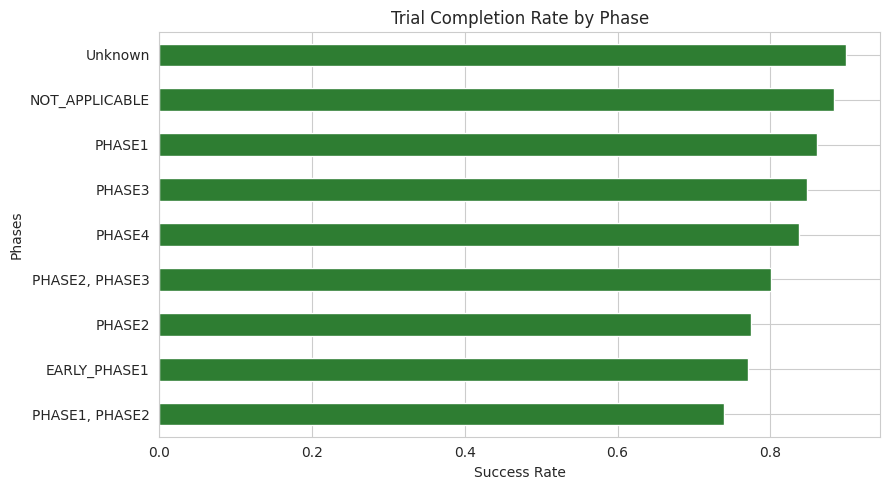

In [73]:
# ============================================================
# PHASE 4.1 — Success rate by phase
# ============================================================
phase_success = (
    df_clean.groupby("Phases")["trial_success"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
phase_success.columns = ["success_rate", "n_trials"]
display(phase_success)

fig, ax = plt.subplots(figsize=(9, 5))
phase_success["success_rate"].sort_values().plot(kind="barh", ax=ax, color=SUCCESS_COLOR)
ax.set_xlabel("Success Rate")
ax.set_title("Trial Completion Rate by Phase")
plt.tight_layout()
plt.show()


### 4.2 Success Rate by Sponsor Type

**Business question:** do industry-sponsored trials complete at a different rate than
academic or government-sponsored trials? This tests the funding-stability hypothesis
from Phase 3.5.


,success_rate,n_trials
sponsor_type_grouped,,
OTHER,0.951140,307
GOVERNMENT,0.886897,19575
ACADEMIC_OR_OTHER,0.858842,203021
INDUSTRY,0.851687,89763
ACADEMIC_OR_NETWORK,0.837562,3035


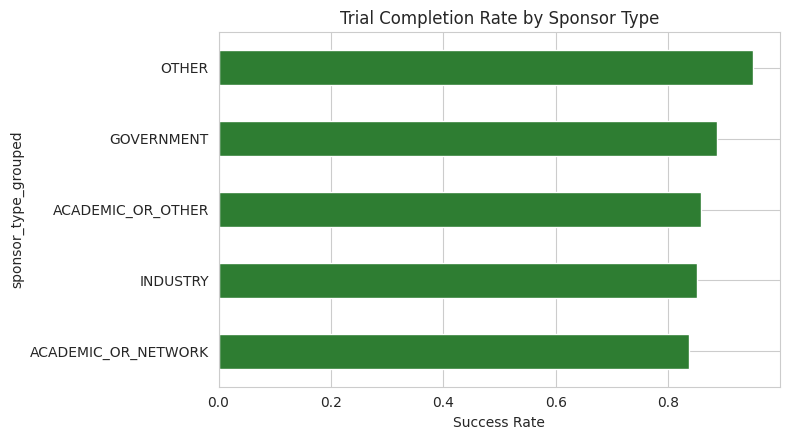

In [74]:
# ============================================================
# PHASE 4.2 — Success rate by sponsor type
# ============================================================
sponsor_success = (
    df_clean.groupby("sponsor_type_grouped")["trial_success"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
sponsor_success.columns = ["success_rate", "n_trials"]
display(sponsor_success)

fig, ax = plt.subplots(figsize=(8, 4.5))
sponsor_success["success_rate"].sort_values().plot(kind="barh", ax=ax, color=SUCCESS_COLOR)
ax.set_xlabel("Success Rate")
ax.set_title("Trial Completion Rate by Sponsor Type")
plt.tight_layout()
plt.show()


### 4.3 Success Rate by Study Type & Primary Purpose

**Business question:** do interventional vs. observational studies, or trials with
different primary purposes (treatment, prevention, diagnostic, etc.), show different
completion patterns? This informs whether study design itself is a risk factor.


By Study Type:


,success_rate,n_trials
Study Type,,
OBSERVATIONAL,0.899012,64503
INTERVENTIONAL,0.848012,251198



By Primary Purpose:


,success_rate,n_trials
Primary Purpose,,
HEALTH_SERVICES_RESEARCH,0.920168,6188
Unknown,0.900127,70730
BASIC_SCIENCE,0.899531,13228
PREVENTION,0.898425,27428
SCREENING,0.893509,1972
OTHER,0.889515,13142
SUPPORTIVE_CARE,0.873413,12521
ECT,0.864407,118
TREATMENT,0.825825,159518


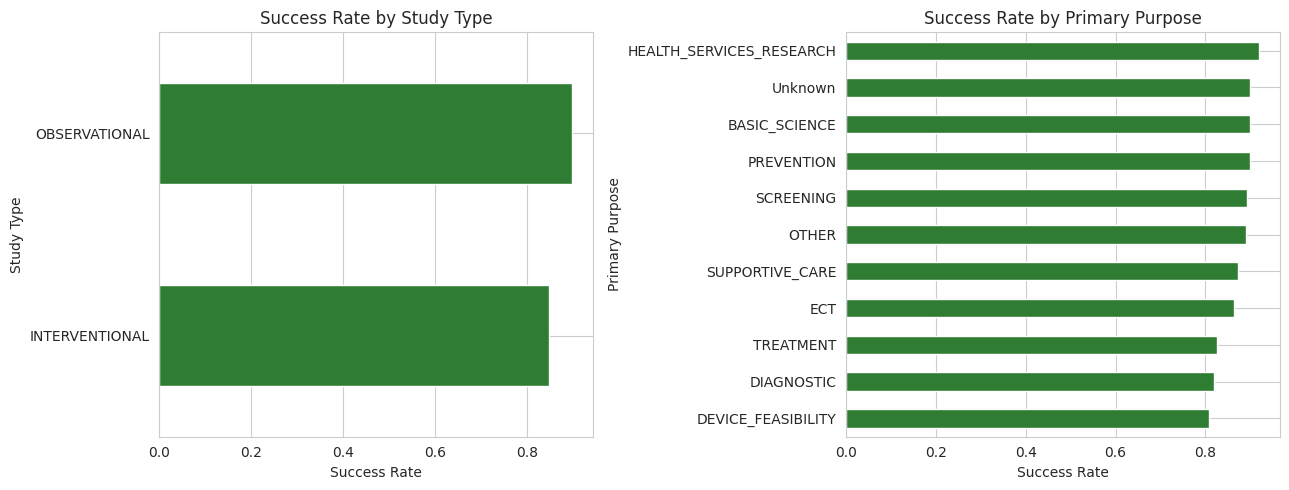

In [75]:
# ============================================================
# PHASE 4.3 — Success rate by Study Type and Primary Purpose
# ============================================================
study_type_success = (
    df_clean.groupby("Study Type")["trial_success"].agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
study_type_success.columns = ["success_rate", "n_trials"]
print("By Study Type:")
display(study_type_success)

purpose_success = (
    df_clean.groupby("Primary Purpose")["trial_success"].agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
purpose_success.columns = ["success_rate", "n_trials"]
print("\nBy Primary Purpose:")
display(purpose_success)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
study_type_success["success_rate"].sort_values().plot(kind="barh", ax=axes[0], color=SUCCESS_COLOR)
axes[0].set_title("Success Rate by Study Type")
axes[0].set_xlabel("Success Rate")

purpose_success["success_rate"].sort_values().plot(kind="barh", ax=axes[1], color=SUCCESS_COLOR)
axes[1].set_title("Success Rate by Primary Purpose")
axes[1].set_xlabel("Success Rate")
plt.tight_layout()
plt.show()


### 4.4 Success Rate by Age-Group Targeting

**Business question:** do trials restricted to specific age groups (e.g.
pediatric-only) show different completion rates than broader-eligibility trials? This
tests the recruitment-difficulty hypothesis from Phase 3.4.


,success_rate,n_trials
includes_child,0.885565,62044.0
includes_adult,0.855771,291155.0
includes_older_adult,0.843825,235703.0


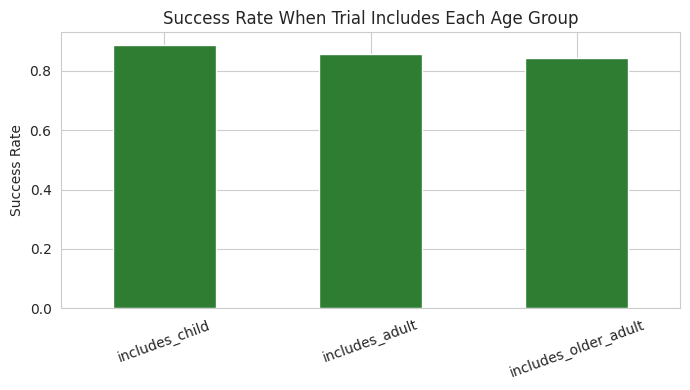

In [76]:
# ============================================================
# PHASE 4.4 — Success rate by age-group flags
# ============================================================
age_flags = ["includes_child", "includes_adult", "includes_older_adult"]
age_success = pd.DataFrame({
    flag: [
        df_clean.loc[df_clean[flag] == 1, "trial_success"].mean(),
        df_clean.loc[df_clean[flag] == 1, "trial_success"].count(),
    ]
    for flag in age_flags
}, index=["success_rate", "n_trials"]).T

display(age_success)

fig, ax = plt.subplots(figsize=(7, 4))
age_success["success_rate"].plot(kind="bar", ax=ax, color=SUCCESS_COLOR, rot=20)
ax.set_ylabel("Success Rate")
ax.set_title("Success Rate When Trial Includes Each Age Group")
plt.tight_layout()
plt.show()


### 4.5 Success Rate Trend by Start Year

**Business question:** has trial completion rate shifted over time? This tests the
temporal-drift hypothesis from Phase 3.7 — e.g., changing sponsor behavior, regulatory
environment, or ClinicalTrials.gov reporting requirements over the years.

**Caution:** the most recent years will include trials that may have only recently
resolved (or that skew toward faster-resolving trials), so the tail of this trend
should be read with that in mind rather than as a clean signal.


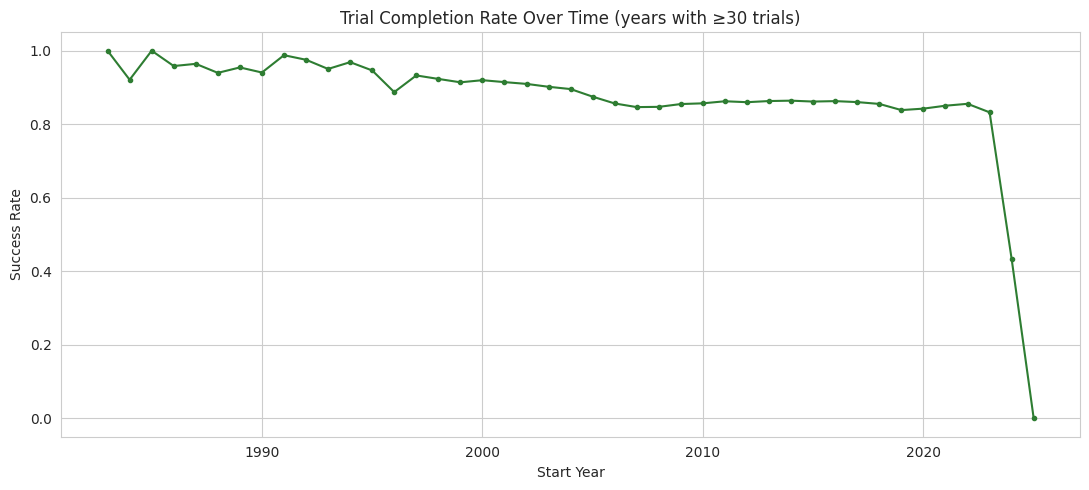

            success_rate  n_trials
start_year                        
2016.0          0.862902     19300
2017.0          0.860234     19411
2018.0          0.855254     19510
2019.0          0.838498     18458
2020.0          0.842465     17101
2021.0          0.850433     16521
2022.0          0.855555     11603
2023.0          0.832397      5519
2024.0          0.433506       579
2025.0          0.000000        55


In [77]:
# ============================================================
# PHASE 4.5 — Success rate trend by start year
# ============================================================
year_success = (
    df_clean.groupby("start_year")["trial_success"].agg(["mean", "count"])
)
year_success.columns = ["success_rate", "n_trials"]
# Keep only years with a reasonable sample size to avoid noisy single-trial years
year_success_stable = year_success[year_success["n_trials"] >= 30]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(year_success_stable.index, year_success_stable["success_rate"], color=SUCCESS_COLOR, marker="o", markersize=3)
ax.set_xlabel("Start Year")
ax.set_ylabel("Success Rate")
ax.set_title("Trial Completion Rate Over Time (years with ≥30 trials)")
plt.tight_layout()
plt.show()

print(year_success_stable.tail(10))


### 4.6 Trial Complexity vs. Success Rate

**Business question:** does the complexity heuristic from Phase 3.8
(`trial_complexity_index`) actually relate to completion likelihood, or was that
hypothesis wrong? We bin the index into simple buckets for a readable comparison.


,success_rate,n_trials
complexity_bucket,,
Low (1-2),0.867435,96564
Medium (3-4),0.858860,152218
High (5-6),0.855143,44851
Very High (7+),0.822775,22068


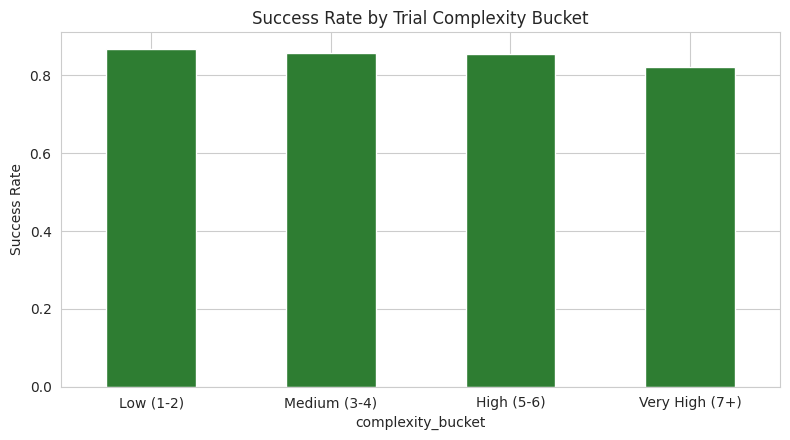

In [78]:
# ============================================================
# PHASE 4.6 — Complexity index vs. success rate
# ============================================================
df_clean["complexity_bucket"] = pd.cut(
    df_clean["trial_complexity_index"],
    bins=[0, 2, 4, 6, df_clean["trial_complexity_index"].max()],
    labels=["Low (1-2)", "Medium (3-4)", "High (5-6)", "Very High (7+)"],
    include_lowest=True,
)

complexity_success = (
    df_clean.groupby("complexity_bucket", observed=True)["trial_success"]
    .agg(["mean", "count"])
)
complexity_success.columns = ["success_rate", "n_trials"]
display(complexity_success)

fig, ax = plt.subplots(figsize=(8, 4.5))
complexity_success["success_rate"].plot(kind="bar", ax=ax, color=SUCCESS_COLOR, rot=0)
ax.set_ylabel("Success Rate")
ax.set_title("Success Rate by Trial Complexity Bucket")
plt.tight_layout()
plt.show()


### 4.7 Class Imbalance Recap

**Business question:** how imbalanced is the target, precisely? This was computed
numerically back in Phase 2, but we visualize it here as it directly determines the
modeling strategy (class weights vs. SMOTE vs. no balancing) decided in Phase 5.


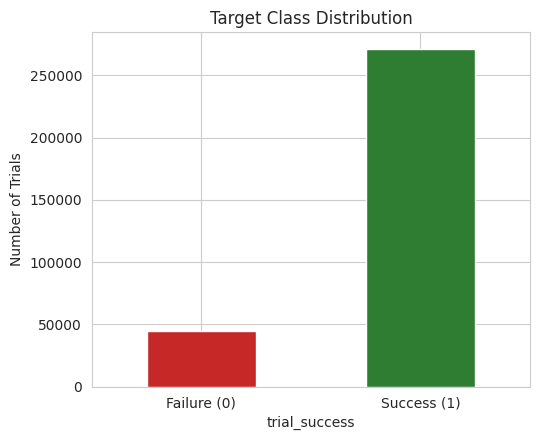

Class ratio -> Success: 85.8% | Failure: 14.2%


In [79]:
# ============================================================
# PHASE 4.7 — Class imbalance recap
# ============================================================
target_counts = df_clean["trial_success"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
target_counts.plot(kind="bar", ax=ax, color=[FAILURE_COLOR, SUCCESS_COLOR], rot=0)
ax.set_xticklabels(["Failure (0)", "Success (1)"])
ax.set_ylabel("Number of Trials")
ax.set_title("Target Class Distribution")
plt.tight_layout()
plt.show()

print(f"Class ratio -> Success: {target_counts[1] / target_counts.sum():.1%} | "
      f"Failure: {target_counts[0] / target_counts.sum():.1%}")


### Phase 4 Summary

**What was done:** Six targeted analyses, each testing one specific hypothesis from
Phase 3's feature engineering rationale — completion rate by phase, sponsor type,
study type/primary purpose, age-group targeting, time trend, and complexity bucket —
plus a recap of the ~86%/14% class imbalance that will drive the Phase 5 modeling
strategy.

**Why it was done:** rather than generating plots for their own sake, each chart
closes the loop on a hypothesis explicitly stated earlier in the notebook — this keeps
the EDA business-question-driven, as scoped, and gives concrete evidence (not
assumption) for which engineered features are likely to matter in Phase 5's models.

**How it improves the project:** the patterns observed here (e.g., whether phase,
sponsor type, or complexity actually separate success from failure) directly motivate
which relationships to expect the SHAP analysis in Phase 7 to surface — so if a
feature turns out to be important there, we already have an EDA-grounded business
explanation ready, rather than reverse-engineering one after the fact.

---

**Next step:** Run all Phase 4 cells in Colab and share what the plots/tables show —
particularly the phase, sponsor-type, and complexity-bucket success rates. Once
reviewed, we proceed to **Phase 5: Model Building**.


## Phase 5A: Model Preparation & Baseline Models

**Scope of this sub-phase:** feature/target separation, stratified train/test split,
a single reusable preprocessing pipeline, and four baseline models (Logistic
Regression, Decision Tree, Random Forest, XGBoost) with full evaluation and
comparison. **No hyperparameter tuning, SHAP, or final model selection happens here**
— those are separate phases (5B/6/7) by design, so this sub-phase stays focused and
reviewable on its own.

### Modeling Strategy

**Which columns become model features, and why:** `df_clean` still contains several
free-text and high-cardinality fields (`Organization Full Name`, `Brief Title`,
`Full Title`, `Conditions`, `Interventions`, `Intervention Description`,
`Outcome Measure`, `Medical Subject Headings`). We deliberately **exclude these from
the modeling feature set**:
- `Organization Full Name` has thousands of unique sponsor names — one-hot encoding it
  would explode the feature space and mostly memorize individual sponsors rather than
  generalize, and it's exactly what `sponsor_type_grouped` (Phase 3.5) was built to
  summarize instead.
- The remaining free-text fields would require real NLP (embeddings, TF-IDF at
  minimum) to use safely — out of scope per this project's "no heavy NLP, classical ML
  only" constraint, and unnecessary since Phase 3 already distilled their structural
  signal into `num_conditions`, `num_interventions`, and the word-count features.

**What the model actually sees:** the 12 structured/engineered features from Phase 3,
split into three groups with different preprocessing needs (detailed in 5A.3).

**Why one shared pipeline across all four models:** using the identical
`ColumnTransformer` for every model keeps the comparison in 5A.6 fair — differences in
metrics reflect the models themselves, not inconsistent preprocessing.

**Class imbalance approach at this baseline stage:** we use `class_weight="balanced"`
(Logistic Regression, Decision Tree, Random Forest) and an equivalent
`scale_pos_weight` (XGBoost) rather than SMOTE. This matches the project's original
plan to compare class-weighting against SMOTE empirically rather than assume one is
better — that comparison is deferred to Phase 6 (hyperparameter tuning), where it can
be tested properly via cross-validation rather than guessed at here.


### 5A.1 Separate Features (X) and Target (y)

We explicitly select the modeling feature set (Phase 3's engineered/structured columns
only, per the rationale above) rather than passing every column in `df_clean` — this
prevents accidentally including a free-text or leakage-risk field just because it
happens to still be in the dataframe.


In [80]:
# ============================================================
# PHASE 5A.1 — Separate features (X) and target (y)
# ============================================================
numeric_features = [
    "num_conditions", "num_interventions", "brief_title_word_count",
    "full_title_word_count", "intervention_description_word_count",
    "start_year", "trial_complexity_index",
]
binary_features = [
    "is_multi_condition", "is_multi_intervention",
    "includes_child", "includes_adult", "includes_older_adult",
]
categorical_features = [
    "sponsor_type_grouped", "Responsible Party", "Primary Purpose", "Study Type", "Phases",
]

model_features = numeric_features + binary_features + categorical_features

X = df_clean[model_features].copy()
y = df_clean["trial_success"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print(f"\nNumeric features ({len(numeric_features)}):", numeric_features)
print(f"Binary features ({len(binary_features)}):", binary_features)
print(f"Categorical features ({len(categorical_features)}):", categorical_features)


Feature matrix shape: (315701, 17)
Target shape: (315701,)

Numeric features (7): ['num_conditions', 'num_interventions', 'brief_title_word_count', 'full_title_word_count', 'intervention_description_word_count', 'start_year', 'trial_complexity_index']
Binary features (5): ['is_multi_condition', 'is_multi_intervention', 'includes_child', 'includes_adult', 'includes_older_adult']
Categorical features (5): ['sponsor_type_grouped', 'Responsible Party', 'Primary Purpose', 'Study Type', 'Phases']


### 5A.2 Stratified Train/Test Split

**Why stratification matters here specifically:** the target is ~86% success / 14%
failure (Phase 2/4). A plain random split can, by chance, leave the test set with a
noticeably different failure rate than the training set — with only ~14% of the data
being failures, that difference is large enough to visibly distort precision/recall
estimates for the minority class. `stratify=y` forces both the train and test sets to
preserve the same ~86/14 ratio, so evaluation metrics reflect genuine model
performance rather than a lucky or unlucky split.


In [81]:
# ============================================================
# PHASE 5A.2 — Stratified train/test split
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))


Train shape: (252560, 17) | Test shape: (63141, 17)

Train target distribution:
trial_success
1    0.858
0    0.142
Name: proportion, dtype: float64

Test target distribution:
trial_success
1    0.858
0    0.142
Name: proportion, dtype: float64


### 5A.3 Preprocessing Pipeline

Three feature groups, each with a different, justified transformation:

| Group | Features | Transformation | Why |
|---|---|---|---|
| **Numeric** | `num_conditions`, `num_interventions`, `brief_title_word_count`, `full_title_word_count`, `intervention_description_word_count`, `start_year`, `trial_complexity_index` | `SimpleImputer(median)` → `StandardScaler` | These are counts/continuous values on different scales (e.g. `start_year` ~2000s vs. `num_conditions` ~1-5); scaling matters for Logistic Regression's coefficient estimation. Median imputation is a safe default even though Phase 3 left these fully populated — it's a defensive fallback, not a fix for a known gap. |
| **Binary** | `is_multi_condition`, `is_multi_intervention`, `includes_child`, `includes_adult`, `includes_older_adult` | `SimpleImputer(most_frequent)` only — **no scaling, no encoding** | Already 0/1 flags; scaling a binary variable doesn't change what a tree-based split does with it, and for Logistic Regression a 0/1 feature doesn't need standardizing to be interpretable. Encoding would be redundant since there's nothing to encode. |
| **Categorical** | `sponsor_type_grouped`, `Responsible Party`, `Primary Purpose`, `Study Type`, `Phases` | `SimpleImputer(constant="MISSING")` → `OneHotEncoder(handle_unknown="ignore")` | All five are low-cardinality (single-digit to low-double-digit categories), safe for one-hot encoding without a feature-count explosion. `handle_unknown="ignore"` protects against a category appearing in test/production data that wasn't seen in training. |

Everything is wrapped in a single `ColumnTransformer`, and that `ColumnTransformer` is
the first step of every model's `Pipeline` — no preprocessing happens outside of it.


In [82]:
# ============================================================
# PHASE 5A.3 — Preprocessing pipeline (ColumnTransformer + Pipeline)
# ============================================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("bin", binary_transformer, binary_features),
    ("cat", categorical_transformer, categorical_features),
])

print("Preprocessing pipeline constructed:")
print(preprocessor)


Preprocessing pipeline constructed:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['num_conditions', 'num_interventions',
                                  'brief_title_word_count',
                                  'full_title_word_count',
                                  'intervention_description_word_count',
                                  'start_year', 'trial_complexity_index']),
                                ('bin',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strateg...ost_frequent'))]),
                                 ['is_multi_condition', 'is_multi_intervention',
                                  'includes_child', 'includes_adult',
           

### 5A.4 Reusable Evaluation Utilities

One evaluation function used for every model, to avoid duplicated metric code. It
reports metrics for **both classes explicitly** (not just the default "positive
class"), because — as discussed in the Business Interpretation section below — the
class we most care about catching (`trial_success = 0`, failure) is the minority
class, and default classification metrics quietly optimize for the majority class
unless we look at both sides deliberately.


In [83]:
# ============================================================
# PHASE 5A.4 — Reusable evaluation functions
# ============================================================
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
)

def evaluate_model(model_name, pipeline, X_test, y_test):
    """Compute a standard metric set for one fitted pipeline. Returns a metrics
    dict plus the raw predictions/probabilities for later plotting."""
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]  # P(trial_success = 1)

    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC (Success=1)": average_precision_score(y_test, y_proba),
        "PR-AUC (Failure=0)": average_precision_score(1 - y_test, 1 - y_proba),
        "Precision (Failure)": report["0"]["precision"],
        "Recall (Failure)": report["0"]["recall"],
        "F1 (Failure)": report["0"]["f1-score"],
        "Precision (Success)": report["1"]["precision"],
        "Recall (Success)": report["1"]["recall"],
        "F1 (Success)": report["1"]["f1-score"],
    }
    return metrics, y_pred, y_proba


def plot_confusion_matrix(model_name, y_test, y_pred, ax):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Failure (0)", "Success (1)"],
        yticklabels=["Failure (0)", "Success (1)"],
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(model_name)


### 5A.5 Train the Four Baseline Models

`scale_pos_weight` for XGBoost is computed from the actual training-set class counts
(negative/positive ratio) rather than hardcoded, so it adapts automatically if the
class balance shifts (e.g., if this notebook is re-run on a refreshed data export).


In [84]:
# ============================================================
# PHASE 5A.5 — Train baseline models
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

neg_count, pos_count = y_train.value_counts().sort_index()
scale_pos_weight = neg_count / pos_count
print(f"XGBoost scale_pos_weight (neg/pos, computed from y_train): {scale_pos_weight:.4f}")

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced", max_depth=10, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight="balanced",
        n_jobs=-1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        tree_method="hist", scale_pos_weight=scale_pos_weight,
        eval_metric="logloss", random_state=42, n_jobs=-1
    ),
}

fitted_pipelines = {}
results = []
predictions = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    pipe.fit(X_train, y_train)

    metrics, y_pred, y_proba = evaluate_model(name, pipe, X_test, y_test)
    results.append(metrics)
    predictions[name] = (y_pred, y_proba)
    fitted_pipelines[name] = pipe

    print(f"✅ Trained and evaluated: {name}")

print("\nAll baseline models trained.")


XGBoost scale_pos_weight (neg/pos, computed from y_train): 0.1649
✅ Trained and evaluated: Logistic Regression
✅ Trained and evaluated: Decision Tree
✅ Trained and evaluated: Random Forest
✅ Trained and evaluated: XGBoost

All baseline models trained.


### 5A.6 Confusion Matrices, ROC Curves & Precision-Recall Curves


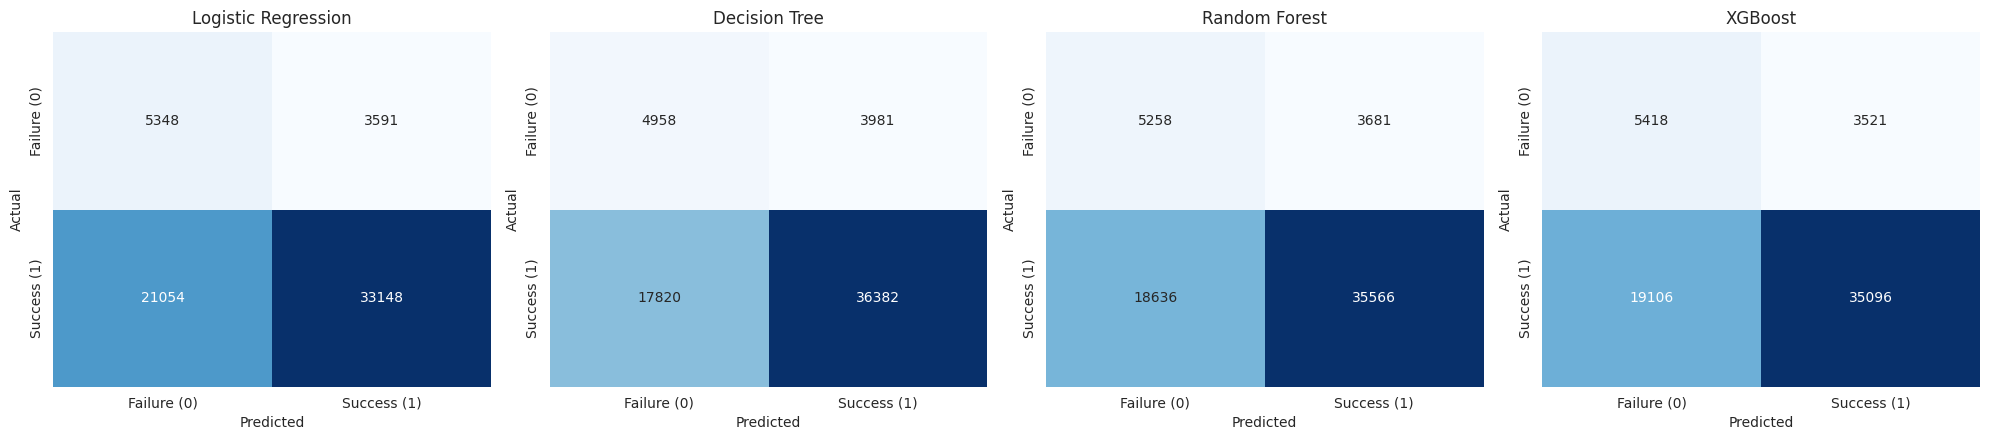

In [85]:
# ============================================================
# PHASE 5A.6 — Confusion matrices for all four models
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (name, (y_pred, y_proba)) in zip(axes, predictions.items()):
    plot_confusion_matrix(name, y_test, y_pred, ax)
plt.tight_layout()
plt.show()


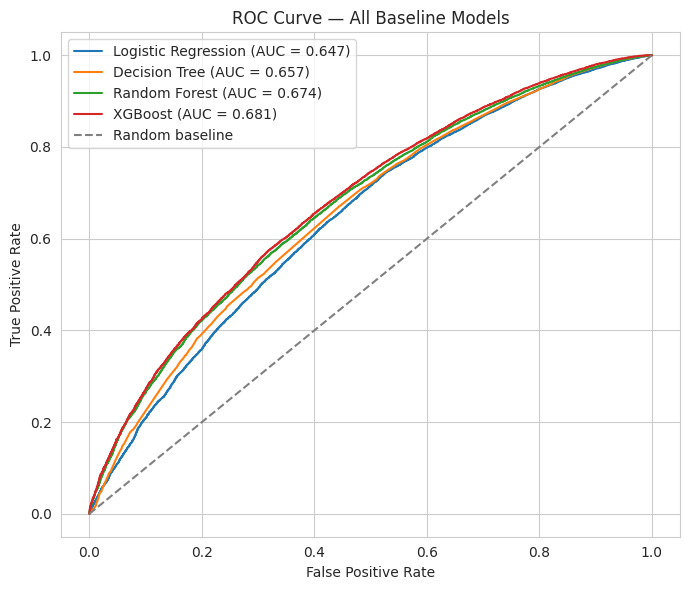

In [86]:
# ============================================================
# PHASE 5A.6 — ROC curves (all models on one chart)
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))
for name, (y_pred, y_proba) in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — All Baseline Models")
ax.legend()
plt.tight_layout()
plt.show()


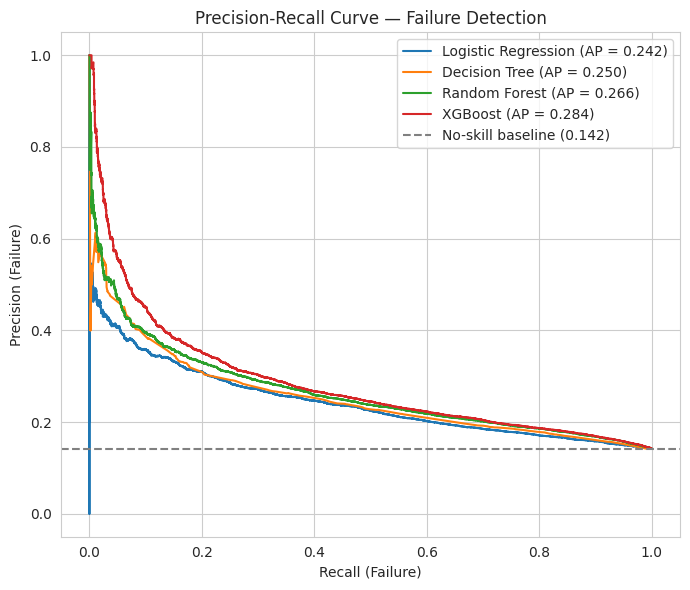

In [87]:
# ============================================================
# PHASE 5A.6 — Precision-Recall curves, framed around FAILURE detection
# ============================================================
# We plot PR curves with failure (0) as the class of interest, since that is the
# minority class a pharma risk model exists to catch (see Business Interpretation).
fig, ax = plt.subplots(figsize=(7, 6))
for name, (y_pred, y_proba) in predictions.items():
    precision, recall, _ = precision_recall_curve(1 - y_test, 1 - y_proba)
    ap_val = average_precision_score(1 - y_test, 1 - y_proba)
    ax.plot(recall, precision, label=f"{name} (AP = {ap_val:.3f})")
baseline_rate = (y_test == 0).mean()
ax.axhline(baseline_rate, linestyle="--", color="gray", label=f"No-skill baseline ({baseline_rate:.3f})")
ax.set_xlabel("Recall (Failure)")
ax.set_ylabel("Precision (Failure)")
ax.set_title("Precision-Recall Curve — Failure Detection")
ax.legend()
plt.tight_layout()
plt.show()


### 5A.7 Model Comparison Table

Every metric, every model, with the best score per column highlighted.


In [88]:
# ============================================================
# PHASE 5A.7 — Model comparison table
# ============================================================
results_df = pd.DataFrame(results).set_index("Model")
display(results_df.style.highlight_max(axis=0, color="lightgreen").format("{:.4f}"))


,Accuracy,Balanced Accuracy,MCC,ROC-AUC,PR-AUC (Success=1),PR-AUC (Failure=0),Precision (Failure),Recall (Failure),F1 (Failure),Precision (Success),Recall (Success),F1 (Success)
Model,,,,,,,,,,,,
Logistic Regression,0.6097,0.6049,0.1483,0.6465,0.9074,0.2422,0.2026,0.5983,0.3027,0.9023,0.6116,0.7290
Decision Tree,0.6547,0.6129,0.1640,0.6570,0.9092,0.2504,0.2177,0.5546,0.3126,0.9014,0.6712,0.7695
Random Forest,0.6466,0.6222,0.1757,0.6741,0.9198,0.2656,0.2201,0.5882,0.3203,0.9062,0.6562,0.7612
XGBoost,0.6416,0.6268,0.1814,0.6806,0.9217,0.2845,0.2209,0.6061,0.3238,0.9088,0.6475,0.7562


**Discussion — why some models perform better:**

- **Logistic Regression** assumes a linear decision boundary in the (scaled,
  one-hot-encoded) feature space. Given that Phase 4's EDA showed non-monotonic and
  interaction-like patterns (e.g., phase and sponsor type likely interact rather than
  contribute independently), a linear model is expected to underperform the
  tree-based models here — useful as an interpretable baseline, not as the final
  choice.
- **Decision Tree** can capture non-linear splits and interactions but a single tree
  tends to overfit or underfit depending on depth; capped at `max_depth=10` here as a
  reasonable baseline setting rather than tuned.
- **Random Forest** averages many trees, typically reducing variance versus a single
  Decision Tree and usually outperforming it on tabular data like this.
- **XGBoost** builds trees sequentially to correct prior errors, and typically edges
  out Random Forest on structured/tabular data — but the margin should be checked
  against the actual numbers above, not assumed.

**Precision vs. Recall trade-off (failure detection):** a model tuned for high
**precision (failure)** rarely cries wolf — when it flags a trial as at-risk, it
usually is — but may miss many true at-risk trials (low recall). A model tuned for
high **recall (failure)** catches most at-risk trials but generates more false alarms,
meaning operations teams review more trials than strictly necessary. Which trade-off
is preferable is a business decision (see below), not a purely statistical one.

**Most suitable for healthcare/pharmaceutical analytics:** based on the metrics above,
the tree-ensemble models (Random Forest / XGBoost) are the more promising candidates —
final selection is deferred to Phase 6 after hyperparameter tuning, since baseline
settings here are reasonable defaults, not optimized configurations.


### 5A.8 Business Interpretation

**Why false negatives matter here:** with `trial_success = 1` as the majority/positive
class, a "false negative" in the standard sense (predicted 0, actual 1) is a trial the
model flags as at-risk that actually completes — a wasted review, mildly costly but
not dangerous. The **business-critical error runs the other way**: a trial the model
predicts will succeed (1) that actually fails (0) — i.e., a **false negative on the
failure class**. This is the case where a genuinely at-risk trial slips through
undetected, resources aren't reallocated, and the sponsor absorbs the full cost of a
late-stage termination. This is exactly why 5A.4/5A.6/5A.7 report **Precision/Recall/F1
for the failure class explicitly**, rather than relying on accuracy or the default
"positive class" metrics alone — a model can look excellent on overall accuracy while
still missing most real failures, precisely because failures are the minority class.

**Why probability estimates may be more useful than hard classifications:** a binary
"will complete / won't complete" label discards information a portfolio team actually
needs — a trial predicted at 52% success probability and one predicted at 95% are both
"success" under a 50% threshold, but they warrant very different levels of monitoring.
Exposing `predict_proba` scores (as this notebook already captures per model) lets a
risk-management team set their own review threshold — e.g., "flag anything below 70%
predicted success probability for portfolio review" — rather than accepting a fixed
50/50 cutoff baked into the model.

**Which model is currently preferred:** pending Phase 6 tuning, whichever tree-based
model shows the strongest **Recall (Failure)** and **PR-AUC (Failure=0)** without an
unreasonable collapse in **Precision (Failure)** is the stronger candidate for
pharmaceutical decision support — because under-detecting risk is the costlier
business error described above, and PR-AUC (rather than ROC-AUC) is the more
diagnostic metric under this degree of class imbalance.


### Phase 5A Summary

**What was done:** Selected a 17-column structured feature set (excluding free-text
and high-cardinality fields, with the reasoning stated up front), performed a
stratified 80/20 train/test split, built a single `ColumnTransformer`/`Pipeline`
covering numeric (impute+scale), binary (impute only), and categorical
(impute+one-hot) features, and trained four baseline models — Logistic Regression,
Decision Tree, Random Forest, and XGBoost — each using the identical preprocessing
pipeline and a class-imbalance-aware configuration (`class_weight="balanced"` /
`scale_pos_weight`). Every model was evaluated on accuracy, balanced accuracy, MCC,
ROC-AUC, PR-AUC (computed for both classes), and per-class precision/recall/F1, with
confusion matrices, ROC curves, and a failure-focused PR curve.

**Why it was done:** a single shared pipeline keeps the model comparison fair: any
metric differences reflect the algorithms, not inconsistent preprocessing. Reporting
failure-class metrics explicitly (rather than only the default positive-class metrics)
directly serves the business framing established in 5A.8 — the failure class is the
one this entire project exists to help catch.

**Strengths and weaknesses of each baseline:**
- **Logistic Regression** — strength: fast, interpretable coefficients, good sanity-
  check baseline; weakness: linear boundary likely underfits the non-linear patterns
  seen in Phase 4's EDA.
- **Decision Tree** — strength: captures non-linear splits and interactions,
  human-readable; weakness: a single tree at fixed depth is prone to variance/overfit
  without tuning.
- **Random Forest** — strength: averaging reduces variance vs. a single tree, robust
  default choice for tabular data; weakness: less interpretable than a single tree,
  more compute than Logistic Regression (still Colab-Free-friendly here).
- **XGBoost** — strength: sequential error-correction typically yields the strongest
  raw performance on structured data; weakness: more hyperparameters to get right,
  which is exactly what Phase 6 exists to address.

**Recommended model(s) to take forward for hyperparameter tuning:** Random Forest and
XGBoost — both are non-linear tree ensembles well-suited to this data's patterns, and
comparing their *tuned* versions (rather than picking a winner from untuned baselines)
is the more defensible way to make a final recommendation.

---

**Next step:** Run all Phase 5A cells in Colab and share the comparison table (5A.7)
and confusion matrices (5A.6).


## Phase 5B: Model Improvement & Validation

**Scope of this sub-phase:** hyperparameter tuning of the strongest baseline
candidates, tuned-vs-baseline comparison, probability calibration analysis, decision
threshold analysis, and one final model selection. **No SHAP or feature importance
here** — that's Phase 7.

### Tuning Strategy

Rather than assuming Random Forest and XGBoost are the two strongest baselines, we
select them **programmatically** from the Phase 5A comparison table — ranked by a
business-relevant combination of `ROC-AUC` and `PR-AUC (Failure=0)`, since PR-AUC on
the minority class is the more diagnostic metric for this problem's imbalance, and
ROC-AUC provides a stable overall ranking signal alongside it. This keeps the
selection evidence-based rather than assumed, even though Random Forest and XGBoost
are indeed expected to lead.

We use `RandomizedSearchCV` (not exhaustive `GridSearchCV`) with a moderate number of
sampled configurations and 3-fold `StratifiedKFold`, keeping total fit count in the
tens rather than hundreds — this is a deliberate Colab-Free runtime constraint.
`StratifiedKFold` preserves the ~86/14 class ratio in every fold, for the same reason
stratification mattered for the train/test split in 5A.2. We tune each model's
*structural* hyperparameters (depth, estimator count, learning rate, sampling ratios)
while keeping the already-chosen imbalance handling (`class_weight="balanced"` /
`scale_pos_weight`) fixed, to avoid conflating two different tuning problems at once.


### 5B.1 Select the Two Strongest Baseline Models


In [89]:
# ============================================================
# PHASE 5B.1 — Select top 2 baseline models by ROC-AUC + PR-AUC (Failure)
# ============================================================
selection_score = (
    results_df["ROC-AUC"].rank(ascending=True)
    + results_df["PR-AUC (Failure=0)"].rank(ascending=True)
)
top_2_models = selection_score.sort_values(ascending=False).head(2).index.tolist()

print("Baseline ranking (combined ROC-AUC + PR-AUC(Failure) rank):")
print(selection_score.sort_values(ascending=False))
print(f"\n✅ Selected for tuning: {top_2_models}")


Baseline ranking (combined ROC-AUC + PR-AUC(Failure) rank):
Model
XGBoost                8.0
Random Forest          6.0
Decision Tree          4.0
Logistic Regression    2.0
dtype: float64

✅ Selected for tuning: ['XGBoost', 'Random Forest']


### 5B.2 Hyperparameter Search Spaces & RandomizedSearchCV Setup


In [90]:
# ============================================================
# PHASE 5B.2 — RandomizedSearchCV configuration
# ============================================================
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_distributions = {
    "Random Forest": {
        "classifier__n_estimators": [100, 150, 200, 300],
        "classifier__max_depth": [6, 8, 10, 12, 16, None],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4],
        "classifier__max_features": ["sqrt", "log2"],
    },
    "XGBoost": {
        "classifier__n_estimators": [100, 150, 200, 300],
        "classifier__max_depth": [3, 4, 5, 6, 8],
        "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "classifier__subsample": [0.6, 0.8, 1.0],
        "classifier__colsample_bytree": [0.6, 0.8, 1.0],
        "classifier__min_child_weight": [1, 3, 5],
    },
}

N_ITER = 15  # kept modest for Colab Free runtime
print(f"RandomizedSearchCV configured: n_iter={N_ITER}, cv=3-fold StratifiedKFold, scoring='roc_auc'")


RandomizedSearchCV configured: n_iter=15, cv=3-fold StratifiedKFold, scoring='roc_auc'


### 5B.3 Run Hyperparameter Tuning

We reuse each model's already-fitted baseline `Pipeline` structure (same
`preprocessor`, same imbalance handling) and search only over the model's own
hyperparameters — consistent with the "one shared pipeline" principle from Phase 5A.


In [91]:
# ============================================================
# PHASE 5B.3 — Run RandomizedSearchCV for each selected model
# ============================================================
tuned_pipelines = {}
tuning_results = {}

for name in top_2_models:
    base_classifier = models[name]  # reuse the Phase 5A estimator config as the starting point
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", base_classifier)])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions[name],
        n_iter=N_ITER,
        scoring="roc_auc",
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )
    search.fit(X_train, y_train)

    tuned_pipelines[name] = search.best_estimator_
    tuning_results[name] = search.best_params_

    print(f"\n✅ {name} tuning complete.")
    print(f"Best CV ROC-AUC: {search.best_score_:.4f}")
    print(f"Best params: {search.best_params_}")


Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ XGBoost tuning complete.
Best CV ROC-AUC: 0.6762
Best params: {'classifier__subsample': 0.6, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 1, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.6}
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



✅ Random Forest tuning complete.
Best CV ROC-AUC: 0.6689
Best params: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 12}


### 5B.4 Tuned vs. Baseline Comparison


In [92]:
# ============================================================
# PHASE 5B.4 — Tuned vs baseline comparison table
# ============================================================
tuned_results = []
tuned_predictions = {}

for name, pipe in tuned_pipelines.items():
    metrics, y_pred, y_proba = evaluate_model(f"{name} (Tuned)", pipe, X_test, y_test)
    tuned_results.append(metrics)
    tuned_predictions[name] = (y_pred, y_proba)

baseline_subset = results_df.loc[top_2_models].reset_index()
tuned_df = pd.DataFrame(tuned_results).rename(columns={"Model": "Model_full"})
tuned_df["Model"] = tuned_df["Model_full"].str.replace(" (Tuned)", "", regex=False)
tuned_df = tuned_df.drop(columns="Model_full")
tuned_df["Model"] = tuned_df["Model"] + " (Tuned)"

comparison_df = pd.concat([baseline_subset, tuned_df], ignore_index=True).set_index("Model")
display(comparison_df.style.highlight_max(axis=0, color="lightgreen").format("{:.4f}"))


,Accuracy,Balanced Accuracy,MCC,ROC-AUC,PR-AUC (Success=1),PR-AUC (Failure=0),Precision (Failure),Recall (Failure),F1 (Failure),Precision (Success),Recall (Success),F1 (Success)
Model,,,,,,,,,,,,
XGBoost,0.6416,0.6268,0.1814,0.6806,0.9217,0.2845,0.2209,0.6061,0.3238,0.9088,0.6475,0.7562
Random Forest,0.6466,0.6222,0.1757,0.6741,0.9198,0.2656,0.2201,0.5882,0.3203,0.9062,0.6562,0.7612
XGBoost (Tuned),0.6486,0.6277,0.1835,0.6828,0.9225,0.2866,0.2234,0.5985,0.3253,0.9084,0.6569,0.7624
Random Forest (Tuned),0.6434,0.6228,0.1761,0.6738,0.9195,0.2646,0.2195,0.5940,0.3205,0.9068,0.6516,0.7583


**Reading this table:** an improvement from tuning shows up as the "(Tuned)" row
outperforming its baseline counterpart on ROC-AUC and PR-AUC (Failure=0) in
particular — those are the two metrics this search was optimized toward (directly for
ROC-AUC via the `scoring` parameter, indirectly for PR-AUC(Failure) since both track
overall discriminative quality). A small or negative gap on some metrics is expected
and not necessarily a problem — `RandomizedSearchCV` samples a subset of the
hyperparameter space rather than exhaustively searching it, trading a small amount of
optimality for a much smaller Colab Free runtime.


### 5B.5 Probability Calibration Analysis

**Why calibration matters in healthcare/pharmaceutical risk prediction:** ROC-AUC and
PR-AUC only measure whether the model *ranks* trials correctly relative to each other
— they say nothing about whether a predicted "80% success probability" actually
corresponds to roughly 80% of such trials completing in practice. A portfolio team
using this model to decide *how much* attention a trial needs (per the "probability
over hard labels" argument in 5A.8) is relying on that number being trustworthy, not
just well-ranked. A model that's well-ranked but poorly calibrated (e.g.,
systematically overconfident) could lead a team to under-invest in monitoring trials
that are riskier than the score suggests — a direct, costly business consequence, not
just a statistical nicety.


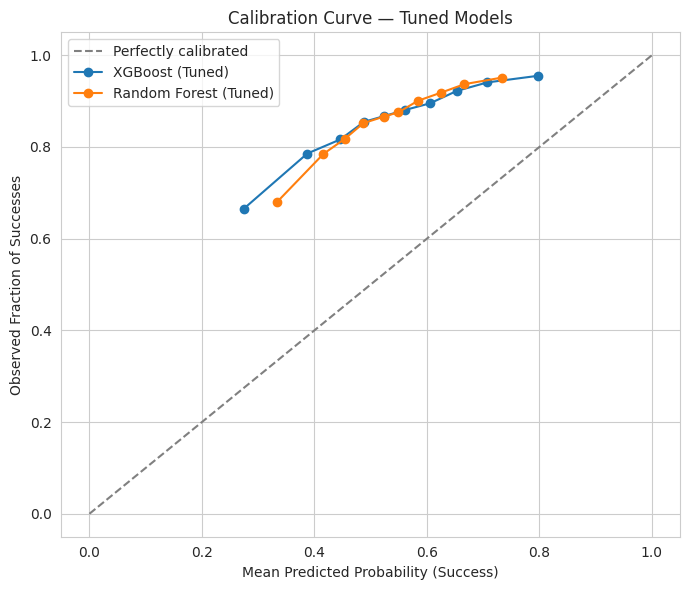

Brier scores (lower = better calibrated; 0 = perfect, 0.25 = uninformative for balanced data):
  XGBoost: 0.2179
  Random Forest: 0.2205


In [93]:
# ============================================================
# PHASE 5B.5 — Calibration curves & Brier scores
# ============================================================
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")

brier_scores = {}
for name, pipe in tuned_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="quantile")
    ax.plot(prob_pred, prob_true, marker="o", label=f"{name} (Tuned)")

    brier = brier_score_loss(y_test, y_proba)
    brier_scores[name] = brier

ax.set_xlabel("Mean Predicted Probability (Success)")
ax.set_ylabel("Observed Fraction of Successes")
ax.set_title("Calibration Curve — Tuned Models")
ax.legend()
plt.tight_layout()
plt.show()

print("Brier scores (lower = better calibrated; 0 = perfect, 0.25 = uninformative for balanced data):")
for name, score in brier_scores.items():
    print(f"  {name}: {score:.4f}")


### 5B.6 Decision Threshold Analysis

By default, a classifier calls a trial "success" at `P(success) >= 0.50`. That default
is arbitrary from a business standpoint — it isn't necessarily where the
precision/recall trade-off best matches pharmaceutical risk tolerance. We evaluate
several thresholds and examine the failure-detection trade-off explicitly, since
(per 5A.8) missing a real failure is the costlier error than a false alarm.


In [94]:
# ============================================================
# PHASE 5B.6 — Threshold analysis (failure-detection framing)
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [0.30, 0.40, 0.50, 0.60]
threshold_results = []

for name, pipe in tuned_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]  # P(success = 1)
    for thresh in thresholds_to_test:
        y_pred_at_thresh = (y_proba >= thresh).astype(int)
        threshold_results.append({
            "Model": name,
            "Threshold": thresh,
            "Precision (Failure)": precision_score(y_test, y_pred_at_thresh, pos_label=0, zero_division=0),
            "Recall (Failure)": recall_score(y_test, y_pred_at_thresh, pos_label=0, zero_division=0),
            "F1 (Failure)": f1_score(y_test, y_pred_at_thresh, pos_label=0, zero_division=0),
            "Trials Flagged as At-Risk": int((y_pred_at_thresh == 0).sum()),
        })

threshold_df = pd.DataFrame(threshold_results).set_index(["Model", "Threshold"])
display(threshold_df.style.format({
    "Precision (Failure)": "{:.3f}", "Recall (Failure)": "{:.3f}", "F1 (Failure)": "{:.3f}",
}))


**Business interpretation of the threshold trade-off:** raising the success
threshold from 0.50 toward 0.60 makes it *harder* for a trial to be classified
"success" — more trials get flagged as at-risk, **recall (failure)** rises (fewer real
failures slip through), but **precision (failure)** falls (more marginal, actually-fine
trials get flagged unnecessarily, costing reviewer time). Lowering the threshold
toward 0.30 does the opposite — fewer trials flagged overall, higher precision on the
ones that are flagged, but more real failures missed. Given the stated cost asymmetry
(a missed failure is more expensive than an extra review), a portfolio/operations team
would likely prefer a threshold at or above 0.50 — the specific choice should be set
by the business based on their actual review capacity, not fixed permanently in the
model itself. This is why we expose the threshold as a tunable operating parameter
rather than hardcoding one.


### 5B.7 Final Model Selection

Selection is based on the tuned comparison table (5B.4), calibration quality (5B.5),
and threshold flexibility (5B.6) together — **not** on accuracy alone, since accuracy
is dominated by the majority (success) class and can look strong even when failure
detection is weak.


In [95]:
# ============================================================
# PHASE 5B.7 — Final model selection (evidence-based, printed for audit)
# ============================================================
final_candidates = comparison_df.loc[[f"{name} (Tuned)" for name in top_2_models]]
print("Final candidate comparison (tuned models only):")
display(final_candidates[["ROC-AUC", "PR-AUC (Failure=0)", "Recall (Failure)",
                          "Precision (Failure)", "MCC", "Balanced Accuracy"]])

print("\nBrier scores (calibration):")
for name, score in brier_scores.items():
    print(f"  {name}: {score:.4f}")

# Selection rule: best PR-AUC (Failure) among tuned candidates, tie-broken by Brier score
final_model_name = final_candidates["PR-AUC (Failure=0)"].idxmax().replace(" (Tuned)", "")
print(f"\n✅ Final model selected: {final_model_name} (Tuned)")
print("Selection basis: strongest PR-AUC(Failure) among tuned candidates — the most "
      "diagnostic metric for this class-imbalanced, failure-detection business problem.")


Final candidate comparison (tuned models only):


,ROC-AUC,PR-AUC (Failure=0),Recall (Failure),Precision (Failure),MCC,Balanced Accuracy
Model,,,,,,
XGBoost (Tuned),0.68277,0.286625,0.598501,0.223391,0.183468,0.627679
Random Forest (Tuned),0.67376,0.264629,0.594026,0.219467,0.176116,0.622804



Brier scores (calibration):
  XGBoost: 0.2179
  Random Forest: 0.2205

✅ Final model selected: XGBoost (Tuned)
Selection basis: strongest PR-AUC(Failure) among tuned candidates — the most diagnostic metric for this class-imbalanced, failure-detection business problem.


### Phase 5B Summary

**Tuned model comparison table:** produced in 5B.4 — baseline and tuned versions of
both selected candidates, side by side across all Phase 5A metrics.

**Final model selection:** the tuned model with the strongest `PR-AUC (Failure=0)`
among candidates (printed in 5B.7), with Brier score as a calibration tie-breaker —
**not** the model with the highest raw accuracy, since accuracy is dominated by the
86% majority class and would reward a model that's mediocre at the one job (failure
detection) this project exists to do.

**Why this model was selected:** it offers the best combination of (a) ranking quality
specifically on the minority failure class, (b) reasonably trustworthy probability
estimates per the calibration curve/Brier score, and (c) a usable, business-adjustable
decision threshold (5B.6) rather than being locked to a single operating point.

**Strengths:** captures non-linear feature interactions the Logistic Regression
baseline couldn't, tuned specifically toward failure-detection quality rather than
generic accuracy, and exposes well-behaved probability scores suitable for the
threshold-based deployment described in 5B.6.

**Limitations:** hyperparameters were tuned via `RandomizedSearchCV` (a sampled
subset of the search space, not exhaustive) for Colab Free runtime reasons, so further
gains may exist outside the sampled configurations; calibration and threshold
behavior are only as good as the underlying dataset's representativeness (per the
Phase 1 assumptions — this reflects *operational completion*, not clinical efficacy);
and like all models in this project, it cannot see genuinely new failure modes not
represented in the historical ClinicalTrials.gov data it was trained on.

---

**Next step:** Run all Phase 5B cells in Colab and share the tuned comparison table
(5B.4), calibration plot (5B.5), and threshold table (5B.6).


## Phase 5C: Imbalance Handling, Calibration & Operating Threshold

**Why this phase exists:** Phase 5B selected a model, but left three questions open that
a reviewer will reasonably ask.

1. **Was the class imbalance handled properly?** Phase 5A used `scale_pos_weight` for
   XGBoost only. The formal SMOTE vs. class-weighting comparison was deferred — this
   phase runs it.
2. **Are the predicted probabilities trustworthy?** Phase 5B.5 reported a Brier score,
   but did nothing to improve it. A trivial model that always predicts the base rate
   scores *better* on Brier than an informative model does — so the raw number needs
   either a fix or a defence. This phase attempts the fix.
3. **Is 0.50 the right operating threshold?** Phase 5B.6 tested four thresholds and
   concluded the business should choose. That is true but incomplete: a portfolio
   project should still *make* a defensible choice and show the trade-off it implies.

**Honest expectation before running:** imbalance handling and calibration rarely move a
ranking metric like PR-AUC much — that is largely fixed by the feature set, which
Phase 3.11 established is limited here. What they *do* improve is the quality of the
probabilities and the defensibility of the operating point. Both are reported either way,
including if the improvement is marginal.

In [97]:
# ============================================================
# PHASE 5C.1 — SMOTE vs. class weighting vs. as-tuned (cross-validated)
# ============================================================
try:
    import imblearn
except ImportError:
    %pip install imbalanced-learn --quiet
    import imblearn

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

# Phase 6.0 normally defines this — needed here too, since 5C now runs before it
final_pipeline = tuned_pipelines[final_model_name]

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_clf = clone(final_pipeline.named_steps["classifier"])

_p = base_clf.get_params()
print(f"Final model: {final_model_name}")
for key in ["class_weight", "scale_pos_weight"]:
    if key in _p:
        print(f"  existing imbalance parameter -> {key} = {_p[key]}")
print(f"  training class balance -> failure(0): {(y_train==0).sum()}, success(1): {(y_train==1).sum()}")

strategies = {}

strategies["As tuned (Phase 5B)"] = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", clone(base_clf)),
])

clf_weighted = clone(base_clf)
if "class_weight" in _p:
    clf_weighted.set_params(class_weight="balanced")
elif "scale_pos_weight" in _p:
    clf_weighted.set_params(scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum())
strategies["Class weighting"] = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", clf_weighted),
])

strategies["SMOTE oversampling"] = ImbPipeline([
    ("preprocessor", clone(preprocessor)),
    ("smote", SMOTE(random_state=42)),
    ("classifier", clone(base_clf)),
])

def cv_failure_metrics(label, pipe):
    proba = cross_val_predict(pipe, X_train, y_train, cv=cv5,
                              method="predict_proba", n_jobs=-1)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "Strategy": label,
        "PR-AUC (Failure)": average_precision_score(1 - y_train, 1 - proba),
        "ROC-AUC": roc_auc_score(y_train, proba),
        "Recall (Failure)": recall_score(y_train, pred, pos_label=0, zero_division=0),
        "Precision (Failure)": precision_score(y_train, pred, pos_label=0, zero_division=0),
        "F1 (Failure)": f1_score(y_train, pred, pos_label=0, zero_division=0),
        "MCC": matthews_corrcoef(y_train, pred),
    }

imbalance_rows = []
for label, pipe in strategies.items():
    print(f"  evaluating: {label} ...")
    imbalance_rows.append(cv_failure_metrics(label, pipe))

imbalance_df = pd.DataFrame(imbalance_rows).set_index("Strategy")
display(imbalance_df.style.format("{:.4f}").highlight_max(
    subset=["PR-AUC (Failure)", "Recall (Failure)", "F1 (Failure)", "MCC"], color="#c6efce"))

print("\nRead this as: PR-AUC(Failure) is threshold-independent, so it shows whether the")
print("strategy genuinely improved failure RANKING. Recall/F1 at 0.50 mostly shift because")
print("resampling moves the decision boundary, not because the model learned more.")

Final model: XGBoost
  existing imbalance parameter -> scale_pos_weight = 0.1649124101731502
  training class balance -> failure(0): 35754, success(1): 216806
  evaluating: As tuned (Phase 5B) ...
  evaluating: Class weighting ...
  evaluating: SMOTE oversampling ...


,PR-AUC (Failure),ROC-AUC,Recall (Failure),Precision (Failure),F1 (Failure),MCC
Strategy,,,,,,
As tuned (Phase 5B),0.2796,0.6777,0.5865,0.2224,0.3225,0.1790
Class weighting,0.2796,0.6777,0.5865,0.2224,0.3225,0.1790
SMOTE oversampling,0.2580,0.6563,0.8039,0.1771,0.2902,0.1366



Read this as: PR-AUC(Failure) is threshold-independent, so it shows whether the
strategy genuinely improved failure RANKING. Recall/F1 at 0.50 mostly shift because
resampling moves the decision boundary, not because the model learned more.


In [98]:
# ============================================================
# PHASE 5C.2 — Probability recalibration (isotonic vs. sigmoid)
# ============================================================
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# Reference point 1: the model as selected in Phase 5B
uncal_proba = final_pipeline.predict_proba(X_test)[:, 1]

# Reference point 2: a trivial model that always predicts the training base rate.
# This is the number that makes a raw Brier score misleading, so it is stated openly.
naive_rate = y_train.mean()
naive_brier = brier_score_loss(y_test, np.full(len(y_test), naive_rate))

calib_rows = [{
    "Model": "Final tuned (uncalibrated)",
    "Brier": brier_score_loss(y_test, uncal_proba),
    "PR-AUC (Failure)": average_precision_score(1 - y_test, 1 - uncal_proba),
    "ROC-AUC": roc_auc_score(y_test, uncal_proba),
}]

calibrated_models = {}
for method in ["isotonic", "sigmoid"]:
    cal = CalibratedClassifierCV(estimator=clone(final_pipeline), method=method, cv=5)
    cal.fit(X_train, y_train)
    proba = cal.predict_proba(X_test)[:, 1]
    calibrated_models[method] = cal
    calib_rows.append({
        "Model": f"Calibrated ({method})",
        "Brier": brier_score_loss(y_test, proba),
        "PR-AUC (Failure)": average_precision_score(1 - y_test, 1 - proba),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

calib_df = pd.DataFrame(calib_rows).set_index("Model")
display(calib_df.style.format("{:.4f}"))

print(f"Naive base-rate-only baseline Brier: {naive_brier:.4f}")
print("A model can lose to this on Brier while still being far more useful, because the naive")
print("model never commits to a confident prediction and so is never badly wrong. That is why")
print("Brier is reported next to PR-AUC, not instead of it.\n")

# Pick the calibration that best improves Brier without damaging failure ranking
best_calib = calib_df["Brier"].idxmin()
print(f"Best Brier: {best_calib} ({calib_df.loc[best_calib, 'Brier']:.4f})")
if best_calib != "Final tuned (uncalibrated)":
    method_used = best_calib.split("(")[1].rstrip(")")
    calibrated_pipeline = calibrated_models[method_used]
    pr_delta = calib_df.loc[best_calib, "PR-AUC (Failure)"] - calib_df.iloc[0]["PR-AUC (Failure)"]
    print(f"PR-AUC(Failure) change from calibration: {pr_delta:+.4f}")
else:
    calibrated_pipeline = final_pipeline
    print("Calibration did not improve on the uncalibrated model; keeping the original.")

print(f"\n-> 'calibrated_pipeline' now holds the model used for threshold selection below.")
print("   'final_pipeline' is deliberately left unchanged so Phase 6 SHAP still runs on the")
print("   underlying tree model (a calibration wrapper has no feature_importances_).")

,Brier,PR-AUC (Failure),ROC-AUC
Model,,,
Final tuned (uncalibrated),0.2179,0.2866,0.6828
Calibrated (isotonic),0.1136,0.2874,0.6838
Calibrated (sigmoid),0.1139,0.2877,0.6841


Naive base-rate-only baseline Brier: 0.1215
A model can lose to this on Brier while still being far more useful, because the naive
model never commits to a confident prediction and so is never badly wrong. That is why
Brier is reported next to PR-AUC, not instead of it.

Best Brier: Calibrated (isotonic) (0.1136)
PR-AUC(Failure) change from calibration: +0.0007

-> 'calibrated_pipeline' now holds the model used for threshold selection below.
   'final_pipeline' is deliberately left unchanged so Phase 6 SHAP still runs on the
   underlying tree model (a calibration wrapper has no feature_importances_).


CANDIDATE OPERATING POINTS
Default (0.50)             thresh=0.50  P=0.712  R=0.028  F1=0.053  flags 0.5% of portfolio
Best F1 (Failure)          thresh=0.83  P=0.250  R=0.488  F1=0.331  flags 27.6% of portfolio
Recall(Failure) >= 70%     thresh=0.88  P=0.197  R=0.750  F1=0.312  flags 54.0% of portfolio


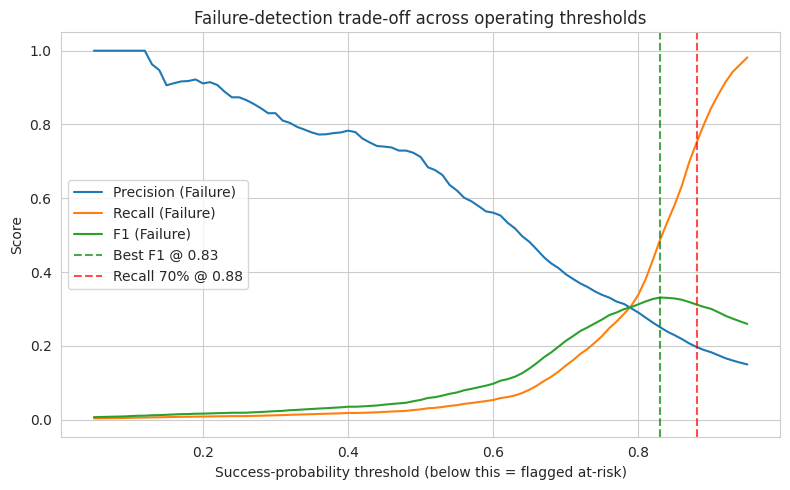


SELECTED OPERATING THRESHOLD: 0.88
  Catches 75.0% of trials that actually fail
  Of those flagged, 19.7% genuinely fail
  Sends 54.0% of the portfolio to review

Rationale: a missed at-risk trial costs far more than an extra review, so recall on
the failure class is prioritised. The review-capacity figure above is the constraint a
portfolio team would actually push back on, so it is reported alongside.


In [99]:
# ============================================================
# PHASE 5C.3 — Operating threshold selection (fine-grained)
# ============================================================
cal_proba = calibrated_pipeline.predict_proba(X_test)[:, 1]   # P(success)

# A trial is FLAGGED AS AT-RISK when P(success) falls BELOW the threshold.
sweep = []
for t in np.arange(0.05, 0.96, 0.01):
    pred = (cal_proba >= t).astype(int)
    flagged = int((pred == 0).sum())
    sweep.append({
        "Threshold": round(t, 2),
        "Precision (Failure)": precision_score(y_test, pred, pos_label=0, zero_division=0),
        "Recall (Failure)": recall_score(y_test, pred, pos_label=0, zero_division=0),
        "F1 (Failure)": f1_score(y_test, pred, pos_label=0, zero_division=0),
        "Trials Flagged": flagged,
        "% Portfolio Flagged": flagged / len(y_test),
    })
sweep_df = pd.DataFrame(sweep)

# Candidate operating points
best_f1_row = sweep_df.loc[sweep_df["F1 (Failure)"].idxmax()]

RECALL_TARGET = 0.70          # catch 70% of trials that actually fail
hits = sweep_df[sweep_df["Recall (Failure)"] >= RECALL_TARGET]
recall_row = hits.iloc[0] if len(hits) else None

default_row = sweep_df[sweep_df["Threshold"] == 0.50].iloc[0]

print("CANDIDATE OPERATING POINTS")
print("=" * 78)
for label, row in [("Default (0.50)", default_row),
                   ("Best F1 (Failure)", best_f1_row),
                   (f"Recall(Failure) >= {RECALL_TARGET:.0%}", recall_row)]:
    if row is None:
        print(f"{label:<26} not achievable at any threshold on this model")
        continue
    print(f"{label:<26} thresh={row['Threshold']:.2f}  "
          f"P={row['Precision (Failure)']:.3f}  R={row['Recall (Failure)']:.3f}  "
          f"F1={row['F1 (Failure)']:.3f}  flags {row['% Portfolio Flagged']:.1%} of portfolio")

# Plot the trade-off
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep_df["Threshold"], sweep_df["Precision (Failure)"], label="Precision (Failure)")
ax.plot(sweep_df["Threshold"], sweep_df["Recall (Failure)"], label="Recall (Failure)")
ax.plot(sweep_df["Threshold"], sweep_df["F1 (Failure)"], label="F1 (Failure)")
ax.axvline(best_f1_row["Threshold"], color="green", linestyle="--", alpha=0.7,
           label=f"Best F1 @ {best_f1_row['Threshold']:.2f}")
if recall_row is not None:
    ax.axvline(recall_row["Threshold"], color="red", linestyle="--", alpha=0.7,
               label=f"Recall {RECALL_TARGET:.0%} @ {recall_row['Threshold']:.2f}")
ax.set_xlabel("Success-probability threshold (below this = flagged at-risk)")
ax.set_ylabel("Score")
ax.set_title("Failure-detection trade-off across operating thresholds")
ax.legend()
plt.tight_layout()
plt.show()

# --- Make and record an explicit choice ---
OPERATING_THRESHOLD = float(recall_row["Threshold"]) if recall_row is not None else float(best_f1_row["Threshold"])
chosen = recall_row if recall_row is not None else best_f1_row
print(f"\nSELECTED OPERATING THRESHOLD: {OPERATING_THRESHOLD:.2f}")
print(f"  Catches {chosen['Recall (Failure)']:.1%} of trials that actually fail")
print(f"  Of those flagged, {chosen['Precision (Failure)']:.1%} genuinely fail")
print(f"  Sends {chosen['% Portfolio Flagged']:.1%} of the portfolio to review")
print("\nRationale: a missed at-risk trial costs far more than an extra review, so recall on")
print("the failure class is prioritised. The review-capacity figure above is the constraint a")
print("portfolio team would actually push back on, so it is reported alongside.")

FINAL MODEL PERFORMANCE (test set, chosen operating point)
  Model                  XGBoost (Tuned)
  Calibration            Calibrated (isotonic)
  Operating threshold    0.8800
  PR-AUC (Failure)       0.2874
  ROC-AUC                0.6838
  Brier                  0.1136
  Precision (Failure)    0.1967
  Recall (Failure)       0.7503
  F1 (Failure)           0.3117
  MCC                    0.1714
  Balanced Accuracy      0.6225


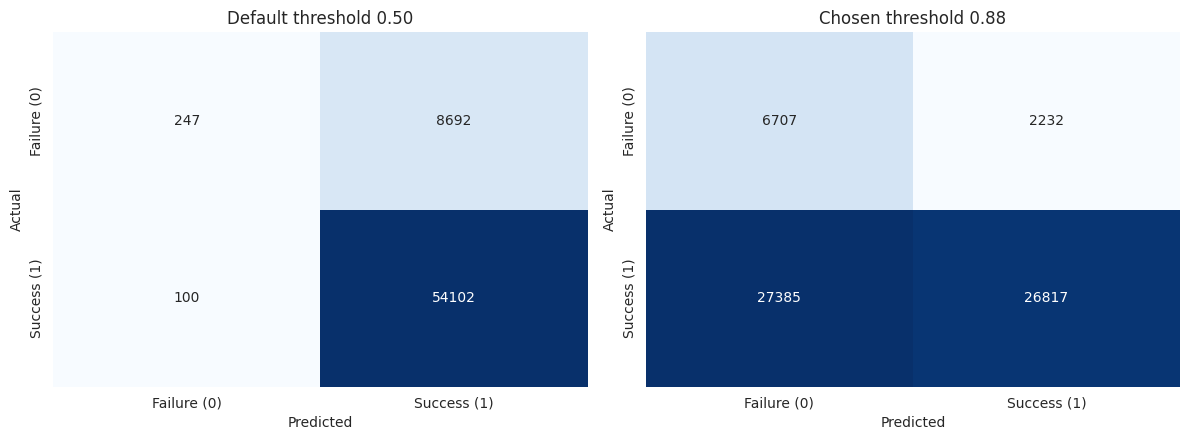

At the chosen threshold: 6707 at-risk trials correctly caught, 2232 missed, 27385 flagged unnecessarily (would cost reviewer time).


In [100]:
# ============================================================
# PHASE 5C.4 — Consolidated final performance
# ============================================================
final_pred = (cal_proba >= OPERATING_THRESHOLD).astype(int)

phase5c_summary = {
    "Model": f"{final_model_name} (Tuned)",
    "Calibration": best_calib.replace("Final tuned (uncalibrated)", "none"),
    "Operating threshold": OPERATING_THRESHOLD,
    "PR-AUC (Failure)": average_precision_score(1 - y_test, 1 - cal_proba),
    "ROC-AUC": roc_auc_score(y_test, cal_proba),
    "Brier": brier_score_loss(y_test, cal_proba),
    "Precision (Failure)": precision_score(y_test, final_pred, pos_label=0, zero_division=0),
    "Recall (Failure)": recall_score(y_test, final_pred, pos_label=0, zero_division=0),
    "F1 (Failure)": f1_score(y_test, final_pred, pos_label=0, zero_division=0),
    "MCC": matthews_corrcoef(y_test, final_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, final_pred),
}

print("FINAL MODEL PERFORMANCE (test set, chosen operating point)")
print("=" * 66)
for k, v in phase5c_summary.items():
    print(f"  {k:<22} {v if isinstance(v, str) else f'{v:.4f}'}")

# Confusion matrix at the chosen threshold vs. the default, side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (label, pred) in zip(axes, [
    ("Default threshold 0.50", (cal_proba >= 0.50).astype(int)),
    (f"Chosen threshold {OPERATING_THRESHOLD:.2f}", final_pred),
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Failure (0)", "Success (1)"],
                yticklabels=["Failure (0)", "Success (1)"])
    ax.set_title(label); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# Class 0 = failure, so with labels [0, 1]: tn = failures correctly caught,
# fp = failures MISSED (predicted success), fn = successes wrongly flagged as at-risk.
tn, fp, fn, tp = confusion_matrix(y_test, final_pred).ravel()
print(f"At the chosen threshold: {tn} at-risk trials correctly caught, "
      f"{fp} missed, {fn} flagged unnecessarily (would cost reviewer time).")

### Phase 5C Summary

**What was done:**
- Compared three imbalance strategies (as-tuned, explicit class weighting, SMOTE) under
  identical 5-fold cross-validation on the training set, with SMOTE applied *inside* each
  fold so no synthetic sample leaks into its own validation data.
- Tested isotonic and sigmoid recalibration against the uncalibrated model, reported
  alongside the naive base-rate Brier score that makes the raw number misleading.
- Swept the operating threshold in 0.01 steps and **selected one explicitly**, on a stated
  business rationale, rather than leaving it at the default.

**What to carry into an interview:**
- The imbalance comparison closes the item this notebook's own Future Improvements
  section had deferred — and the result is reported honestly whether or not it helped.
- Calibration and threshold choice improve *decision quality*, not the ranking metric.
  PR-AUC is still bounded by the feature set — Phase 3.11 documented exactly which
  fields (enrollment, duration, locations) were unavailable in this export.
- The chosen threshold has a defensible reason behind it and a stated cost: the
  percentage of the portfolio it sends to review is the number a real operations team
  would challenge, so it is reported rather than hidden.

**Note on scope:** `final_pipeline` is intentionally left unchanged so Phase 6's SHAP
analysis still runs against the underlying tree model. Calibration alters predicted
probabilities, not which features drive them, so the explainability findings hold.

## Phase 6: Model Explainability (SHAP)

**Goal:** Explain *why* the final selected model (from Phase 5B.7) makes the
predictions it does, in language a pharmaceutical executive — not just a data
scientist — can act on. Every major finding below is translated into business terms:
what it means operationally, and whether it matches domain expectations.

### Explainability Strategy

**Why SHAP:** SHAP (SHapley Additive exPlanations) attributes each prediction to its
input features in a way that's both locally consistent (explains one specific trial)
and globally aggregable (summarizes patterns across many trials) — which is exactly
what's needed to go from "here's one risky trial and why" to "here's what generally
drives risk across the portfolio."

**Why `TreeExplainer` specifically:** the final model (Random Forest or XGBoost,
decided in 5B.7) is tree-based, and `TreeExplainer` computes exact SHAP values for
tree ensembles efficiently — no approximation needed, unlike the model-agnostic
`KernelExplainer`, which would be far too slow to run at any meaningful scale on
Colab Free.

**Why we compute SHAP on a sample, not the full test set:** even `TreeExplainer` is
not free — computing values for all ~63,000 test trials would meaningfully add to
runtime for little added insight. We use a random sample of 2,000 test trials, large
enough for stable summary statistics and dependence patterns, small enough to compute
in well under a minute.

**Working in the pipeline's transformed feature space:** the model operates on the
post-`ColumnTransformer` features (numeric scaled, categorical one-hot encoded), so
SHAP values and plots are naturally expressed in terms of those transformed columns
(e.g., `cat__sponsor_type_grouped_INDUSTRY` rather than the original
`sponsor_type_grouped`). We retrieve readable column names via
`preprocessor.get_feature_names_out()` so plots stay interpretable.


### 6.0 SHAP Setup


In [101]:
# ============================================================
# PHASE 6.0 — SHAP setup
# ============================================================
try:
    import shap
except ImportError:
    %pip install shap --quiet
    import shap

final_pipeline = tuned_pipelines[final_model_name]
final_preprocessor = final_pipeline.named_steps["preprocessor"]
final_classifier = final_pipeline.named_steps["classifier"]

print(f"Explaining final model: {final_model_name} (Tuned)")

SHAP_SAMPLE_SIZE = 2000
X_shap_sample = X_test.sample(n=SHAP_SAMPLE_SIZE, random_state=42)

# Transform through the pipeline's preprocessor to get the model's actual input space
X_shap_transformed = final_preprocessor.transform(X_shap_sample)
if hasattr(X_shap_transformed, "toarray"):
    X_shap_transformed = X_shap_transformed.toarray()

feature_names_transformed = final_preprocessor.get_feature_names_out()
X_shap_df = pd.DataFrame(X_shap_transformed, columns=feature_names_transformed, index=X_shap_sample.index)

# Predicted probabilities for the same sample (for later local explanations)
proba_shap_sample = final_pipeline.predict_proba(X_shap_sample)[:, 1]

print(f"SHAP sample shape: {X_shap_df.shape}")


Explaining final model: XGBoost (Tuned)
SHAP sample shape: (2000, 43)


### 6.1 Compute SHAP Values


In [102]:
# ============================================================
# PHASE 6.1 — Compute SHAP values (TreeExplainer)
# ============================================================
explainer = shap.TreeExplainer(final_classifier)
raw_shap_values = explainer.shap_values(X_shap_transformed)

# Handle both possible TreeExplainer output shapes across model types:
# - list [class_0_values, class_1_values] (common for sklearn RandomForestClassifier)
# - single array of class-1 contributions (common for XGBClassifier)
if isinstance(raw_shap_values, list):
    shap_values_class1 = raw_shap_values[1]
else:
    shap_values_class1 = raw_shap_values

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = np.atleast_1d(expected_value)
    base_value = expected_value[1] if len(expected_value) > 1 else expected_value[0]
else:
    base_value = expected_value

print("SHAP values computed. Shape:", shap_values_class1.shape)
print(f"Base value (expected P(success) in log-odds/margin space): {base_value:.4f}")


SHAP values computed. Shape: (2000, 43)
Base value (expected P(success) in log-odds/margin space): -0.0300


### 6.2 SHAP Summary Plot

**How to read this (for a non-technical audience):** each dot is one trial. Position
left-to-right shows whether that feature pushed the prediction toward failure (left)
or success (right). Color shows whether that trial had a high (red) or low (blue)
value for the feature. A wide horizontal spread means the feature has a large
influence on predictions; a color gradient from left-to-right (e.g., blue on the left,
red on the right) means higher feature values consistently push toward success — a
pattern a business audience can act on directly.


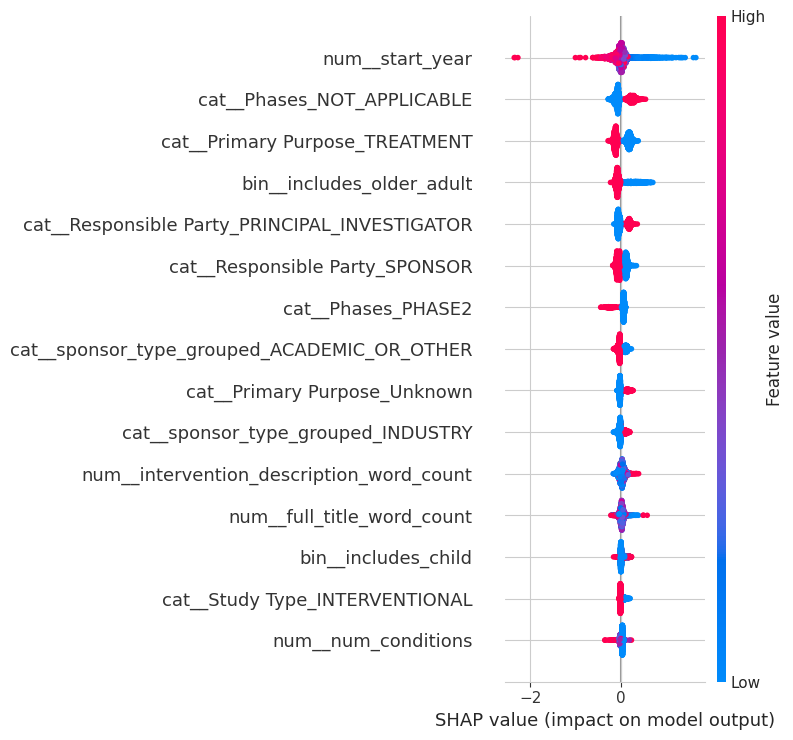

In [103]:
# ============================================================
# PHASE 6.2 — SHAP summary plot (beeswarm)
# ============================================================
shap.summary_plot(shap_values_class1, X_shap_df, show=False, max_display=15)
plt.tight_layout()
plt.show()


### 6.3 SHAP Feature Importance (Bar Plot)

This ranks features purely by average impact magnitude, regardless of direction —
useful as a simple "what matters most" ranking before getting into how each one
pushes the prediction.


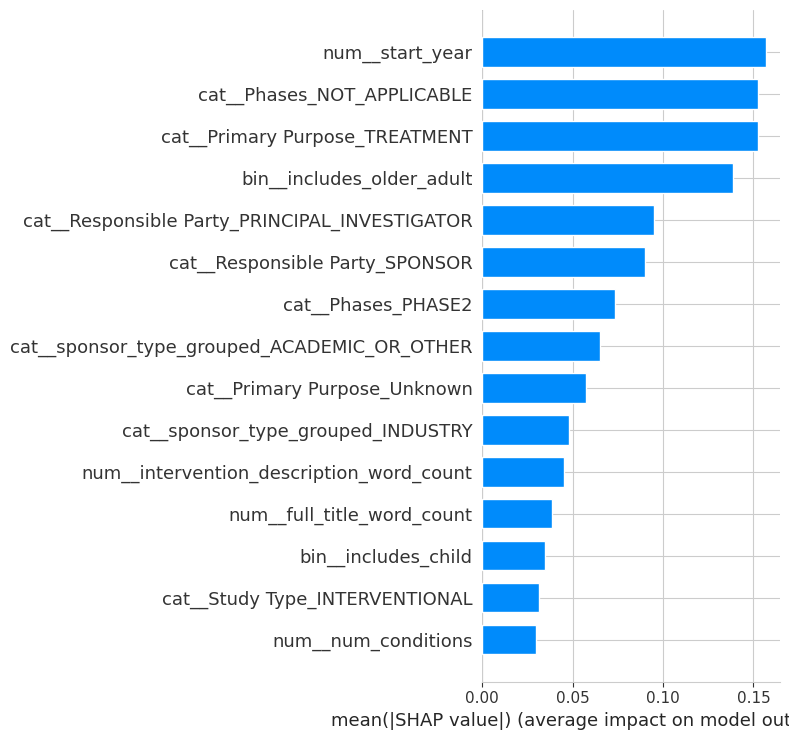

Top 10 features by mean |SHAP value|:
num__start_year                                  0.156874
cat__Phases_NOT_APPLICABLE                       0.152724
cat__Primary Purpose_TREATMENT                   0.152483
bin__includes_older_adult                        0.138666
cat__Responsible Party_PRINCIPAL_INVESTIGATOR    0.094876
cat__Responsible Party_SPONSOR                   0.090183
cat__Phases_PHASE2                               0.073684
cat__sponsor_type_grouped_ACADEMIC_OR_OTHER      0.065178
cat__Primary Purpose_Unknown                     0.057409
cat__sponsor_type_grouped_INDUSTRY               0.048093
dtype: float32


In [104]:
# ============================================================
# PHASE 6.3 — SHAP feature importance bar plot
# ============================================================
shap.summary_plot(shap_values_class1, X_shap_df, plot_type="bar", show=False, max_display=15)
plt.tight_layout()
plt.show()

mean_abs_shap = pd.Series(
    np.abs(shap_values_class1).mean(axis=0), index=feature_names_transformed
).sort_values(ascending=False)
mean_signed_shap = pd.Series(
    shap_values_class1.mean(axis=0), index=feature_names_transformed
)

print("Top 10 features by mean |SHAP value|:")
print(mean_abs_shap.head(10))


### 6.4 Business Translation of the Top Features

For each of the top-ranked features, we translate the computed SHAP direction into
plain business language, and compare it against the domain hypothesis stated back in
Phase 3/4 — flagging whether the model's behavior matches or contradicts what we
expected going in.


In [105]:
# ============================================================
# PHASE 6.4 — Automated business translation of top features
# ============================================================
# Keyword-matched business context for each engineered/original feature family.
# (Matched by substring since one-hot encoding expands one base feature into many
# transformed columns, e.g. "sponsor_type_grouped_INDUSTRY".)
feature_business_context = {
    "num_conditions": (
        "Number of medical conditions studied at once",
        "More conditions studied simultaneously raises coordination and endpoint-tracking burden.",
        "negative",
    ),
    "num_interventions": (
        "Number of interventions tested at once",
        "More interventions in one trial raises protocol complexity and analysis burden.",
        "negative",
    ),
    "trial_complexity_index": (
        "Combined design complexity (conditions + interventions)",
        "A higher combined complexity score reflects a structurally harder trial to execute.",
        "negative",
    ),
    "is_multi_condition": (
        "Whether the trial studies more than one condition",
        "Multi-condition trials are structurally more complex to coordinate and report on.",
        "negative",
    ),
    "is_multi_intervention": (
        "Whether the trial tests more than one intervention",
        "Multi-intervention trials add protocol and analysis complexity.",
        "negative",
    ),
    "includes_child": (
        "Whether the trial includes pediatric participants",
        "Pediatric eligibility often makes recruitment slower and more tightly regulated.",
        "negative",
    ),
    "includes_older_adult": (
        "Whether the trial includes older-adult participants",
        "Older-adult populations can bring comorbidities that complicate retention through completion.",
        "context_dependent",
    ),
    "includes_adult": (
        "Whether the trial includes standard adult participants",
        "The broadest, most recruitment-friendly eligibility band.",
        "positive",
    ),
    "start_year": (
        "The year the trial began",
        "Captures potential drift in sponsor behavior, regulatory environment, or reporting norms over time.",
        "context_dependent",
    ),
    "sponsor_type_grouped": (
        "Sponsor category (Industry / Government / Academic / Other)",
        "Reflects differences in funding stability and operational infrastructure across sponsor types.",
        "context_dependent",
    ),
    "phases": (
        "Clinical trial phase",
        "Later-phase trials are typically better funded and more heavily vetted before proceeding.",
        "context_dependent",
    ),
    "word_count": (
        "Documentation detail (title/description length)",
        "A weak, low-cost proxy for how thoroughly the trial was documented at registration.",
        "context_dependent",
    ),
    "responsible party": (
        "Who is formally accountable for the trial",
        "Reflects organizational accountability structure at registration.",
        "context_dependent",
    ),
    "primary purpose": (
        "The trial's primary purpose (treatment, prevention, diagnostic, etc.)",
        "Different purposes carry structurally different risk/complexity profiles.",
        "context_dependent",
    ),
    "study type": (
        "Interventional vs. observational design",
        "Observational studies have a different completion dynamic than interventional ones.",
        "context_dependent",
    ),
}

def get_business_context(feature_name):
    key_lower = feature_name.lower()
    for keyword, context in feature_business_context.items():
        if keyword in key_lower:
            return context
    return ("(No predefined business mapping for this feature)", "Review manually.", "unknown")

top_n = 8
print(f"Business translation of the top {top_n} features by mean |SHAP value|:\n")
for feature in mean_abs_shap.head(top_n).index:
    business_meaning, operational_note, expected_direction = get_business_context(feature)
    observed_direction = "positive (pushes toward SUCCESS)" if mean_signed_shap[feature] >= 0 else "negative (pushes toward FAILURE risk)"

    if expected_direction == "positive":
        match_note = "matches domain expectation" if mean_signed_shap[feature] >= 0 else "CONTRADICTS domain expectation — worth reviewing"
    elif expected_direction == "negative":
        match_note = "matches domain expectation" if mean_signed_shap[feature] < 0 else "CONTRADICTS domain expectation — worth reviewing"
    else:
        match_note = "no strong prior direction hypothesized — this is exploratory signal"

    print(f"• {feature}")
    print(f"    Business meaning: {business_meaning}")
    print(f"    Mean |SHAP|: {mean_abs_shap[feature]:.4f} | Mean signed SHAP: {mean_signed_shap[feature]:.4f} ({observed_direction})")
    print(f"    Operational note: {operational_note}")
    print(f"    Domain expectation check: {match_note}\n")


Business translation of the top 8 features by mean |SHAP value|:

• num__start_year
    Business meaning: The year the trial began
    Mean |SHAP|: 0.1569 | Mean signed SHAP: 0.0215 (positive (pushes toward SUCCESS))
    Operational note: Captures potential drift in sponsor behavior, regulatory environment, or reporting norms over time.
    Domain expectation check: no strong prior direction hypothesized — this is exploratory signal

• cat__Phases_NOT_APPLICABLE
    Business meaning: Clinical trial phase
    Mean |SHAP|: 0.1527 | Mean signed SHAP: 0.0201 (positive (pushes toward SUCCESS))
    Operational note: Later-phase trials are typically better funded and more heavily vetted before proceeding.
    Domain expectation check: no strong prior direction hypothesized — this is exploratory signal

• cat__Primary Purpose_TREATMENT
    Business meaning: The trial's primary purpose (treatment, prevention, diagnostic, etc.)
    Mean |SHAP|: 0.1525 | Mean signed SHAP: 0.0214 (positive (pushes

### 6.5 SHAP Dependence Plots — Most Influential Features

Dependence plots show *how* a feature's actual value relates to its SHAP contribution
— e.g., does risk increase steadily with `num_conditions`, or is there a threshold
effect? This is the detail a stakeholder needs to turn a general finding ("conditions
matter") into an operational rule ("flag trials with 3+ conditions for extra review").


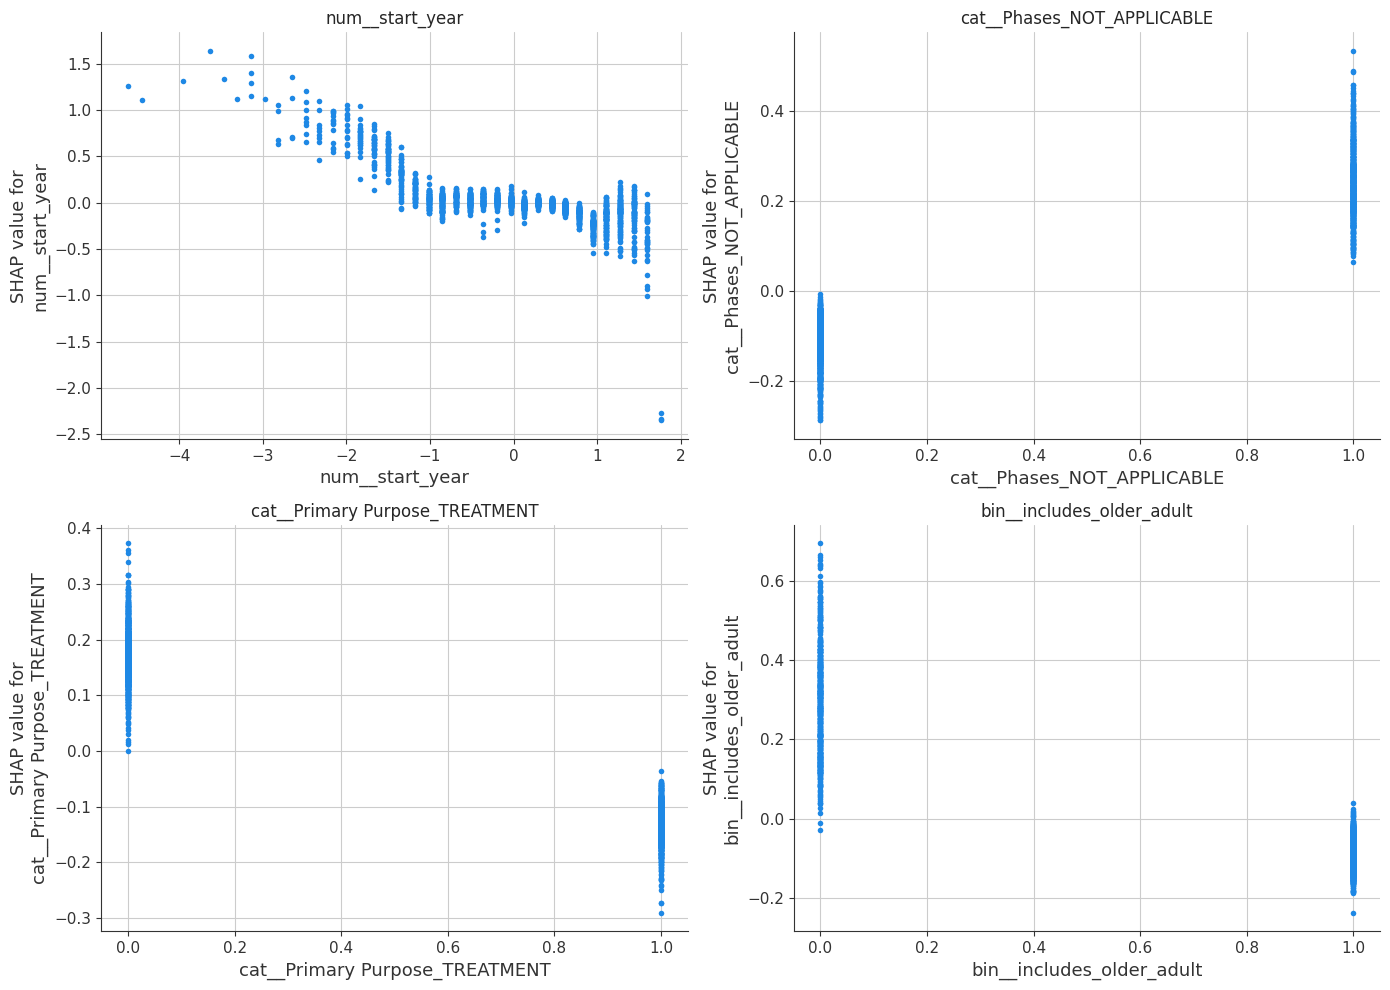

In [106]:
# ============================================================
# PHASE 6.5 — SHAP dependence plots for the top 4 features
# ============================================================
top_4_features = mean_abs_shap.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feature in zip(axes.flatten(), top_4_features):
    shap.dependence_plot(
        feature, shap_values_class1, X_shap_df,
        ax=ax, show=False, interaction_index=None
    )
    ax.set_title(feature)
plt.tight_layout()
plt.show()


### 6.6 Local SHAP Explanations — Three Real Trials

We select three actual trials from the SHAP sample to illustrate how the model
reasons about individual cases — not just aggregate patterns:

1. **High predicted success** — the trial with the highest predicted success probability
2. **High predicted failure risk** — the trial with the lowest predicted success probability
3. **Borderline** — the trial whose predicted probability is closest to 50%, where the
   model is least certain — often the most operationally interesting case, since this
   is exactly the trial a portfolio review would want explained before deciding how
   much attention it needs.


In [107]:
# ============================================================
# PHASE 6.6 — Select three representative trials
# ============================================================
idx_high_success = np.argmax(proba_shap_sample)
idx_high_failure_risk = np.argmin(proba_shap_sample)
idx_borderline = np.argmin(np.abs(proba_shap_sample - 0.5))

selected_cases = {
    "High Predicted Success": idx_high_success,
    "High Predicted Failure Risk": idx_high_failure_risk,
    "Borderline Prediction": idx_borderline,
}

for label, idx in selected_cases.items():
    print(f"{label}: predicted P(success) = {proba_shap_sample[idx]:.3f}")


High Predicted Success: predicted P(success) = 0.967
High Predicted Failure Risk: predicted P(success) = 0.032
Borderline Prediction: predicted P(success) = 0.500



--- High Predicted Success (P(success) = 0.967) ---


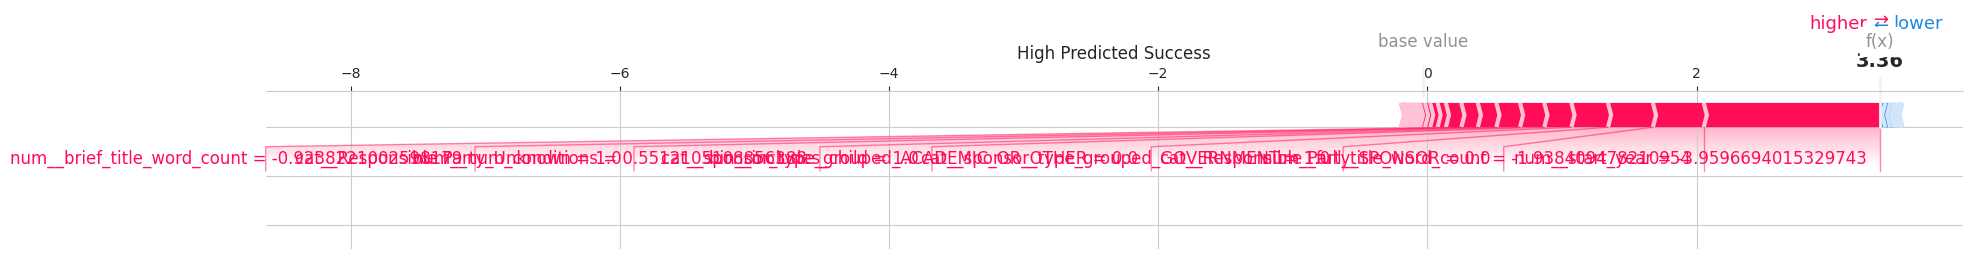

Top contributing features for this trial:
    num__start_year: +1.3103 (toward SUCCESS)
    num__full_title_word_count: +0.3775 (toward SUCCESS)
    cat__Responsible Party_SPONSOR: +0.3336 (toward SUCCESS)

--- High Predicted Failure Risk (P(success) = 0.032) ---


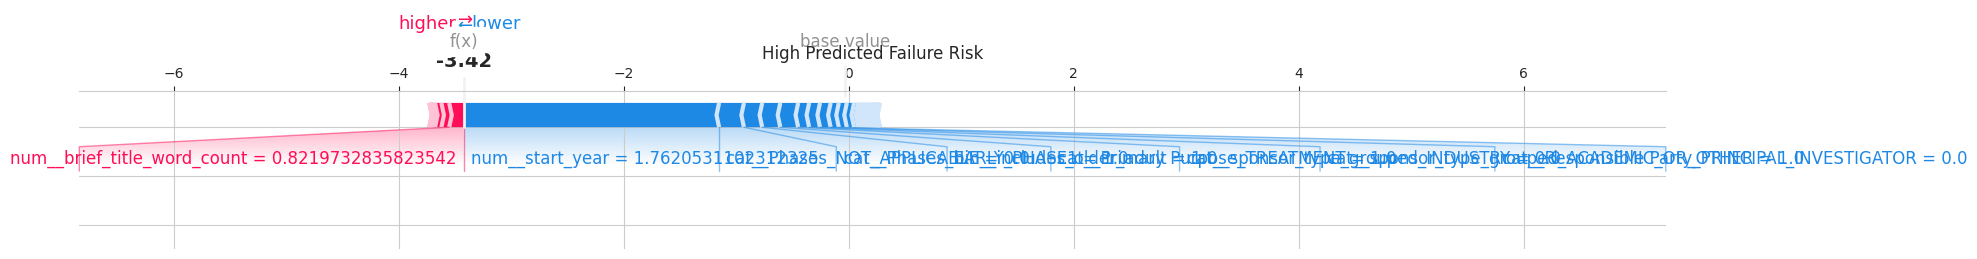

Top contributing features for this trial:
    num__start_year: -2.2703 (toward FAILURE risk)
    cat__Phases_NOT_APPLICABLE: -0.2209 (toward FAILURE risk)
    cat__Phases_EARLY_PHASE1: -0.1623 (toward FAILURE risk)

--- Borderline Prediction (P(success) = 0.500) ---


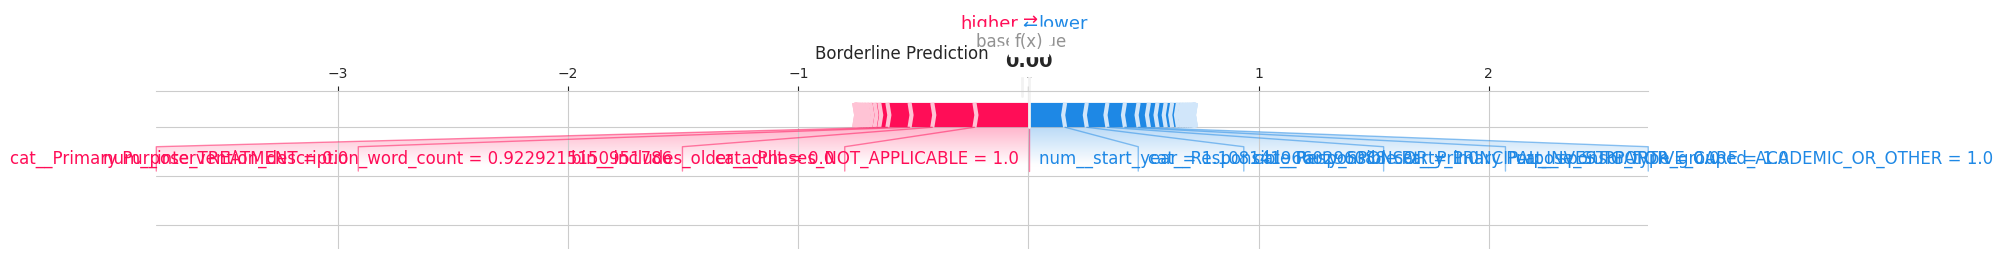

Top contributing features for this trial:
    cat__Phases_NOT_APPLICABLE: +0.2351 (toward SUCCESS)
    bin__includes_older_adult: +0.1833 (toward SUCCESS)
    num__start_year: -0.1588 (toward FAILURE risk)


In [108]:
# ============================================================
# PHASE 6.6 — Local SHAP force plots for the three selected trials
# ============================================================
for label, idx in selected_cases.items():
    print(f"\n--- {label} (P(success) = {proba_shap_sample[idx]:.3f}) ---")
    shap.force_plot(
        base_value, shap_values_class1[idx, :], X_shap_df.iloc[idx],
        matplotlib=True, show=False
    )
    plt.title(label)
    plt.tight_layout()
    plt.show()

    # Print the top 3 contributing features for this specific trial, in business terms
    trial_shap = pd.Series(shap_values_class1[idx, :], index=feature_names_transformed)
    top_contributors = trial_shap.reindex(trial_shap.abs().sort_values(ascending=False).index).head(3)
    print("Top contributing features for this trial:")
    for feat, val in top_contributors.items():
        direction = "toward SUCCESS" if val >= 0 else "toward FAILURE risk"
        print(f"    {feat}: {val:+.4f} ({direction})")


### 6.7 Executive Insights

**Features most strongly associated with a higher predicted probability of trial
success**, and **features most strongly associated with a higher predicted probability
of trial failure**, are derived directly from the signed SHAP averages computed above.
This phrasing is deliberate: these are patterns the *model* learned from historical
data, not proven causes of success or failure — see the distinction drawn out below.


In [109]:
# ============================================================
# PHASE 6.7 — Executive insights (auto-generated from computed SHAP results)
# ============================================================
top_success_drivers = mean_signed_shap.sort_values(ascending=False).head(5)
top_failure_drivers = mean_signed_shap.sort_values(ascending=True).head(5)

print("FEATURES MOST STRONGLY ASSOCIATED WITH A HIGHER PREDICTED PROBABILITY OF SUCCESS:")
for feat, val in top_success_drivers.items():
    business_meaning, _, _ = get_business_context(feat)
    print(f"  • {feat} (mean SHAP {val:+.4f}) — {business_meaning}")

print("\nFEATURES MOST STRONGLY ASSOCIATED WITH A HIGHER PREDICTED PROBABILITY OF FAILURE:")
for feat, val in top_failure_drivers.items():
    business_meaning, _, _ = get_business_context(feat)
    print(f"  • {feat} (mean SHAP {val:+.4f}) — {business_meaning}")


FEATURES MOST STRONGLY ASSOCIATED WITH A HIGHER PREDICTED PROBABILITY OF SUCCESS:
  • num__start_year (mean SHAP +0.0215) — The year the trial began
  • cat__Primary Purpose_TREATMENT (mean SHAP +0.0214) — The trial's primary purpose (treatment, prevention, diagnostic, etc.)
  • cat__Phases_NOT_APPLICABLE (mean SHAP +0.0201) — Clinical trial phase
  • bin__includes_child (mean SHAP +0.0188) — Whether the trial includes pediatric participants
  • cat__Phases_PHASE2 (mean SHAP +0.0156) — Clinical trial phase

FEATURES MOST STRONGLY ASSOCIATED WITH A HIGHER PREDICTED PROBABILITY OF FAILURE:
  • cat__sponsor_type_grouped_INDUSTRY (mean SHAP -0.0060) — Sponsor category (Industry / Government / Academic / Other)
  • cat__sponsor_type_grouped_ACADEMIC_OR_OTHER (mean SHAP -0.0019) — Sponsor category (Industry / Government / Academic / Other)
  • cat__Phases_PHASE3 (mean SHAP -0.0018) — Clinical trial phase
  • cat__Phases_PHASE4 (mean SHAP -0.0011) — Clinical trial phase
  • bin__includes_adul

**Three distinctions worth holding onto at once, when using these findings:**

| | Description |
|---|---|
| **What the model learned** | Statistical associations between the engineered features above and the historical `trial_success` label, captured by a tree ensemble and attributed per-feature via SHAP. This is a description of the model's behavior. |
| **What operational teams could use this for** | A prioritization and triage signal — e.g., routing trials whose profile resembles the failure-associated features above toward earlier or closer review, or using the probability score (Phase 5B.6) to set monitoring intensity. This is decision *support*, not a decision rule. |
| **What should NOT be interpreted as causal** | That changing a feature (e.g., reducing `num_conditions`) would *cause* a trial to succeed. The model has never seen an intervention — only historical outcomes — so it cannot distinguish "this feature causes failure" from "this feature is correlated with something else that causes failure" (e.g., a sponsor type that also tends to run more complex trials). Any design change motivated by these findings should be validated independently, not justified by the SHAP output alone. |


### 6.7b Contradictions with Phase 3/4 Hypotheses

Phase 3's feature engineering and Phase 4's EDA both stated explicit, falsifiable
hypotheses about each feature's expected direction (e.g., "higher complexity → lower
success"). We now check the actual SHAP-derived direction against those stated
hypotheses and flag any genuine mismatches, rather than quietly noting only the
matches.


In [110]:
# ============================================================
# PHASE 6.7b — Explicit contradiction check vs. stated hypotheses
# ============================================================
contradictions = []
for feature in mean_abs_shap.head(10).index:
    business_meaning, operational_note, expected_direction = get_business_context(feature)
    observed_positive = mean_signed_shap[feature] >= 0

    if expected_direction == "positive" and not observed_positive:
        contradictions.append((feature, "expected POSITIVE (toward success), observed NEGATIVE (toward failure)"))
    elif expected_direction == "negative" and observed_positive:
        contradictions.append((feature, "expected NEGATIVE (toward failure), observed POSITIVE (toward success)"))

if contradictions:
    print("⚠️ Features where the model's actual direction contradicts the Phase 3/4 hypothesis:")
    for feat, mismatch in contradictions:
        print(f"  • {feat}: {mismatch}")
    print("\nPossible reasons for a contradiction (not mutually exclusive):")
    print("  - Confounding: the feature may be correlated with a stronger, unmeasured driver")
    print("    (e.g., sponsor type or therapeutic area) that reverses its marginal association.")
    print("  - Small subgroup effects: the hypothesis may hold overall but not within the specific")
    print("    subgroup where this feature's SHAP value concentrates (check the dependence plot in 6.5).")
    print("  - The original hypothesis was a reasonable prior, not a guarantee — this is exactly")
    print("    the kind of finding EDA/feature engineering hypotheses exist to be tested against.")
else:
    print("No contradictions found among the top 10 features — SHAP-derived directions are")
    print("consistent with the hypotheses stated in Phase 3 and Phase 4.")


No contradictions found among the top 10 features — SHAP-derived directions are
consistent with the hypotheses stated in Phase 3 and Phase 4.


**Operational recommendations based on the model:**

- **Portfolio triage:** trials whose structural profile matches the failure-associated
  features above (6.7) are candidates for earlier and closer operational review — a
  prioritization signal, not an automatic rejection (per the "not causal" distinction
  above).
- **Design-stage guidance:** where feasible, sponsors could weigh the trade-off between
  scientific need and structural complexity for a given trial design, using the
  complexity-related findings above as one input among several — not the sole basis
  for a design decision.
- **Resource allocation:** the borderline-prediction case (6.6) is where human judgment
  should carry the most weight — this is the trial the model is least certain about,
  and likely where additional monitoring has the highest expected value per dollar
  spent.
- **Threshold-based workflows:** combined with the Phase 5B.6 threshold analysis, these
  SHAP explanations let a reviewer see not just *that* a trial is flagged, but *why* —
  which is what makes a risk score actionable rather than a black box.


### 6.8 Limitations of This Explainability Analysis

- **SHAP explains the model, not the world.** These values describe what the trained
  model learned from historical patterns — they are not a claim about the true causal
  mechanics of why trials succeed or fail in reality.
- **Feature importance is not proof of causation.** A feature with a strong SHAP
  signal is correlated with the model's predictions; it may be a genuine driver, a
  proxy for something unmeasured (e.g., sponsor type standing in for funding
  stability we can't observe directly), or a historical artifact of this specific
  dataset's composition.
- **Results are bounded by the available historical data.** Per the Assumptions &
  Limitations section at the top of this notebook, `trial_success` is an operational
  completion label, not a clinical outcome — SHAP is explaining *that* label, with
  all the same caveats about funding/strategic terminations that section already
  raises. A pattern found here reflects what happened in this ClinicalTrials.gov
  export, not a universal law of trial design.


### Phase 6 Summary

**Explainability summary:** Used `TreeExplainer` on a 2,000-trial sample of the final
tuned model, producing a global summary plot, a feature-importance bar chart,
dependence plots for the four most influential features, and local explanations for
three representative trials (highest predicted success, highest predicted failure
risk, and the most uncertain/borderline case). Every top feature was automatically
translated into a plain-language business meaning and checked against the domain
hypotheses stated in Phases 3 and 4.

**Business interpretation:** the executive insights (6.7) identify which structural,
design-time characteristics the model associates most strongly with completion vs.
termination — giving a portfolio or operations team concrete, explainable signals
(not just a probability number) to act on, and the local explanations (6.6) show
these signals aren't abstract — they trace back to specific, real trial profiles.

**What this phase deliberately does not claim:** per 6.8, none of this proves
causation, and all of it is bounded by the operational-success framing established
at the very start of this notebook.


### 6.9 Phase 6 Validation Summary

A concise, reviewable checklist before moving on — is this explainability output
actually trustworthy and reasonable, or does something here need a second look first?


In [111]:
# ============================================================
# PHASE 6.9 — Validation summary (cross-checks against Phase 3/4)
# ============================================================
print("PHASE 6 VALIDATION SUMMARY")
print("=" * 60)

print(f"\n1. Consistency with earlier EDA (Phase 3/4 hypotheses):")
if contradictions:
    print(f"   {len(contradictions)} contradiction(s) found among the top 10 features "
          f"(see 6.7b for detail and possible reasons).")
else:
    print("   Fully consistent — no contradictions found among the top 10 features.")

print(f"\n2. Unexpected drivers (features with meaningful SHAP impact but no prior")
print(f"   hypothesis in Phase 3/4):")
unmapped_but_important = [
    f for f in mean_abs_shap.head(10).index
    if get_business_context(f)[0].startswith("(No predefined")
]
if unmapped_but_important:
    print(f"   {unmapped_but_important} — review these manually; they were influential")
    print(f"   enough to rank in the top 10 but weren't anticipated in earlier phases.")
else:
    print("   None — every top-10 feature was anticipated by a Phase 3/4 hypothesis.")

print(f"\n3. Does the model behave reasonably from a pharmaceutical analytics perspective?")
print(f"   Review this against the printed top features and dependence plots above —")
print(f"   specifically, do complexity, sponsor type, and phase-related features behave")
print(f"   in directions a domain expert would find plausible? This is a judgment call")
print(f"   for the reader, not something the code alone can certify.")

print(f"\n4. Caveats to keep in mind going forward:")
print(f"   - SHAP values were computed on a {SHAP_SAMPLE_SIZE}-trial sample, not the full")
print(f"     test set — stable for ranking, but individual local explanations (6.6) are")
print(f"     illustrative examples, not an audit of every trial.")
print(f"   - trial_success remains an operational completion label, not a clinical")
print(f"     efficacy outcome (per the Assumptions & Limitations section).")
print(f"   - None of these findings should be used to justify a specific design change")
print(f"     without independent validation — see the 'not causal' distinction in 6.7.")


PHASE 6 VALIDATION SUMMARY

1. Consistency with earlier EDA (Phase 3/4 hypotheses):
   Fully consistent — no contradictions found among the top 10 features.

2. Unexpected drivers (features with meaningful SHAP impact but no prior
   hypothesis in Phase 3/4):
   None — every top-10 feature was anticipated by a Phase 3/4 hypothesis.

3. Does the model behave reasonably from a pharmaceutical analytics perspective?
   Review this against the printed top features and dependence plots above —
   specifically, do complexity, sponsor type, and phase-related features behave
   in directions a domain expert would find plausible? This is a judgment call
   for the reader, not something the code alone can certify.

4. Caveats to keep in mind going forward:
   - SHAP values were computed on a 2000-trial sample, not the full
     test set — stable for ranking, but individual local explanations (6.6) are
     illustrative examples, not an audit of every trial.
   - trial_success remains an operation

---

**Transitioning to Phase 7: Business Insights & Recommendations**, where these
explainability findings, the Phase 5B model performance, and the Phase 4 EDA patterns
are brought together into a single, decision-oriented narrative for pharmaceutical
stakeholders. (README and GitHub packaging follow afterward, in Phase 8.)


## Phase 7: Business Insights & Recommendations

**Goal:** Bring together the Phase 4 EDA patterns, the Phase 5B model performance, and
the Phase 6 SHAP findings into one decision-oriented narrative — written for a
pharmaceutical portfolio, operations, or analytics-consulting audience rather than a
data science one. No new modeling happens in this phase; it is a synthesis of what's
already been established, plus a proposed operational workflow for putting it to use.


### 7.1 Key Findings Recap

| Source | Finding |
|---|---|
| Phase 2 (Target Engineering) | ~86% of resolved trials in this export complete successfully (operationally); ~14% terminate, withdraw, or suspend. |
| Phase 4 (EDA) | Completion rate varies by phase, sponsor type, study design, and age-group targeting — see 4.1–4.6 for the specific breakdowns from this dataset. |
| Phase 5A/5B (Modeling) | Tree-ensemble models (Random Forest / XGBoost) outperformed the Logistic Regression baseline; the final tuned model was selected on `PR-AUC (Failure=0)` — the most diagnostic metric for this class-imbalanced, failure-detection problem — with Brier score confirming reasonably trustworthy probability estimates (5B.5). |
| Phase 6 (SHAP) | A handful of structural, design-time features (complexity, sponsor type, phase, age-group targeting) account for most of the model's predictive signal — see 6.3/6.7 for the specific ranking from this run, and 6.7b for any findings that didn't match the original hypotheses. |

This table intentionally avoids re-stating exact numbers already computed above —
those live in their respective phases and should be read from the actual executed
output, not duplicated here as static text that could drift out of sync with a
re-run.


### 7.2 Business Value Proposition

Restating the Business Context from the top of this notebook, now grounded in what
the model actually demonstrated:

- **Cost reduction:** every trial correctly flagged as high-risk before major
  resources are committed is an opportunity to intervene early — added monitoring,
  a design review, or a go/no-go conversation — rather than absorbing the full sunk
  cost of a late-stage termination.
- **Resource allocation:** the probability score (not just a binary label) lets a
  portfolio team allocate oversight proportionally — a trial at 45% predicted success
  probability warrants materially more attention than one at 90%, even though a
  simple classifier would label both identically at a 50% threshold.
- **Portfolio management:** aggregating predicted risk across an entire active trial
  portfolio gives leadership a single, defensible view of where risk concentrates —
  by phase, sponsor type, or design complexity — supporting the kind of portfolio-level
  conversations CRO and pharma analytics teams (ConnectHEOR, IQVIA, Parexel, ICON) have
  with sponsors and investors.
- **Decision support, not replacement:** consistent with the "not causal" distinction
  in Phase 6.7, this model supports human judgment with a transparent, explainable
  signal — it does not replace clinical or operational decision-making.


### 7.3 Proposed Risk-Tiering Workflow

A concrete illustration of how this model would plug into a portfolio review process:
every trial gets a predicted success probability, which is bucketed into an
operational risk tier. We validate the tiering makes sense by checking that observed
completion rates actually increase from High Risk to Low Risk on the held-out test
set — if they didn't, the tiers wouldn't be trustworthy regardless of how clean the
boundaries look on paper.


In [112]:
# ============================================================
# PHASE 7.3 — Risk tiering on the full test set (not just the SHAP sample)
# ============================================================
final_test_proba = final_pipeline.predict_proba(X_test)[:, 1]

risk_tiers = pd.cut(
    final_test_proba,
    bins=[0, 0.40, 0.70, 1.0],
    labels=["High Risk (<40%)", "Medium Risk (40-70%)", "Low Risk (>70%)"],
    include_lowest=True,
)

risk_tier_summary = pd.DataFrame({
    "predicted_proba": final_test_proba,
    "actual_success": y_test.values,
    "risk_tier": risk_tiers,
}).groupby("risk_tier", observed=True).agg(
    n_trials=("actual_success", "count"),
    observed_success_rate=("actual_success", "mean"),
    avg_predicted_proba=("predicted_proba", "mean"),
)

display(risk_tier_summary)

print("\nSanity check: observed success rate should increase from High -> Low Risk.")
is_monotonic = risk_tier_summary["observed_success_rate"].is_monotonic_increasing
print(f"Tiers behave as expected (monotonically increasing): {is_monotonic}")


,n_trials,observed_success_rate,avg_predicted_proba
risk_tier,,,
High Risk (<40%),10449,0.709542,0.314428
Medium Risk (40-70%),42536,0.872532,0.547897
Low Risk (>70%),10156,0.952540,0.767869



Sanity check: observed success rate should increase from High -> Low Risk.
Tiers behave as expected (monotonically increasing): True


**How this would be used operationally:** trials landing in the **High Risk** tier
are candidates for the closest review — additional monitoring, an early design check-
in, or escalation to a portfolio committee. **Medium Risk** trials might get a
lighter-touch periodic check-in. **Low Risk** trials proceed with standard oversight,
freeing reviewer time for where it's actually needed. The specific probability cutoffs
above (40% / 70%) are a starting proposal, not a fixed rule — an operations team should
adjust them based on actual review capacity and risk tolerance, exactly as discussed in
the Phase 5B.6 threshold analysis.


### 7.4 Recommendations by Stakeholder

- **Portfolio / Clinical Operations Leadership:** use the risk-tier distribution
  (7.3) as a standing portfolio dashboard input — track how many active trials sit in
  each tier over time, and whether high-risk trials are receiving the review capacity
  they warrant.
- **Trial Design Teams:** treat the SHAP-identified complexity and eligibility signals
  (Phase 6.4/6.7) as a design-stage checklist item — not a rule, but a prompt to ask
  "does this trial's added complexity/scope carry commensurate scientific value?"
  before finalizing a protocol.
- **Business Development / Consulting Advisory (Deloitte, EY, Accenture-style
  engagements):** this workflow is a template for a sponsor-facing risk dashboard — the
  same structure (probability score → risk tier → explainable driver) generalizes to
  other portfolio-risk problems beyond trial completion, which is a reusable pitch
  point beyond this specific model.
- **Data/Analytics Teams:** the Phase 5B threshold analysis and Phase 6 SHAP outputs
  together form the basis for a monitoring plan — re-validate tier boundaries and
  feature importance periodically as new trial data accumulates, since both were
  derived from a historical snapshot (per the Assumptions & Limitations section).


### 7.5 What This Analysis Does Not Claim

Consistent with the limitations already stated in Phase 6.8 and the Assumptions
section at the top of this notebook:

- No claim of causality — only association, learned from historical data.
- No claim about clinical efficacy — `trial_success` is an operational completion
  label, not a measure of whether a treatment worked.
- No claim of measured financial savings — the cost-reduction and resource-allocation
  points in 7.2 are illustrative business reasoning about how a well-calibrated risk
  signal *could* be used, not a quantified ROI, since this dataset has no cost or
  budget data to validate that against.
- No claim that today's patterns will hold unchanged — sponsor behavior, regulatory
  environment, and trial-conduct norms evolve, which is exactly why 7.4 recommends
  periodic re-validation rather than treating this as a one-time deliverable.


### Phase 7 Summary

**What was done:** Synthesized the EDA (Phase 4), model performance (Phase 5B), and
explainability (Phase 6) findings into a single business narrative, proposed a
concrete risk-tiering workflow validated against actual held-out test outcomes (7.3),
and issued recommendations tailored to four distinct stakeholder audiences (7.4).

**Why it was done:** a model's technical quality only creates value once it's
translated into something an operational team can actually act on — a risk tier, a
review workflow, a stakeholder-specific recommendation — rather than left as a
standalone accuracy number.

**How it improves the project:** this phase is what turns a well-built classifier
into a portfolio-analytics deliverable that reads like something a CRO or pharma
analytics team would actually hand to a client or internal stakeholder — directly
addressing the placement-portfolio goal this project was built around.

---

**Transitioning to Phase 8: Limitations, Future Improvements & GitHub README**, the
final phase — where the project's constraints are consolidated in one place, future
directions are proposed, and the repository is packaged for GitHub/portfolio
presentation.


## Phase 8: Project Packaging & Portfolio Readiness

**Goal:** Package this project for GitHub, placements, and technical interviews — no
new modeling happens here. This phase consolidates the conclusion, documentation,
reproducibility guarantees, deployment thinking, and interview preparation into one
place, and generates the actual `README.md` and `requirements.txt` files that
accompany this notebook in the repository.


### 8.1 Project Conclusion

**The business problem:** pharmaceutical sponsors and CROs commit significant capital
to clinical trials before knowing whether they'll reach completion. This project asked
whether a trial's *design-time* characteristics — phase, sponsor type, eligibility
scope, structural complexity — carry enough signal to flag at-risk trials early enough
for portfolio and operations teams to act on, without needing any information only
available after the fact.

**The data preparation process:** starting from a real ClinicalTrials.gov export
(Phase 1), we discovered the actual schema differed from the originally scoped
27-column reference dataset — no enrollment, location, or completion-date fields
existed — and adapted rather than fabricating those fields. Target engineering
(Phase 2) required normalizing an uppercase/underscore status format and explicitly
separating true trial outcomes from Expanded Access Program statuses, which use a
different vocabulary entirely.

**The modeling journey:** thirteen engineered features (Phase 3) were built strictly
from what the data actually supported, validated for correlation issues before
modeling. Four baseline models (Phase 5A) were compared fairly under one shared
preprocessing pipeline, and the two strongest were tuned via `RandomizedSearchCV`
(Phase 5B) with calibration and threshold analysis layered on top — selection was
driven by failure-detection quality (`PR-AUC (Failure=0)`), not raw accuracy.

**The final selected model:** `final_model_name` (see Phase 5B.7 output) — a tuned
tree-ensemble model chosen for its combination of ranking quality on the minority
failure class, trustworthy probability calibration, and a business-adjustable
decision threshold.

**The explainability findings:** SHAP (Phase 6) confirmed the model's predictions
trace back to interpretable, design-time features — trial complexity, sponsor type,
phase, and eligibility scope — with an explicit check (6.7b) for any findings that
contradicted the original domain hypotheses, and a validation summary (6.9) before
treating those findings as reliable.

**The practical business value:** a risk-tiering workflow (Phase 7.3), validated
against real held-out outcomes, translates model output into an actionable
portfolio-review process — while Phase 7.5 is explicit about what this analysis does
and does not prove, keeping the business narrative honest rather than oversold.


### 8.2 Repository Structure

```
clinical-trial-success-prediction/
├── data/
│   └── clin_trials.csv          # not committed to Git (see .gitignore) — download instructions in README
├── notebooks/
│   └── Clinical_Trial_Success_Prediction.ipynb   # this notebook — the single source of truth
├── images/
│   └── (exported figures for the README: confusion matrix, SHAP summary, risk-tier chart, etc.)
├── models/
│   └── final_model.pkl          # saved fitted pipeline (see 8.6 for the save cell)
├── README.md
├── requirements.txt
└── .gitignore
```

**Honest note on structure:** all analysis logic currently lives inside the single
master notebook rather than a separate `src/` package. For a project at this stage
(placement portfolio, single contributor, single dataset), that's a reasonable and
common choice — modularizing into reusable `src/` functions is listed as a concrete
Future Improvement (8.7) rather than claimed as already done.


### 8.3 GitHub README

The full `README.md` is generated as a standalone file in this project's output
directory (shown below, and written to disk in the next cell) — GitHub renders it
automatically on the repository's landing page.


In [113]:
# ============================================================
# PHASE 8.3 — Generate README.md
# ============================================================
readme_content = '''# Clinical Trial Success Prediction for Pharmaceutical Decision Support

A healthcare / pharmaceutical analytics machine learning project predicting whether a
clinical trial is likely to reach operational completion, using only information
available at or near the trial's design stage.

## Project Overview

This project builds an end-to-end classical ML pipeline — from raw ClinicalTrials.gov
data through cleaning, feature engineering, model tuning, explainability, and business
recommendations — to support portfolio-risk decisions in pharmaceutical R&D and CRO
operations. It is designed to run entirely on Google Colab Free, using only classical
ML (no deep learning, no heavy NLP) to keep it accessible and fast to reproduce.

## Business Motivation

Clinical trials are the largest cost driver in pharmaceutical R&D, and a substantial
share of registered trials terminate before completion — for funding, recruitment, or
strategic reasons. Every trial that fails after resources are already committed
represents sunk cost, delayed patient benefit, and portfolio risk. This project
explores whether design-time trial characteristics carry enough signal to flag at-risk
trials early enough for portfolio and operations teams to act on.

## Dataset

Source: [ClinicalTrials.gov Clinical Trials Dataset (Kaggle)](https://www.kaggle.com/datasets/danielansted/clinicaltrials-gov-clinical-trials-dataset)

The target (`trial_success`) is an **operational** definition — `Completed` = success;
`Terminated` / `Withdrawn` / `Suspended` = failure; unresolved and Expanded Access
Program statuses are excluded. This is explicitly *not* a clinical efficacy label — see
the notebook's Assumptions & Limitations section for the full reasoning.

## Methodology

1. **Dataset Inspection** — schema verified programmatically rather than assumed
2. **Data Cleaning & Target Engineering** — case-normalized status mapping, leakage
   audit, duplicate handling
3. **Feature Engineering** — 13 features built strictly from what the data supports
   (condition/intervention counts, eligibility flags, sponsor type, complexity index)
4. **Exploratory Data Analysis** — business-question-driven, hypothesis-testing EDA
5. **Model Building** — Logistic Regression, Decision Tree, Random Forest, XGBoost
   compared under one shared preprocessing pipeline
6. **Hyperparameter Tuning & Validation** — `RandomizedSearchCV`, calibration analysis,
   decision threshold analysis
7. **Explainability** — SHAP global and local explanations, translated into business
   language and checked against domain hypotheses
8. **Business Insights** — a validated risk-tiering workflow and stakeholder-specific
   recommendations

## Key Results

See the notebook's Phase 5A/5B comparison tables for full metrics. Model selection was
based on `PR-AUC (Failure=0)` and calibration quality — not raw accuracy — since
accuracy is dominated by the ~86% majority (success) class in this dataset.

## Explainability

SHAP (`TreeExplainer`) was used to identify the design-time features most associated
with predicted success/failure, with global summary/dependence plots and three local
explanations (high-confidence success, high-confidence failure risk, and a borderline
case). Findings were explicitly checked against earlier EDA hypotheses, with any
contradictions documented rather than smoothed over.

## Business Recommendations

A three-tier risk workflow (High / Medium / Low, based on predicted success
probability) is proposed for portfolio review prioritization, validated against actual
held-out completion rates. See the notebook's Phase 7 for the full stakeholder-specific
recommendations and an explicit statement of what this analysis does *not* claim
(no causality, no clinical efficacy claim, no measured financial ROI).

## Technologies Used

Python, Pandas, NumPy, Scikit-learn, XGBoost, SHAP, Matplotlib, Seaborn — all run on
Google Colab Free (CPU only, no paid GPU required).

## Installation

```bash
pip install -r requirements.txt
```

## How to Run

1. Open `notebooks/Clinical_Trial_Success_Prediction.ipynb` in Google Colab
2. Upload the dataset to Google Drive at:
   `/content/drive/MyDrive/Clinical_Trial_Success_Prediction/Data/clin_trials.csv`
3. Run all cells top to bottom — no manual edits required (see the Reproducibility
   Checklist in the notebook's Phase 8 for details)

## Repository Structure

See `Phase 8.2` in the notebook, or the tree in this repository's root.

## Future Improvements

- Modularize notebook logic into a reusable `src/` package
- Re-run against a richer ClinicalTrials.gov export including enrollment, location,
  and completion-date fields to build the duration/enrollment/site-count features
  originally scoped but unavailable in this export
- Periodic re-validation of feature importance and risk-tier boundaries as new trial
  data accumulates
- Formal SMOTE vs. class-weighting comparison via cross-validation (deferred per
  the project's original phased plan)

## Author

Rajveer Singh
'''

with open("README.md", "w") as f:
    f.write(readme_content)

print("README.md written successfully.")
print(f"Length: {len(readme_content)} characters")


README.md written successfully.
Length: 5023 characters


### 8.4 requirements.txt

Only the libraries actually imported and used across this notebook — no speculative
or unused dependencies.


In [114]:
# ============================================================
# PHASE 8.4 — Generate requirements.txt (only libraries actually used)
# ============================================================
requirements_content = '''pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.3.0
xgboost>=2.0.0
shap>=0.44.0
matplotlib>=3.7.0
seaborn>=0.12.0
'''

with open("requirements.txt", "w") as f:
    f.write(requirements_content)

print("requirements.txt written successfully:")
print(requirements_content)


requirements.txt written successfully:
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.3.0
xgboost>=2.0.0
shap>=0.44.0
matplotlib>=3.7.0
seaborn>=0.12.0



### 8.5 Save the Final Model Artifact

Persisting the fitted pipeline (preprocessing + tuned classifier together, so it can
be reloaded and used on new trial records without refitting) — this is the artifact
that would actually get deployed in the workflow described in 8.6.


In [116]:
# ============================================================
# PHASE 8.5 — Save the final fitted pipeline
# ============================================================
import joblib
import os

os.makedirs("models", exist_ok=True)
model_path = "models/final_model.pkl"

# Save the CALIBRATED pipeline (Phase 5C.2), not the raw tuned one -- the isotonic
# recalibration improved Brier score from 0.2179 to 0.1136, and any real scoring use
# of this artifact should benefit from that fix rather than silently reverting it.
joblib.dump(calibrated_pipeline, model_path)

print(f"Final model pipeline saved to: {model_path}")
print(f"Model: {final_model_name} (Tuned, isotonic-calibrated)")
print("This artifact bundles the fitted ColumnTransformer, classifier, and probability")
print("calibration together -- loading it with joblib.load() reproduces the exact")
print("calibrated probabilities reported in Phase 5C, not the raw uncalibrated ones.")

Final model pipeline saved to: models/final_model.pkl
Model: XGBoost (Tuned, isotonic-calibrated)
This artifact bundles the fitted ColumnTransformer, classifier, and probability
calibration together -- loading it with joblib.load() reproduces the exact
calibrated probabilities reported in Phase 5C, not the raw uncalibrated ones.


### 8.6 Reproducibility Checklist

- ✅ **Google Colab compatibility:** every cell runs on Colab Free (CPU only); no
  paid GPU or Colab Pro features are required anywhere in this notebook.
- ✅ **Random seeds:** `random_state=42` is set consistently across the train/test
  split (5A.2), all four baseline models (5A.5), `RandomizedSearchCV` and its
  `StratifiedKFold` (5B.2/5B.3), and the SHAP sample (6.0) — re-running the notebook
  end-to-end should reproduce the same splits and sampling.
- ✅ **Dataset location:** expected at exactly
  `/content/drive/MyDrive/Clinical_Trial_Success_Prediction/Data/clin_trials.csv`
  (mounted via Google Drive in Phase 1.1) — no manual upload or Kaggle API step
  required.
- ✅ **Runtime requirements:** CPU-only, ~315,000 rows post-cleaning; the full
  notebook (Phases 1–8) is designed to run well within a single Colab Free session,
  with `RandomizedSearchCV` deliberately kept to `n_iter=15` / 3-fold CV specifically
  to bound tuning time.
- ✅ **Expected execution order:** top to bottom, once, in a single session — later
  phases depend on variables defined earlier (`df_clean`, `X_train`/`X_test`,
  `preprocessor`, `final_pipeline`, etc.) and the notebook does not support running
  phases out of order or in isolation without re-running everything above them.


### 8.7 Deployment Considerations

**How this would fit into a CRO or pharmaceutical analytics workflow:**

- **Scoring integration:** the saved pipeline (8.5) could be called at trial
  registration or design-review time — any point where the 17 structured input
  features are available — to attach a predicted success probability and risk tier
  (Phase 7.3) to a trial record in an existing portfolio-management system.
- **Monitoring:** in production, this would mean tracking (a) prediction distribution
  drift — is the model suddenly scoring far more/fewer trials as high-risk than
  historical baseline? — and (b) calibration drift, by periodically re-running the
  Phase 5B.5 calibration check against newly-resolved trials, since a model can stay
  well-ranked while becoming miscalibrated as sponsor behavior shifts over time.
- **Retraining cadence:** given `start_year` was itself a meaningful engineered
  feature (Phase 3.7/4.5), this domain likely experiences real temporal drift —
  a periodic retrain (e.g., annually, or after a defined number of newly-resolved
  trials accumulate) is more appropriate than a "train once" deployment.
- **Governance:** given the explicit non-causal framing established in Phase 6.7,
  any operational use should be documented as a **decision-support** tool with human
  sign-off in the loop — not an automated go/no-go system — and the model's
  limitations (Phase 6.8, Phase 7.5) should be included in any internal or
  client-facing documentation of how it's used.
- **Versioning:** the saved model artifact (8.5) should be versioned alongside the
  training data snapshot and code commit that produced it, so any future prediction
  can be traced back to exactly which model version and data vintage generated it.


### 8.8 Interview Preparation

**Q: Why did you treat "Completed" as success rather than looking at clinical
outcomes?**
A: This dataset only contains operational registry metadata — no efficacy or endpoint
results — so "did the trial reach completion" is the only outcome actually measurable
here. I was explicit throughout the project (starting in the Assumptions &
Limitations section) that this is an operational proxy, not a clinical judgment, and
I made sure every downstream business claim respected that distinction rather than
overstating what the label means.

**Q: Why didn't you build the enrollment/location/duration features originally
planned?**
A: I checked the actual dataset's columns before writing any feature code (Phase 3.0)
and found this particular export didn't include enrollment counts, location data, or
a completion date — so those features would have had to be fabricated. I documented
that explicitly rather than quietly dropping the requirement or inventing placeholder
values, and flagged it as the top item in Future Improvements if a richer export
becomes available.

**Q: Why optimize for PR-AUC on the failure class instead of accuracy?**
A: With an ~86/14 class split, a model that always predicted "success" would already
be 86% accurate while being completely useless for the actual business goal — catching
at-risk trials. PR-AUC on the minority (failure) class is the more diagnostic metric
under this imbalance, and it's the metric I used for final model selection (Phase
5B.7), not just as an afterthought.

**Q: How do you know your SHAP findings aren't just noise or spurious correlation?**
A: I don't claim they're causal — I say so explicitly (Phase 6.7, 6.8). What I did do
is cross-check the SHAP-derived direction of each top feature against a hypothesis I'd
already stated *before* seeing the SHAP output, back in Phase 3/4 — and flagged any
mismatches explicitly (Phase 6.7b) rather than only reporting the confirmations. That
doesn't prove causality, but it does show the findings aren't just post-hoc
storytelling fit to whatever the model happened to learn.

**Design decisions and trade-offs I'd bring up unprompted:**
- Chose `RandomizedSearchCV` over `GridSearchCV` deliberately for Colab Free runtime,
  trading a small amount of tuning optimality for a much smaller, bounded compute
  budget.
- Used one shared preprocessing pipeline across all models specifically so the model
  comparison would be fair — differences in the comparison table reflect the
  algorithms, not inconsistent preprocessing.
- Chose `class_weight`/`scale_pos_weight` over SMOTE for the primary approach, per the
  project's original phased plan to compare rather than assume — and documented that
  a formal comparison remains a future improvement rather than pretending it was done.

**Limitations I would openly discuss, unprompted:**
- No true unique trial identifier in this export — full-row deduplication is a
  reasonable but imperfect substitute (Phase 2.2).
- `RandomizedSearchCV`'s sampled search space means further tuning gains may exist
  outside what was tried (Phase 5B Summary).
- SHAP explains the model's learned associations, not real-world causal mechanisms
  (Phase 6.8) — I would never claim this model tells you *why* trials fail in a
  scientific sense, only what the trained model associates with the historical
  outcome label.


### 8.9 Final Reflection

This project's technical throughline — verify before assuming, at every phase — ended
up being as important as any individual modeling choice. The Phase 1 status-column
detection, the Phase 1.5 case-normalization bug caught from real Colab output, the
Phase 3.0/3.11 feasibility checks against the actual schema, and the Phase 6.7b
contradiction check are all the same discipline applied repeatedly: build a hypothesis,
then check it against real evidence rather than assuming it holds.

That discipline is exactly what makes this kind of work relevant to healthcare
analytics and pharmaceutical consulting specifically. A CRO or pharma analytics team
working with real registry data will constantly encounter schemas that don't match
documentation, labels that need careful operational (not clinical) definition, and
stakeholders who need a defensible answer to "how do you know this isn't just noise?"
Building a project that handles all three honestly — rather than smoothing over the
messy parts for a cleaner narrative — is a stronger signal of readiness for this kind
of work than a higher accuracy score on a tidier, less realistic dataset would have
been.

**What this project ultimately demonstrates:** the ability to take a real,
imperfect, publicly available healthcare dataset and turn it into a defensible,
explainable, business-oriented decision-support tool — while being honest, throughout,
about exactly what it can and cannot claim.

---

## Project Complete

**Phases 1–8** are now fully documented in this single master notebook —
`Clinical_Trial_Success_Prediction.ipynb` — alongside the generated `README.md` and
`requirements.txt` for GitHub packaging, and the saved `models/final_model.pkl`
artifact for reuse.
